In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from scipy import stats
from sklearn.cluster import KMeans

In [2]:
# Helper functions
def stoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', ''))

def montoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', '').str.replace('$', '', regex = False))

def pertoint(col): # converts to float, keeping as int for now because it's similar name structure
    return pd.to_numeric(df_op[col].str.replace('%', '')) / 100

In [3]:
df = pd.read_csv(r"Medicare_Part_D_Prescribers_by_Provider_2023.csv", low_memory = False)

In [4]:
df.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_MI', 'Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_St1',
       'Prscrbr_St2', 'Prscrbr_City', 'Prscrbr_State_Abrvtn',
       'Prscrbr_State_FIPS', 'Prscrbr_zip5', 'Prscrbr_RUCA',
       'Prscrbr_RUCA_Desc', 'Prscrbr_Cntry', 'Prscrbr_Type',
       'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst',
       'Tot_Day_Suply', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms',
       'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply',
       'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'Brnd_Sprsn_Flag',
       'Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Sprsn_Flag',
       'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'Othr_Sprsn_Flag',
       'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'MAPD_Sprsn_Flag',
       'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Sprsn_Flag', 'PDP_Tot_Clms',
       'PDP_Tot_Drug_Cst', 'LIS_Sprsn_Flag', 'LIS_Tot_Clms', 'LIS_Drug_Cst',
       'NonLIS_Sprsn_Flag', 'NonLIS_T

In [5]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

PRSCRBR_NPI                             0
Prscrbr_Last_Org_Name                   0
Prscrbr_First_Name                      2
Prscrbr_MI                         484940
Prscrbr_Crdntls                    134724
Prscrbr_Ent_Cd                          0
Prscrbr_St1                             2
Prscrbr_St2                       1100597
Prscrbr_City                            1
Prscrbr_State_Abrvtn                    0
Prscrbr_State_FIPS                   1534
Prscrbr_zip5                           45
Prscrbr_RUCA                         1534
Prscrbr_RUCA_Desc                    1534
Prscrbr_Cntry                           0
Prscrbr_Type                            3
Prscrbr_Type_src                        0
Tot_Clms                                0
Tot_30day_Fills                         0
Tot_Drug_Cst                            0
Tot_Day_Suply                           0
Tot_Benes                          143405
GE65_Sprsn_Flag                   1052458
GE65_Tot_Clms                     

In [6]:
threshold = 0.5
count = 0
for col in df.columns:
    percnull = df[col].isnull().sum() / len(df)
    if percnull > threshold:
        print(f"{col} Null percentage: {100 * percnull}%")
        count += 1
print(f"\nTotal columns above {100 * threshold}% nan: {count}")

Prscrbr_St2 Null percentage: 79.7149924130763%
GE65_Sprsn_Flag Null percentage: 76.22833924232162%
GE65_Bene_Sprsn_Flag Null percentage: 52.50129466597618%
Brnd_Sprsn_Flag Null percentage: 54.966773257814175%
Gnrc_Sprsn_Flag Null percentage: 97.21829698007845%
Othr_Sprsn_Flag Null percentage: 54.509819543480866%
MAPD_Sprsn_Flag Null percentage: 83.35903350921477%
PDP_Sprsn_Flag Null percentage: 83.35903350921477%
LIS_Sprsn_Flag Null percentage: 79.90113459818275%
NonLIS_Sprsn_Flag Null percentage: 79.90113459818275%
Opioid_LA_Prscrbr_Rate Null percentage: 73.67485957853643%
Antpsyct_GE65_Sprsn_Flag Null percentage: 62.157728341053044%
Antpsyct_GE65_Tot_Benes Null percentage: 64.1141044351816%
Bene_Age_LT_65_Cnt Null percentage: 55.968174756367404%
Bene_Age_65_74_Cnt Null percentage: 50.30677246109665%
Bene_Age_75_84_Cnt Null percentage: 61.400556977978006%
Bene_Age_GT_84_Cnt Null percentage: 68.9262058500795%
Bene_Race_Black_Cnt Null percentage: 57.57609557713131%
Bene_Race_Api_Cnt Nul

In [7]:
df_op = df.copy()

In [8]:
#I kept prescriber city and prescriber type source (ML).

droplist = ['Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_MI', 'Prscrbr_St1', 'Prscrbr_St2',
            'Prscrbr_State_FIPS', 'Prscrbr_RUCA_Desc', 'Othr_Sprsn_Flag',
            'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_Avg_Risk_Scre']
df_op = df_op.drop(columns = droplist)

In [9]:
#note: items() was previously iteritems() in Jacob's data cleaned code.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 134724
Prscrbr_Ent_Cd , 0
Prscrbr_City , 1
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 45
Prscrbr_RUCA , 1534
Prscrbr_Cntry , 0
Prscrbr_Type , 3
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 143405
GE65_Sprsn_Flag , 1052458
GE65_Tot_Clms , 328207
GE65_Tot_30day_Fills , 328207
GE65_Tot_Drug_Cst , 328207
GE65_Tot_Day_Suply , 328207
GE65_Bene_Sprsn_Flag , 724867
GE65_Tot_Benes , 655798
Brnd_Sprsn_Flag , 758907
Brnd_Tot_Clms , 621758
Brnd_Tot_Drug_Cst , 621758
Gnrc_Sprsn_Flag , 1342259
Gnrc_Tot_Clms , 38406
Gnrc_Tot_Drug_Cst , 38406
MAPD_Sprsn_Flag , 1150909
MAPD_Tot_Clms , 229756
MAPD_Tot_Drug_Cst , 229756
PDP_Sprsn_Flag , 1150909
PDP_Tot_Clms , 229756
PDP_Tot_Drug_Cst , 229756
LIS_Sprsn_Flag , 1103167
LIS_Tot_Clms , 277498
LIS_Drug_Cst , 277498
NonLIS_Sprsn_Flag , 1103167
NonLIS_Tot_Clms , 277498
NonLIS_Drug_Cst , 277498
Opioid_Tot_Clms , 347477
Opioid_Tot_Drug_Cst , 347477
Opioid_Tot_Suply , 347477
Opio

In [10]:
#Prscbr
#changed df_op['Prscrbr_Crdntls'].fillna('Organization') to df_op['Prscrbr_Crdntls'].fillna('Unknown').

df_op['Prscrbr_Crdntls'] = df_op['Prscrbr_Crdntls'].fillna('Unknown')

df_op['Prscrbr_City'] = df_op['Prscrbr_City'].fillna('Unknown')

df_op['Prscrbr_zip5'] = df_op['Prscrbr_zip5'].fillna('Unknown')

df_op['Prscrbr_RUCA'] = df_op['Prscrbr_RUCA'].fillna('Unknown')

df_op['Prscrbr_Type'] = df_op['Prscrbr_Type'].fillna('Unknown')

In [11]:
#Totals

df_op['Tot_Clms'] = stoint('Tot_Clms')

df_op['Tot_30day_Fills'] = stoint('Tot_30day_Fills')

df_op['Tot_Drug_Cst'] = montoint('Tot_Drug_Cst')

df_op['Tot_Day_Suply'] = stoint('Tot_Day_Suply')

df_op['Tot_Benes'] = stoint('Tot_Benes').fillna(10)

In [12]:
#GE65
df_op['GE65_Sprsn_Flag'] = df_op['GE65_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Clms'] = stoint('GE65_Tot_Clms').fillna(10)

df_op['GE65_Tot_30day_Fills'] = stoint('GE65_Tot_30day_Fills')
df_op['GE65_Tot_30day_Fills'] = df_op['GE65_Tot_30day_Fills'].fillna(df_op['GE65_Tot_30day_Fills'].min())

df_op['GE65_Tot_Drug_Cst'] = montoint('GE65_Tot_Drug_Cst')
df_op['GE65_Tot_Drug_Cst'] = df_op['GE65_Tot_Drug_Cst'].fillna(df_op['GE65_Tot_Drug_Cst'].min())

df_op['GE65_Tot_Day_Suply'] = stoint('GE65_Tot_Day_Suply')
df_op['GE65_Tot_Day_Suply'] = df_op['GE65_Tot_Day_Suply'].fillna(df_op['GE65_Tot_Day_Suply'].min())

df_op['GE65_Bene_Sprsn_Flag'] = df_op['GE65_Bene_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Benes'] = stoint('GE65_Tot_Benes')
df_op['GE65_Tot_Benes'] = df_op['GE65_Tot_Benes'].fillna(10)


In [13]:
#BRND

df_op['Brnd_Sprsn_Flag'] = df_op['Brnd_Sprsn_Flag'].notna().astype(int)

df_op['Brnd_Tot_Clms'] = stoint('Brnd_Tot_Clms')
df_op['Brnd_Tot_Clms'] = df_op['Brnd_Tot_Clms'].fillna(10)

df_op['Brnd_Tot_Drug_Cst'] = montoint('Brnd_Tot_Drug_Cst')
df_op['Brnd_Tot_Drug_Cst'] = df_op['Brnd_Tot_Drug_Cst'].fillna(df_op['Brnd_Tot_Drug_Cst'].min())

In [14]:
#GNRC

df_op['Gnrc_Sprsn_Flag'] = df_op['Gnrc_Sprsn_Flag'].notna().astype(int)

df_op['Gnrc_Tot_Clms'] = stoint('Gnrc_Tot_Clms')
df_op['Gnrc_Tot_Clms'] = df_op['Gnrc_Tot_Clms'].fillna(10)

df_op['Gnrc_Tot_Drug_Cst'] = montoint('Gnrc_Tot_Drug_Cst')
df_op['Gnrc_Tot_Drug_Cst'] = df_op['Gnrc_Tot_Drug_Cst'].fillna(df_op['Gnrc_Tot_Drug_Cst'].min())

In [15]:
#MAPD

df_op['MAPD_Sprsn_Flag'] = df_op['MAPD_Sprsn_Flag'].notna().astype(int)

df_op['MAPD_Tot_Clms'] = stoint('MAPD_Tot_Clms')
df_op['MAPD_Tot_Clms'] = df_op['MAPD_Tot_Clms'].fillna(10)

df_op['MAPD_Tot_Drug_Cst'] = montoint('MAPD_Tot_Drug_Cst')
df_op['MAPD_Tot_Drug_Cst'] = df_op['MAPD_Tot_Drug_Cst'].fillna(df_op['MAPD_Tot_Drug_Cst'].min())

In [16]:
#PDP

df_op['PDP_Sprsn_Flag'] = df_op['PDP_Sprsn_Flag'].notna().astype(int)

df_op['PDP_Tot_Clms'] = stoint('PDP_Tot_Clms')
df_op['PDP_Tot_Clms'] = df_op['PDP_Tot_Clms'].fillna(10)

df_op['PDP_Tot_Drug_Cst'] = montoint('PDP_Tot_Drug_Cst')
df_op['PDP_Tot_Drug_Cst'] = df_op['PDP_Tot_Drug_Cst'].fillna(df_op['PDP_Tot_Drug_Cst'].min())

In [17]:
#LIS

df_op['LIS_Sprsn_Flag'] = df_op['LIS_Sprsn_Flag'].notna().astype(int)

df_op['LIS_Tot_Clms'] = stoint('LIS_Tot_Clms')
df_op['LIS_Tot_Clms'] = df_op['LIS_Tot_Clms'].fillna(10)

df_op['LIS_Drug_Cst'] = montoint('LIS_Drug_Cst')
df_op['LIS_Drug_Cst'] = df_op['LIS_Drug_Cst'].fillna(df_op['LIS_Drug_Cst'].min())

In [18]:
#NonLIS

df_op['NonLIS_Sprsn_Flag'] = df_op['NonLIS_Sprsn_Flag'].notna().astype(int)

df_op['NonLIS_Tot_Clms'] = stoint('NonLIS_Tot_Clms')
df_op['NonLIS_Tot_Clms'] = df_op['NonLIS_Tot_Clms'].fillna(10)

df_op['NonLIS_Drug_Cst'] = montoint('NonLIS_Drug_Cst')
df_op['NonLIS_Drug_Cst'] = df_op['NonLIS_Drug_Cst'].fillna(df_op['NonLIS_Drug_Cst'].min())

In [19]:
#Opioid

df_op['Opioid_Tot_Clms'] = stoint('Opioid_Tot_Clms')
df_op['Opioid_Tot_Clms'] = df_op['Opioid_Tot_Clms'].fillna(10)

df_op['Opioid_Tot_Drug_Cst'] = montoint('Opioid_Tot_Drug_Cst')
df_op['Opioid_Tot_Drug_Cst'] = df_op['Opioid_Tot_Drug_Cst'].fillna(df_op['Opioid_Tot_Drug_Cst'].min())

df_op['Opioid_Tot_Suply'] = stoint('Opioid_Tot_Suply')
df_op['Opioid_Tot_Suply'] = df_op['Opioid_Tot_Suply'].fillna(df_op['Opioid_Tot_Suply'].min())

df_op['Opioid_Tot_Benes'] = stoint('Opioid_Tot_Benes')
df_op['Opioid_Tot_Benes'] = df_op['Opioid_Tot_Benes'].fillna(10)

df_op['Opioid_Prscrbr_Rate'] = pertoint('Opioid_Prscrbr_Rate')
df_op['Opioid_Prscrbr_Rate'] = df_op['Opioid_Prscrbr_Rate'].fillna(df_op['Opioid_Prscrbr_Rate'].min())

df_op['Opioid_LA_Tot_Clms'] = stoint('Opioid_LA_Tot_Clms')
df_op['Opioid_LA_Tot_Clms'] = df_op['Opioid_LA_Tot_Clms'].fillna(10)

df_op['Opioid_LA_Tot_Drug_Cst'] = montoint('Opioid_LA_Tot_Drug_Cst')
df_op['Opioid_LA_Tot_Drug_Cst'] = df_op['Opioid_LA_Tot_Drug_Cst'].fillna(df_op['Opioid_LA_Tot_Drug_Cst'].min())

df_op['Opioid_LA_Tot_Suply'] = stoint('Opioid_LA_Tot_Suply')
df_op['Opioid_LA_Tot_Suply'] = df_op['Opioid_LA_Tot_Suply'].fillna(df_op['Opioid_LA_Tot_Suply'].min())

df_op['Opioid_LA_Tot_Benes'] = stoint('Opioid_LA_Tot_Benes')
df_op['Opioid_LA_Tot_Benes'] = df_op['Opioid_LA_Tot_Benes'].fillna(10)

df_op['Opioid_LA_Prscrbr_Rate'] = pertoint('Opioid_LA_Prscrbr_Rate')
df_op['Opioid_LA_Prscrbr_Rate'] = df_op['Opioid_LA_Prscrbr_Rate'].fillna(df_op['Opioid_LA_Prscrbr_Rate'].min())


In [20]:
#Antibiotic

df_op['Antbtc_Tot_Clms'] = stoint('Antbtc_Tot_Clms')
df_op['Antbtc_Tot_Clms'] = df_op['Antbtc_Tot_Clms'].fillna(10)

df_op['Antbtc_Tot_Drug_Cst'] = montoint('Antbtc_Tot_Drug_Cst')
df_op['Antbtc_Tot_Drug_Cst'] = df_op['Antbtc_Tot_Drug_Cst'].fillna(df_op['Antbtc_Tot_Drug_Cst'].min())

df_op['Antbtc_Tot_Benes'] = stoint('Antbtc_Tot_Benes')
df_op['Antbtc_Tot_Benes'] = df_op['Antbtc_Tot_Benes'].fillna(10)

In [21]:
#Antipsychotic

df_op['Antpsyct_GE65_Sprsn_Flag'] = df_op['Antpsyct_GE65_Sprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Clms'] = stoint('Antpsyct_GE65_Tot_Clms')
df_op['Antpsyct_GE65_Tot_Clms'] = df_op['Antpsyct_GE65_Tot_Clms'].fillna(10)

df_op['Antpsyct_GE65_Tot_Drug_Cst'] = montoint('Antpsyct_GE65_Tot_Drug_Cst')
df_op['Antpsyct_GE65_Tot_Drug_Cst'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'].fillna(df_op['Antpsyct_GE65_Tot_Drug_Cst'].min())

df_op['Antpsyct_GE65_Bene_Suprsn_Flag'] = df_op['Antpsyct_GE65_Bene_Suprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Benes'] = stoint('Antpsyct_GE65_Tot_Benes')
df_op['Antpsyct_GE65_Tot_Benes'] = df_op['Antpsyct_GE65_Tot_Benes'].fillna(10)


In [22]:
#Bene Age

df_op['Bene_Avg_Age'] = df_op['Bene_Avg_Age'].fillna(df_op['Bene_Avg_Age'].mode()[0])

df_op['Bene_Age_LT_65_Cnt'] = stoint('Bene_Age_LT_65_Cnt').fillna(10)

df_op['Bene_Age_GT_84_Cnt'] = stoint('Bene_Age_GT_84_Cnt').fillna(10)

df_op['Bene_Age_65_74_Cnt'] = stoint('Bene_Age_65_74_Cnt')
df_op['Bene_Age_75_84_Cnt'] = stoint('Bene_Age_75_84_Cnt')
df_op['Bene_Age_65_74_Cnt'] = df_op['Bene_Age_65_74_Cnt'].fillna(0)
df_op['Bene_Age_75_84_Cnt'] = df_op['Bene_Age_75_84_Cnt'].fillna(0)
df_op['Bene_Age_65_84_Cnt'] = df_op['Bene_Age_65_74_Cnt'] + df_op['Bene_Age_75_84_Cnt']
df_op = df_op.drop(columns = ['Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt'])

In [23]:
#Bene Sex

df_op['Bene_Feml_Cnt'] = stoint('Bene_Feml_Cnt')
df_op['Bene_Feml_Cnt'] = df_op['Bene_Feml_Cnt'].fillna(10)

df_op['Bene_Male_Cnt'] = stoint('Bene_Male_Cnt')
df_op['Bene_Male_Cnt'] = df_op['Bene_Male_Cnt'].fillna(10)

In [24]:
#Bene Race

df_op['Bene_Race_Wht_Cnt'] = stoint('Bene_Race_Wht_Cnt')
df_op['Bene_Race_Wht_Cnt'] = df_op['Bene_Race_Wht_Cnt'].fillna(10)

df_op['Bene_Race_Black_Cnt'] = stoint('Bene_Race_Black_Cnt')
df_op['Bene_Race_Black_Cnt'] = df_op['Bene_Race_Black_Cnt'].fillna(10)

df_op['Bene_Race_Api_Cnt'] = stoint('Bene_Race_Api_Cnt')
df_op['Bene_Race_Api_Cnt'] = df_op['Bene_Race_Api_Cnt'].fillna(10)

df_op['Bene_Race_Hspnc_Cnt'] = stoint('Bene_Race_Hspnc_Cnt')
df_op['Bene_Race_Hspnc_Cnt'] = df_op['Bene_Race_Hspnc_Cnt'].fillna(10)

#df_op['Bene_Race_Natind_Cnt'] = stoint('Bene_Race_Natind_Cnt') Already float
df_op['Bene_Race_Natind_Cnt'] = df_op['Bene_Race_Natind_Cnt'].fillna(10)

df_op['Bene_Race_Othr_Cnt'] = stoint('Bene_Race_Othr_Cnt')
df_op['Bene_Race_Othr_Cnt'] = df_op['Bene_Race_Othr_Cnt'].fillna(10)

In [25]:
#note: items() was previously iteritems() in Jacob's cleaned data.
missing = df_op.isnull().sum()
for key,value in missing.items():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 0
Prscrbr_Ent_Cd , 0
Prscrbr_City , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 0
Prscrbr_RUCA , 0
Prscrbr_Cntry , 0
Prscrbr_Type , 0
Prscrbr_Type_src , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 0
GE65_Sprsn_Flag , 0
GE65_Tot_Clms , 0
GE65_Tot_30day_Fills , 0
GE65_Tot_Drug_Cst , 0
GE65_Tot_Day_Suply , 0
GE65_Bene_Sprsn_Flag , 0
GE65_Tot_Benes , 0
Brnd_Sprsn_Flag , 0
Brnd_Tot_Clms , 0
Brnd_Tot_Drug_Cst , 0
Gnrc_Sprsn_Flag , 0
Gnrc_Tot_Clms , 0
Gnrc_Tot_Drug_Cst , 0
MAPD_Sprsn_Flag , 0
MAPD_Tot_Clms , 0
MAPD_Tot_Drug_Cst , 0
PDP_Sprsn_Flag , 0
PDP_Tot_Clms , 0
PDP_Tot_Drug_Cst , 0
LIS_Sprsn_Flag , 0
LIS_Tot_Clms , 0
LIS_Drug_Cst , 0
NonLIS_Sprsn_Flag , 0
NonLIS_Tot_Clms , 0
NonLIS_Drug_Cst , 0
Opioid_Tot_Clms , 0
Opioid_Tot_Drug_Cst , 0
Opioid_Tot_Suply , 0
Opioid_Tot_Benes , 0
Opioid_Prscrbr_Rate , 0
Opioid_LA_Tot_Clms , 0
Opioid_LA_Tot_Drug_Cst , 0
Opioid_LA_Tot_Suply , 0
Opioid_LA_Tot_Benes , 0
Opioid_LA_Prscrbr_R

In [26]:
df_op.isnull().sum().sum()

np.int64(0)

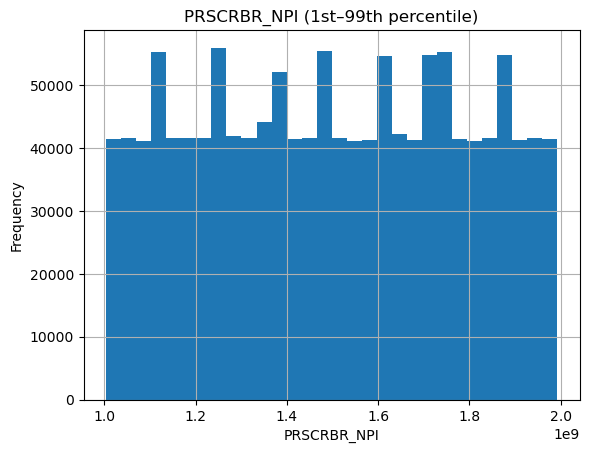

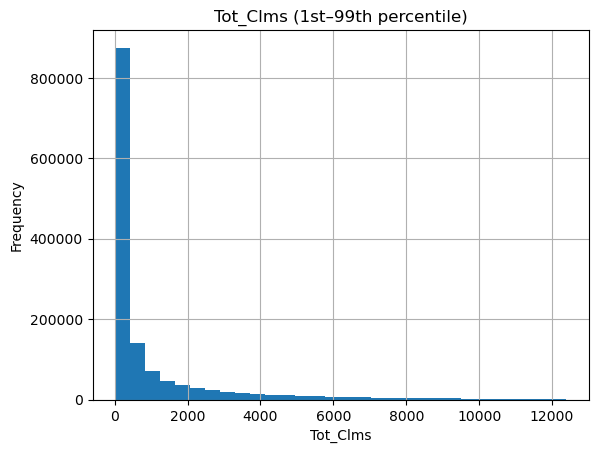

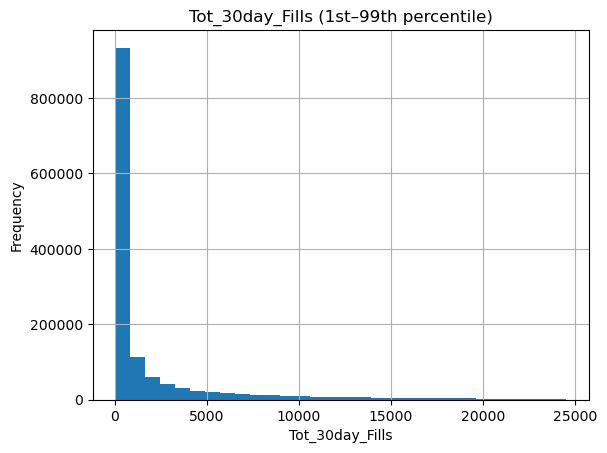

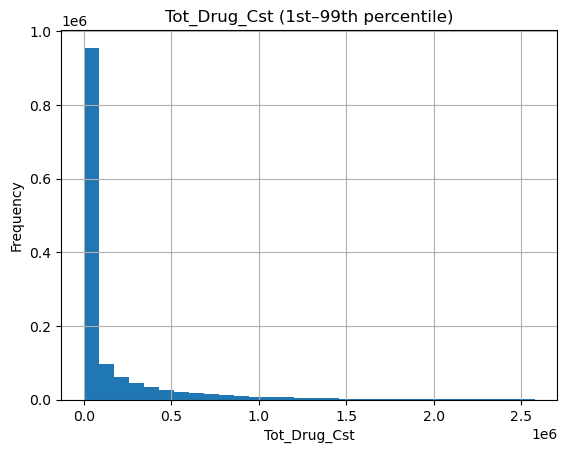

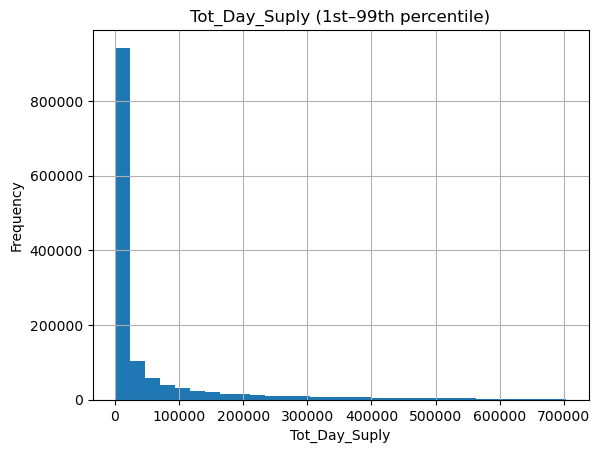

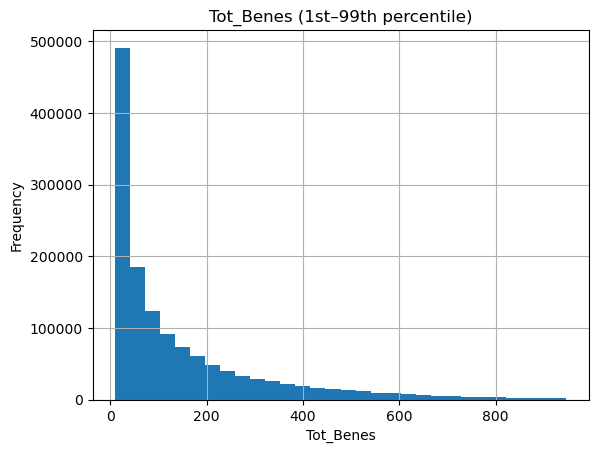

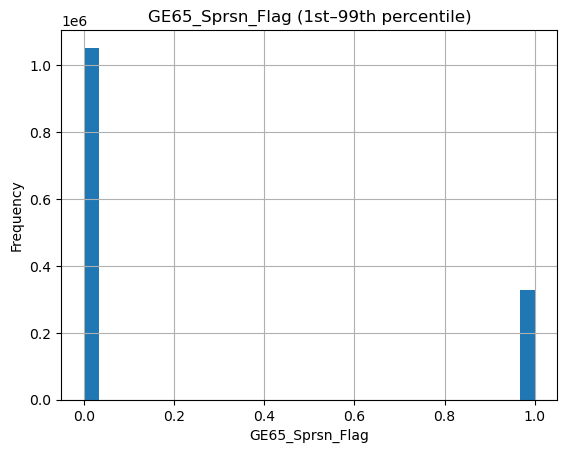

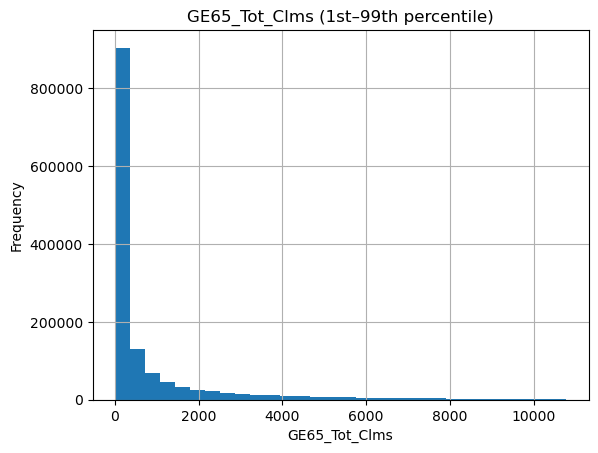

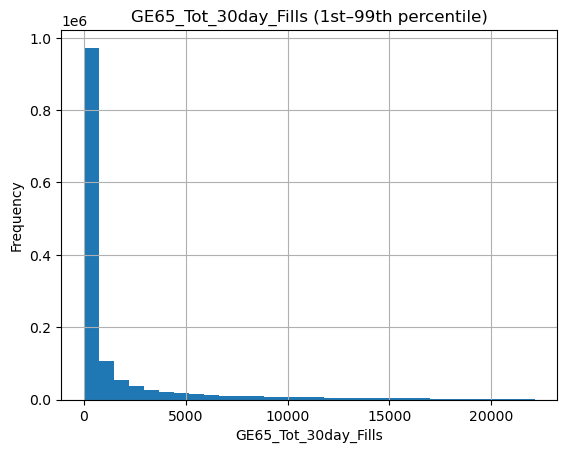

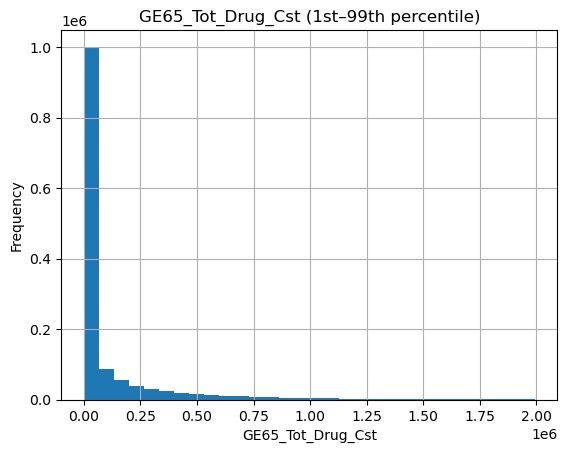

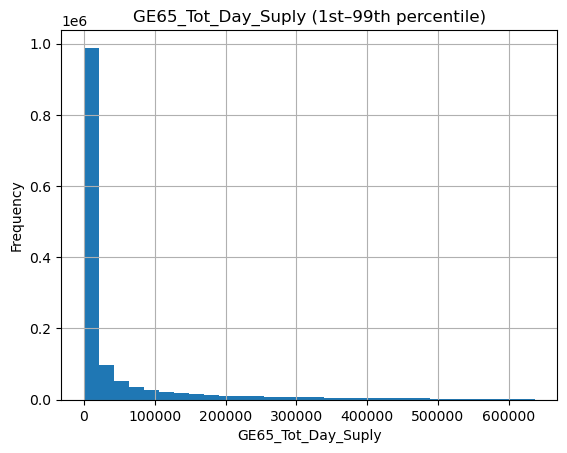

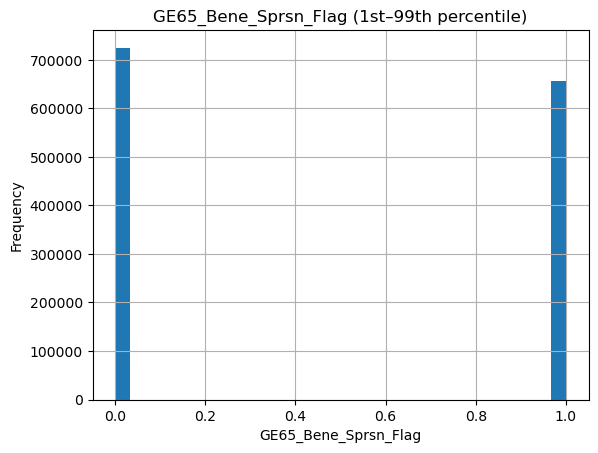

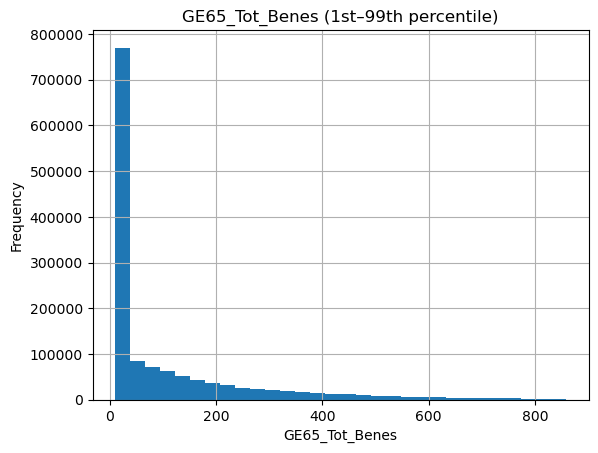

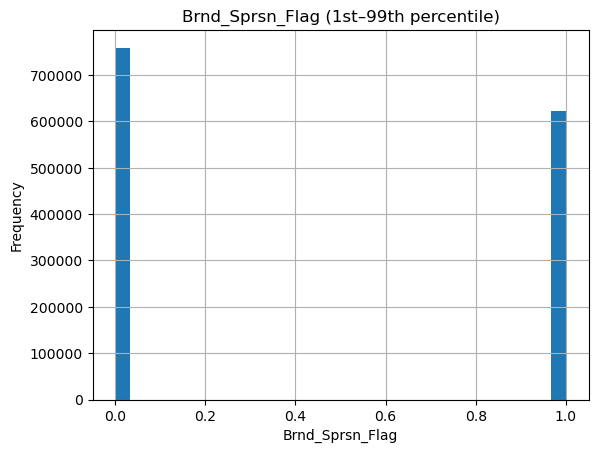

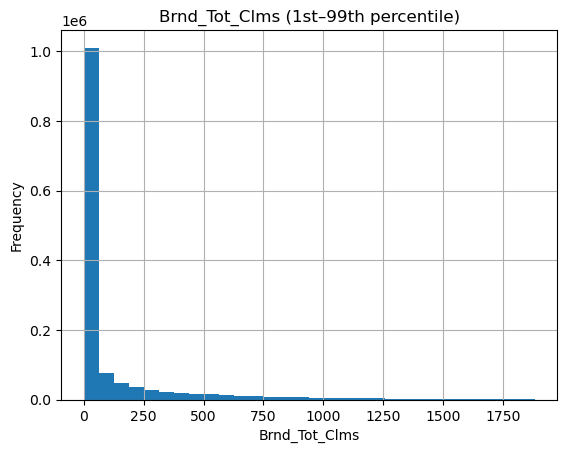

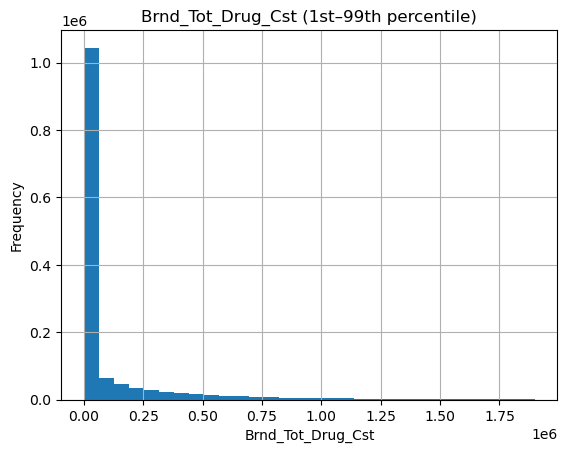

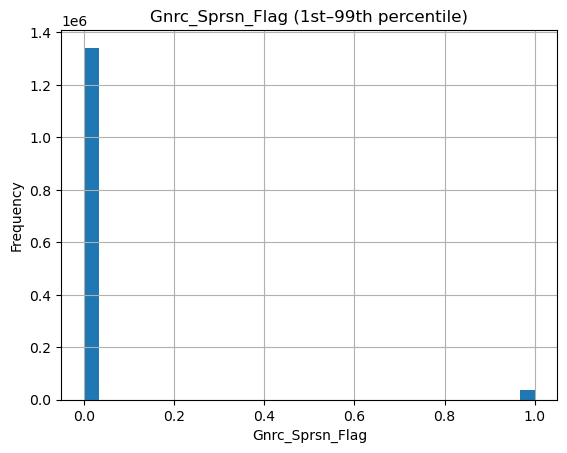

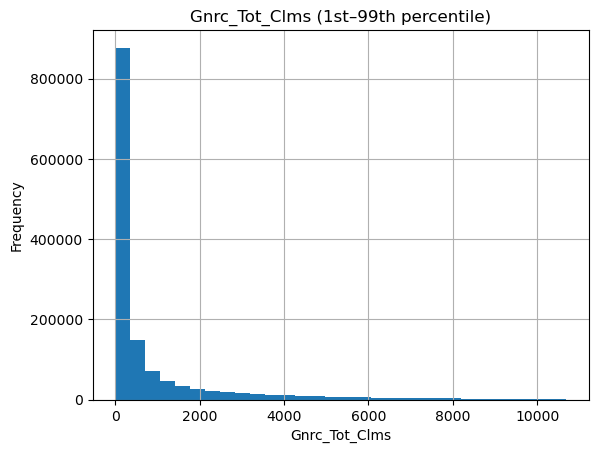

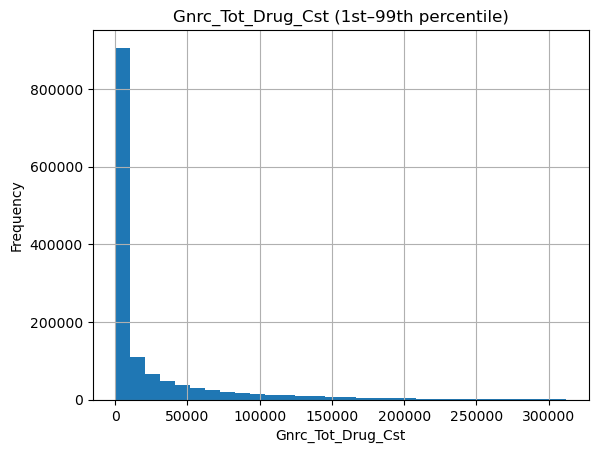

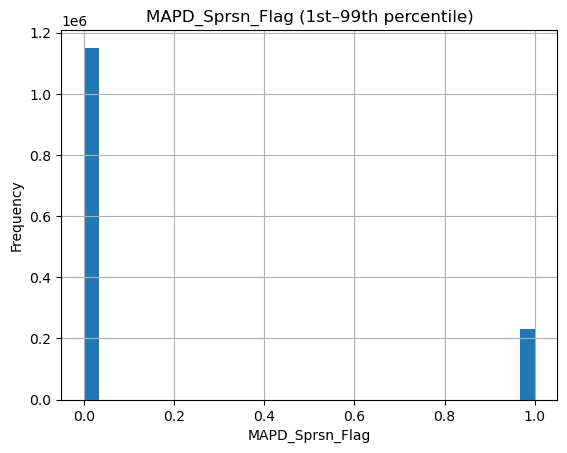

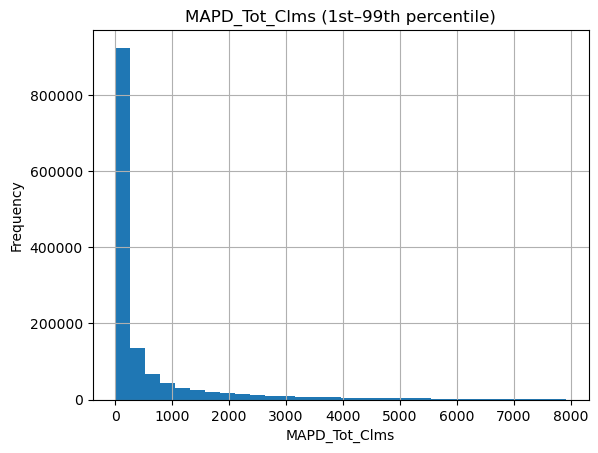

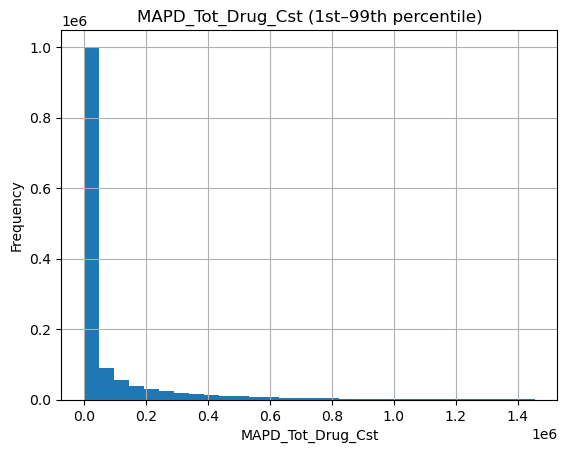

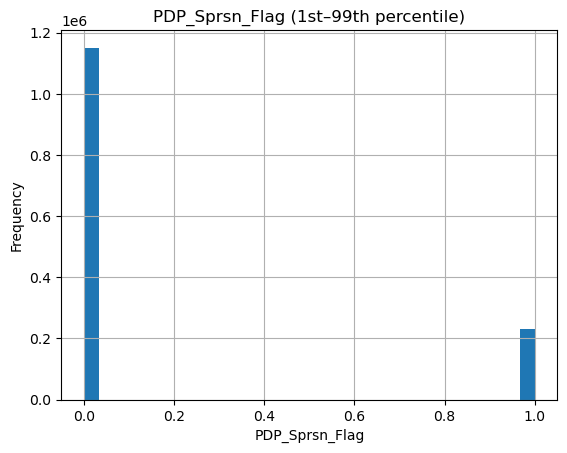

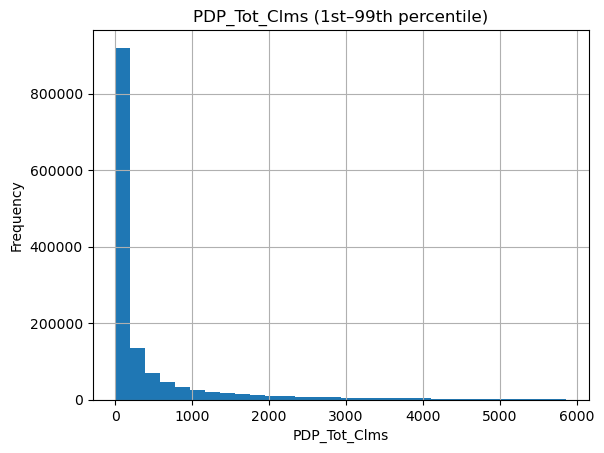

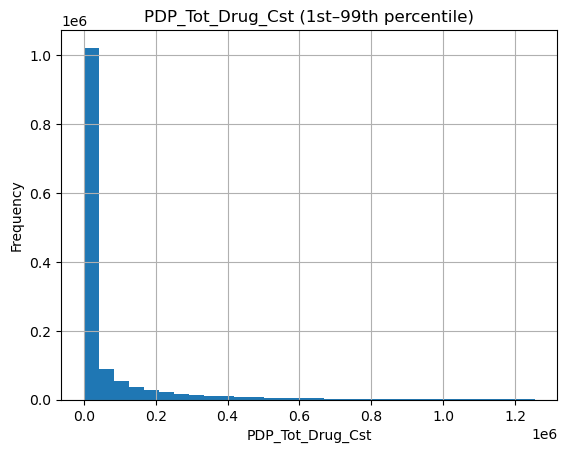

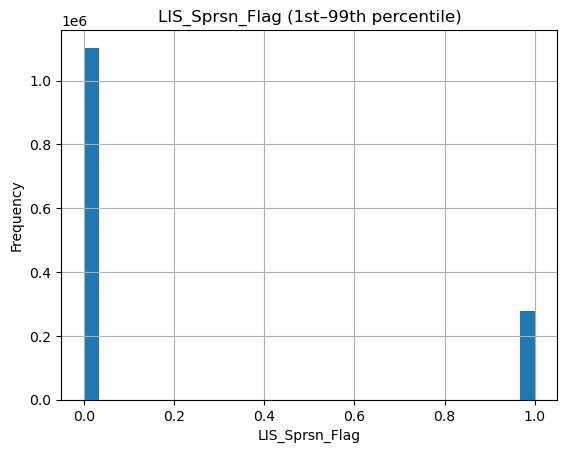

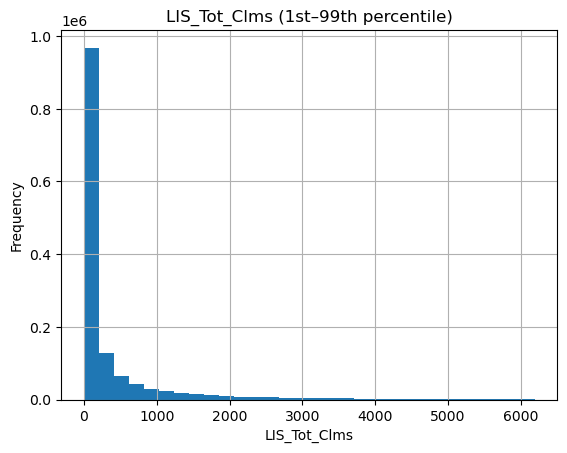

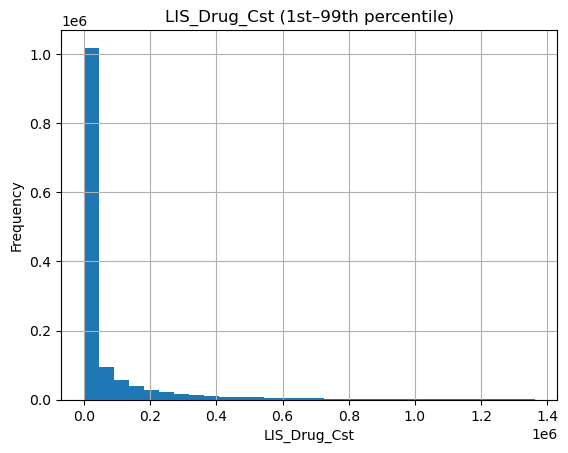

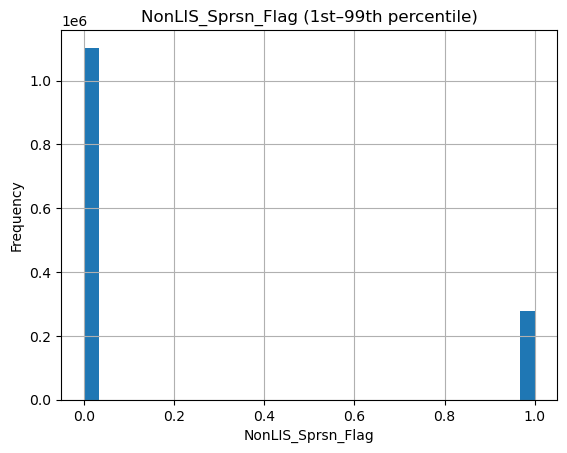

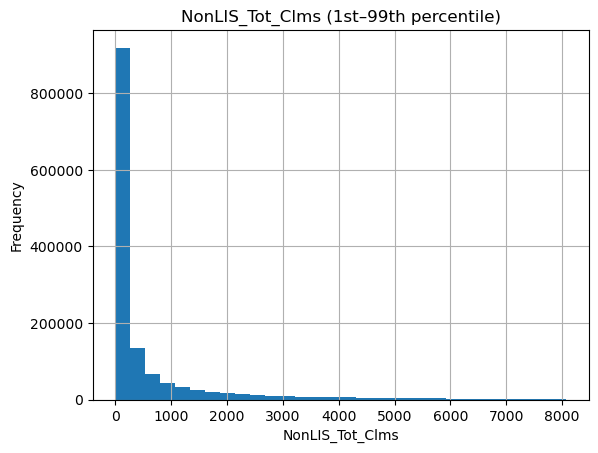

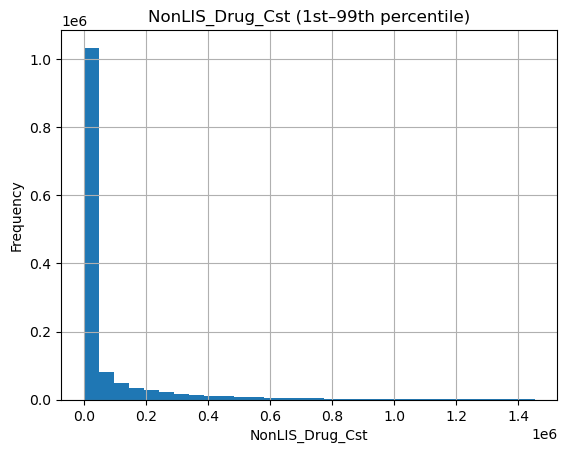

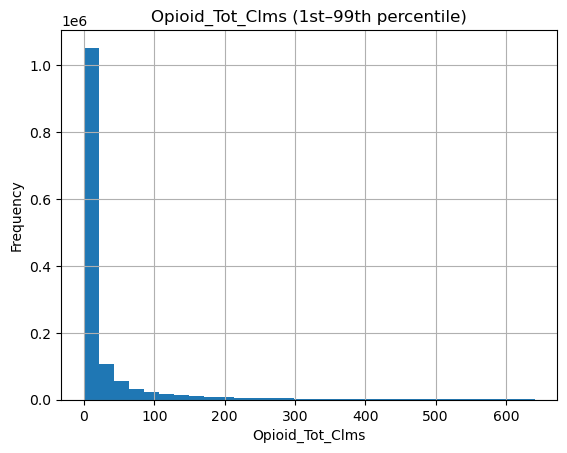

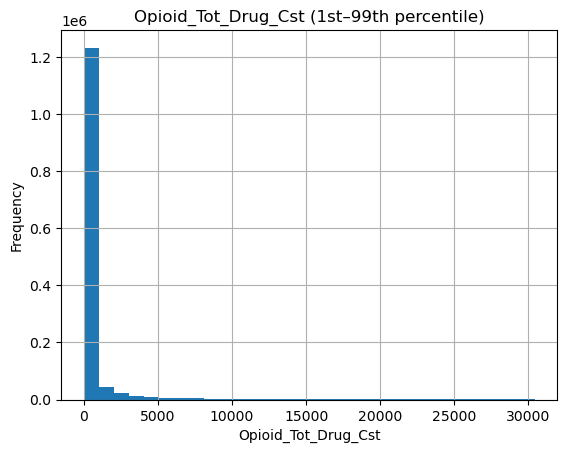

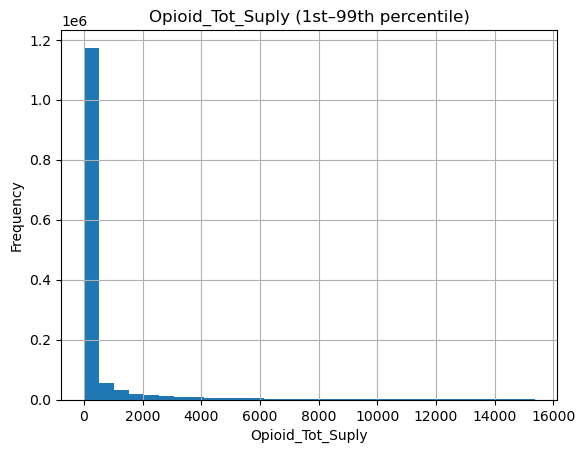

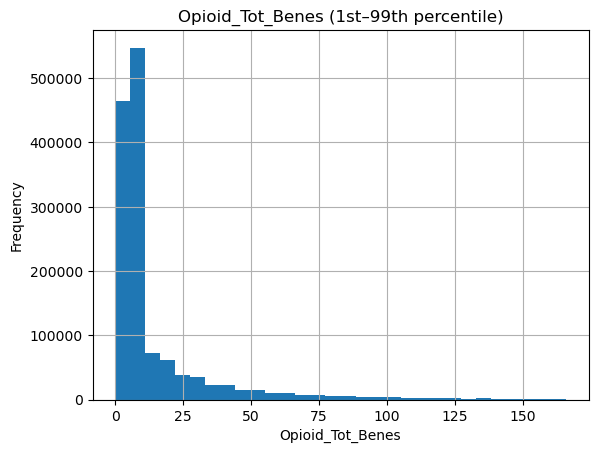

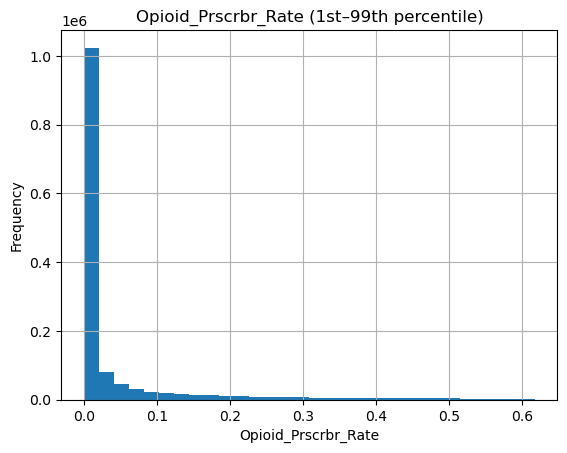

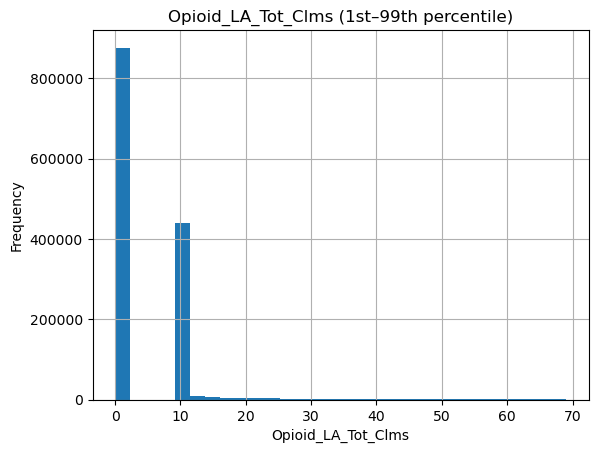

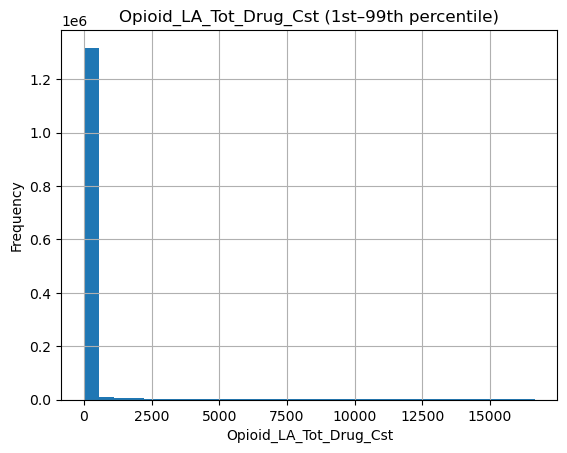

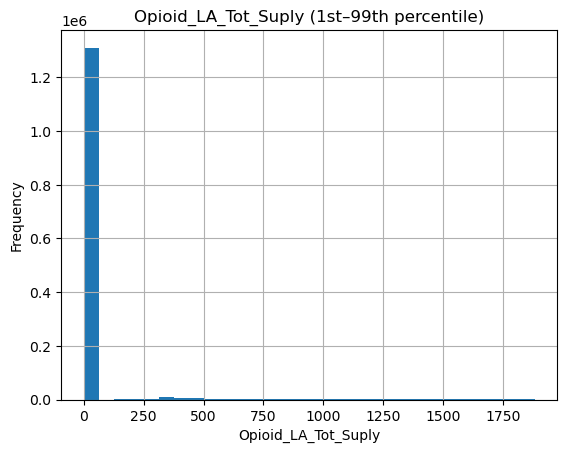

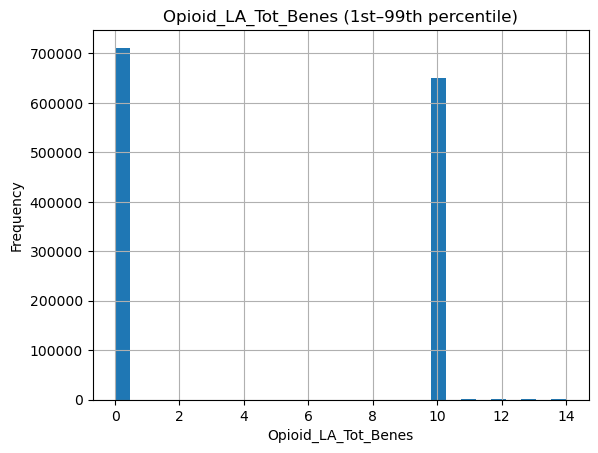

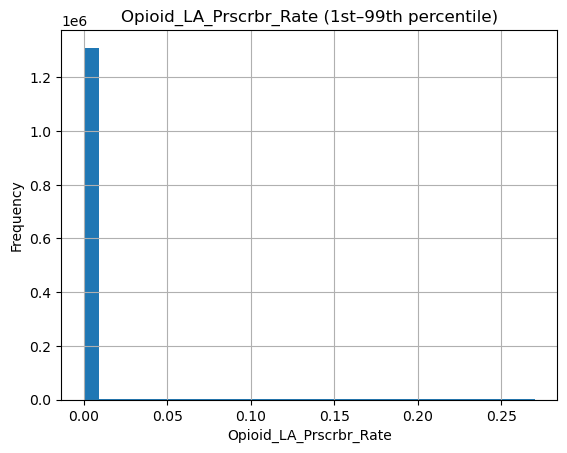

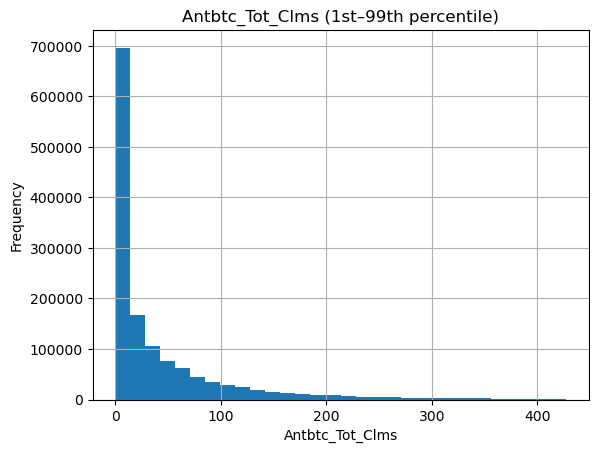

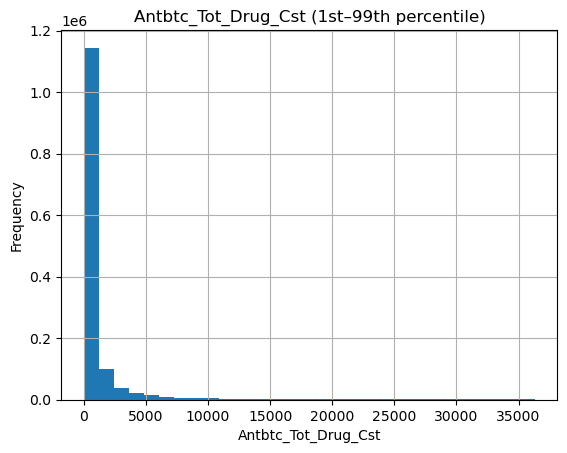

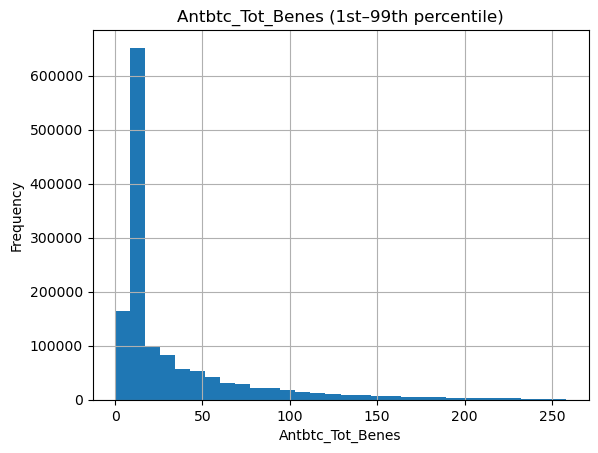

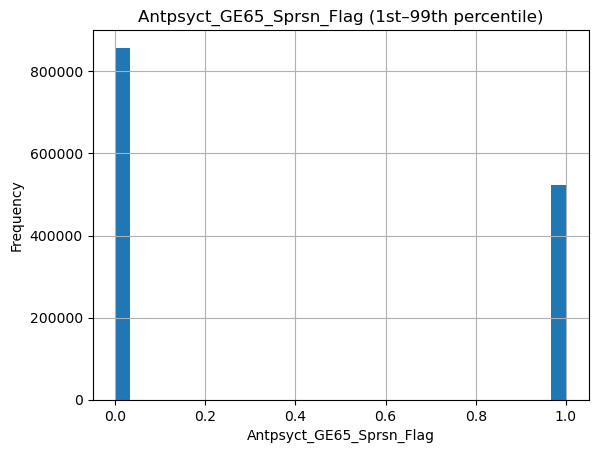

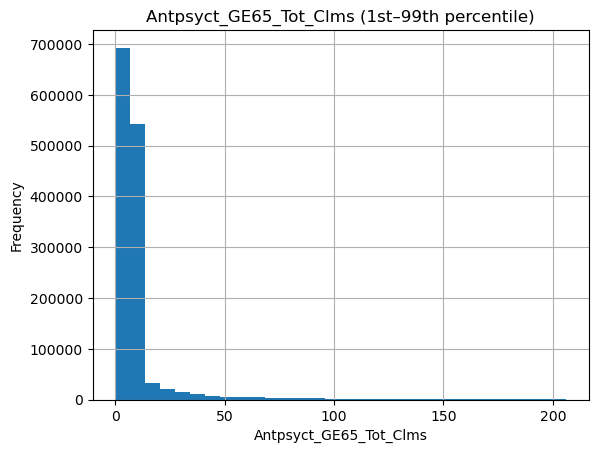

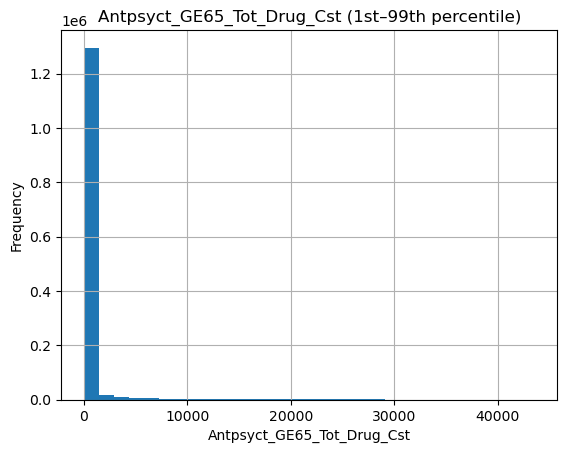

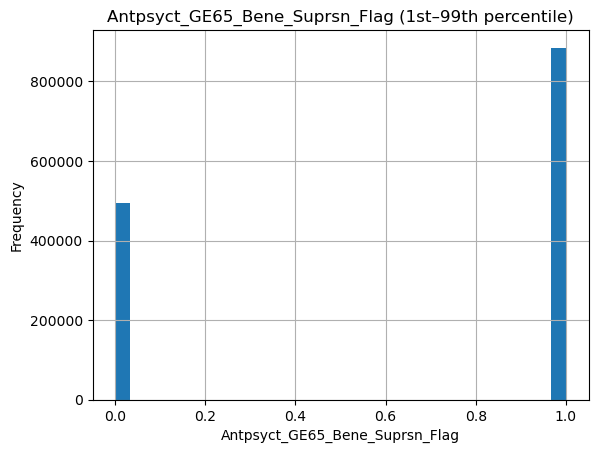

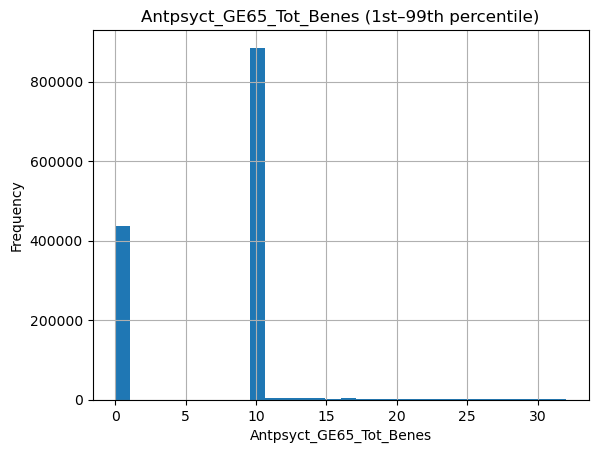

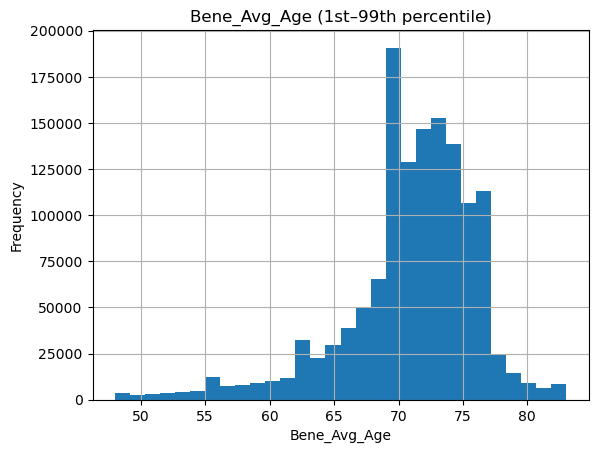

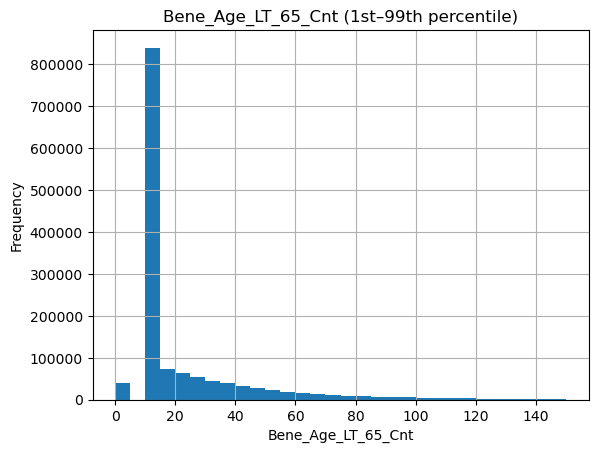

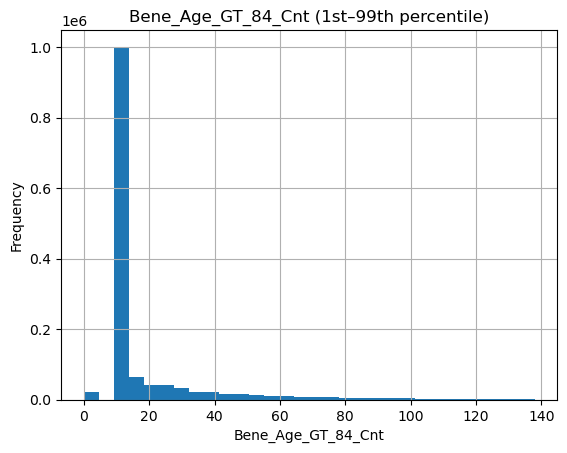

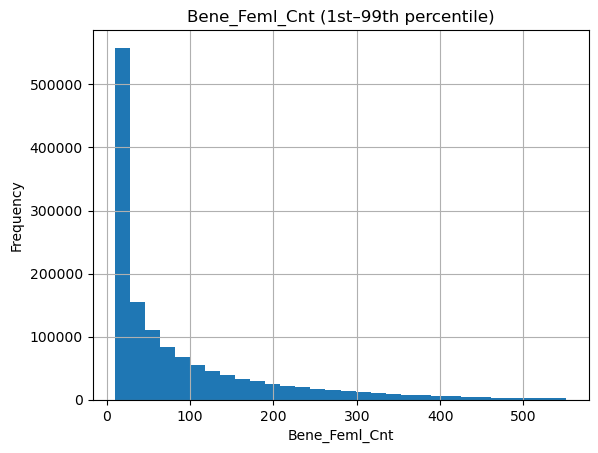

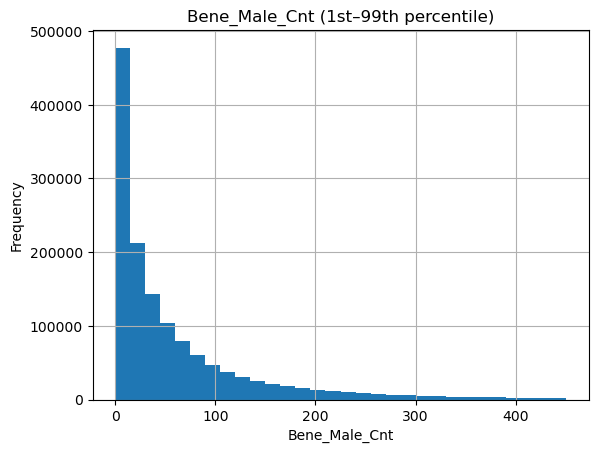

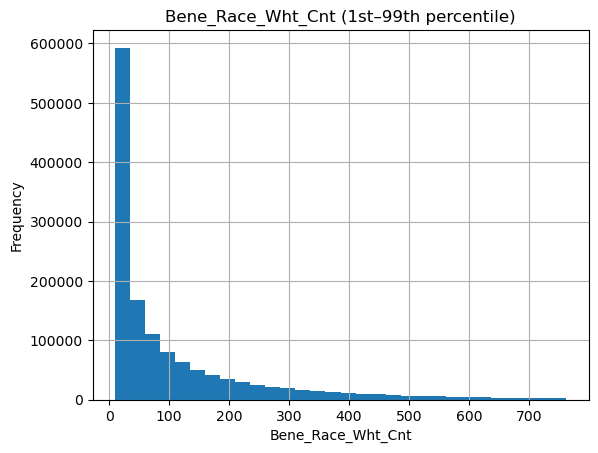

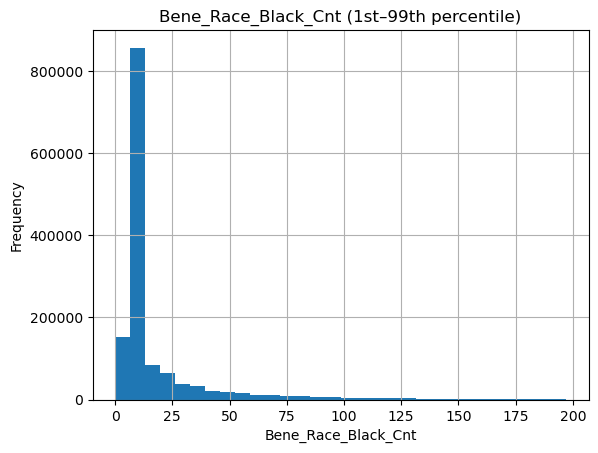

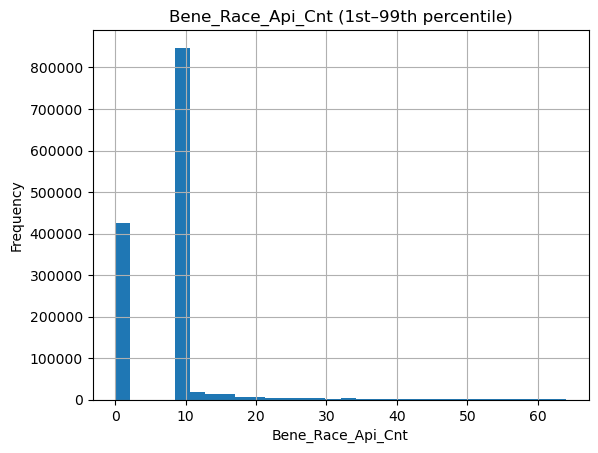

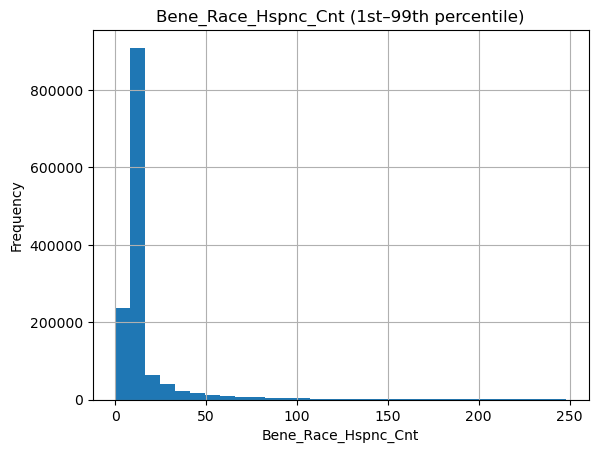

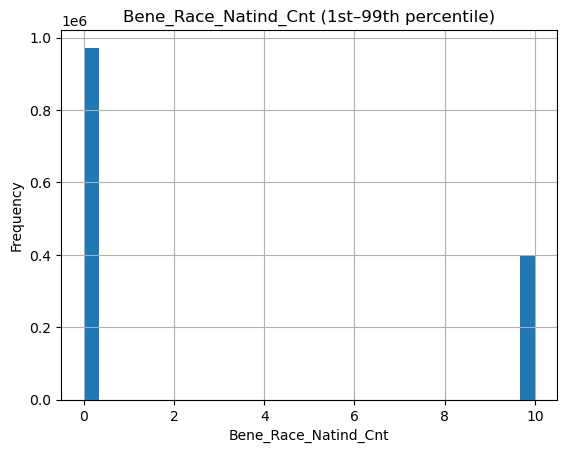

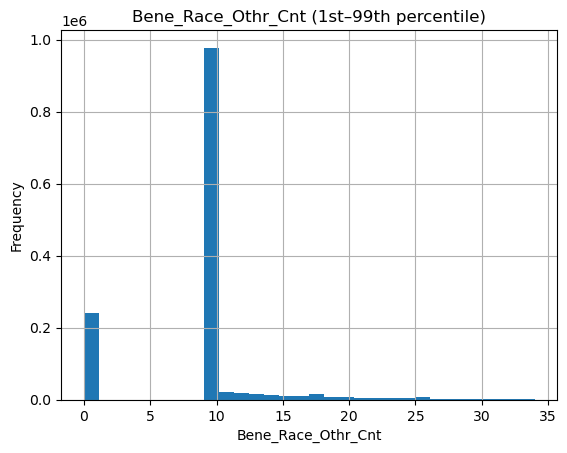

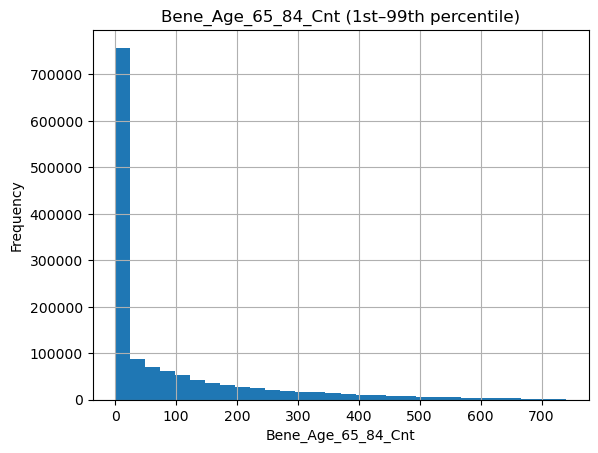

In [27]:
num_cols = df_op.select_dtypes(include='number').columns

for col in num_cols:
    lower = df_op[col].quantile(0.01)
    upper = df_op[col].quantile(0.99)
    
    df_op[col].hist(bins=30, range=(lower, upper))
    plt.title(f"{col} (1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [28]:
cat_cols = df_op.select_dtypes(include='string').columns

for col in cat_cols:
    df_op[col].value_counts().head(10).plot(kind='bar') #Change head count for more counts
    plt.title(col)
    plt.show()

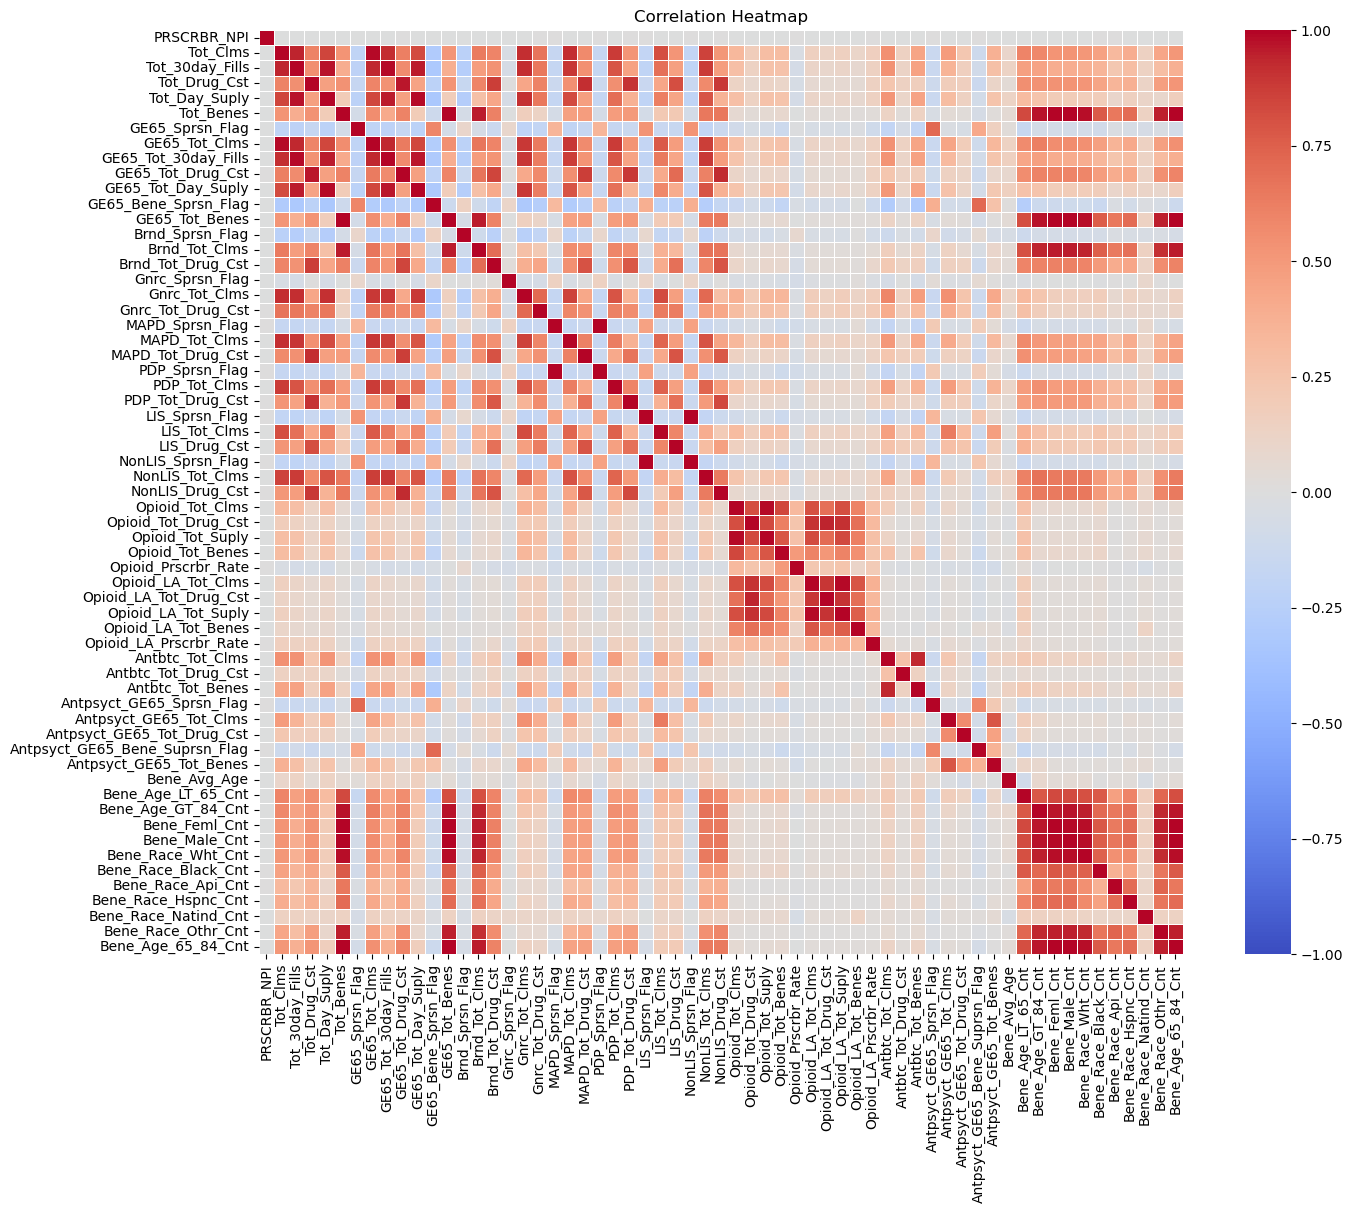

In [29]:
#I am specifying numeric columns with df_op_num.

df_op_num = df_op.select_dtypes(include = 'number')

matrix = df_op_num.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    matrix,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [30]:
#Cost per patient features

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Drug_Cst'] / df_op['Tot_Benes']

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Tot_Drug_Cst'] / df_op['GE65_Tot_Benes']

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Tot_Drug_Cst'] / df_op['Opioid_Tot_Benes']

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Tot_Drug_Cst'] / df_op['Opioid_LA_Tot_Benes']

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Tot_Drug_Cst'] / df_op['Antbtc_Tot_Benes']

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'] / df_op['Antpsyct_GE65_Tot_Benes']

#Fill NA from div/0

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Cst_Per_Bene'].fillna(0)

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Cst_Per_Bene'].fillna(0)

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Cst_Per_Bene'].fillna(0)

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Cst_Per_Bene'].fillna(0)

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Cst_Per_Bene'].fillna(0)

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Cst_Per_Bene'].fillna(0)

## Data Modeling

KPrototype is the model selected because the K-means modeling is not fit for data sets with categorical features.  
KPrototype is able to integrate both numerical and categorical data.  

A resource by Aprilliant (2021) was used to generate this k-prototypes model.  

Aprilliant, A. (2021, January 17). The k-prototype as clustering algorithm for mixed data type(Categorical and numerical). Towards Data Science. https://towardsdatascience.com/the-k-prototype-as-clustering-algorithm-for-mixed-data-type-categorical-and-numerical-fe7c50538ebb/

In [31]:
from kmodes.kprototypes import KPrototypes

In [32]:
# Creating my own copy of the operational data frame (ML).

df_op_ml = df_op.copy()

In [33]:
# Normalizing the opioid and long-acting opioid numerical data.

opioid_norm = df_op_ml.copy()
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,...,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,...,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,...,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,...,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,...,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,...,10.0,0.0,10.0,0.0,49.068846,39.698000,2.353333,0.00000,0.000000,0.0


In [34]:
# Normalizing opioid data to overall total data.

opioid_norm['Opioid_Tot_Clms_norm'] = opioid_norm['Opioid_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_Tot_Suply_norm'] = opioid_norm['Opioid_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_Tot_Benes_norm'] = opioid_norm['Opioid_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Opioid_LA_Tot_Clms_norm'] = opioid_norm['Opioid_LA_Tot_Clms']/opioid_norm['Tot_Clms']
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst']/opioid_norm['Tot_Drug_Cst']
opioid_norm['Opioid_LA_Tot_Suply_norm'] = opioid_norm['Opioid_LA_Tot_Suply']/opioid_norm['Tot_Day_Suply']
opioid_norm['Opioid_LA_Tot_Benes_norm'] = opioid_norm['Opioid_LA_Tot_Benes']/opioid_norm['Tot_Benes']
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene']/opioid_norm['Tot_Cst_Per_Bene']

pd.set_option('display.max_columns', None)
opioid_norm.head()

,PRSCRBR_NPI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_zip5,Prscrbr_RUCA,Prscrbr_Cntry,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes,Brnd_Sprsn_Flag,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Sprsn_Flag,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Sprsn_Flag,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Sprsn_Flag,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Sprsn_Flag,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Sprsn_Flag,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Clms,Opioid_Tot_Drug_Cst,Opioid_Tot_Suply,Opioid_Tot_Benes,Opioid_Prscrbr_Rate,Opioid_LA_Tot_Clms,Opioid_LA_Tot_Drug_Cst,Opioid_LA_Tot_Suply,Opioid_LA_Tot_Benes,Opioid_LA_Prscrbr_Rate,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antpsyct_GE65_Sprsn_Flag,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Bene_Suprsn_Flag,Antpsyct_GE65_Tot_Benes,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Age_65_84_Cnt,Tot_Cst_Per_Bene,GE65_Cst_Per_Bene,Opioid_Cst_Per_Bene,Opioid_LA_Cst_Per_Bene,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,GE65_Cst_Per_Bene_norm,Antbtc_Cst_Per_Bene_norm,Antpsyct_GE65_Cst_Per_Bene_norm
0,1003000126,M.D.,I,Bethesda,MD,20817.0,1.0,US,Hospitalist,Claim-Specialty,222,254.5,18399.98,5475,112.0,0,192.0,220.5,15997.83,4769.0,0,96.0,1,10.0,0.00,0,189.0,3170.22,0,91.0,9238.20,0,131.0,9161.78,0,66.0,7243.45,0,156.0,11156.53,13.0,43.68,77.0,13.0,0.059,0.0,0.00,0.0,0.0,0.000,42.0,731.76,39.0,1,10.0,0.0,1,10.0,76,16.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,66.0,164.285536,166.644062,3.360000,0.00000,18.763077,0.0,0.058559,0.002374,0.014064,0.116071,0.020452,0.000000,0.000000,0.000000,0.000000,0.000000,1.014356,0.114210,0.0
1,1003000142,M.D.,I,Toledo,OH,43623.0,1.0,US,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,55983,478.0,0,1017.0,1081.0,36179.85,29714.0,0,290.0,0,55.0,19957.16,0,1810.0,42666.24,0,1314.0,44891.82,0,551.0,17731.58,0,1398.0,50702.42,0,467.0,11920.98,850.0,26878.15,23387.0,358.0,0.456,65.0,12186.81,1903.0,24.0,0.076,10.0,0.00,10.0,0,0.0,0.0,0,0.0,67,188.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,270.0,131.011297,124.758103,75.078631,507.78375,0.000000,0.0,0.455764,0.429203,0.417752,0.748954,0.573070,0.034853,0.194605,0.033992,0.050209,3.875878,0.952270,0.000000,0.0
2,1003000167,DDS,I,Dayton,NV,89403.0,2.0,US,Dentist,NPPES-Specialty,118,119.0,456.67,806,59.0,0,105.0,106.0,413.64,703.0,1,10.0,1,10.0,0.00,0,108.0,383.19,0,46.0,156.89,0,72.0,299.78,0,13.0,31.52,0,105.0,425.15,10.0,0.00,0.0,10.0,0.000,10.0,0.00,0.0,10.0,0.000,60.0,266.45,49.0,0,0.0,0.0,1,10.0,72,10.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.0,7.740169,41.364000,0.000000,0.00000,5.437755,0.0,0.084746,0.000000,0.000000,0.169492,0.000000,0.084746,0.000000,0.000000,0.169492,0.000000,5.344069,0.702537,0.0
3,1003000423,M.D.,I,Cleveland,OH,44106.0,1.0,US,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,9260,64.0,0,134.0,274.3,10246.24,7351.0,1,10.0,0,17.0,10459.97,0,145.0,8669.06,0,72.0,12396.49,0,90.0,6732.54,0,31.0,8946.64,0,131.0,10182.39,0.0,0.00,0.0,0.0,0.000,0.0,0.00,0.0,0.0,0.000,10.0,0.00,10.0,0,0.0,0.0,1,10.0,70,10.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.0,298.891094,1024.624000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.428085,0.000000,0.0
4,1003000480,MD,I,Aurora,CO,80045.0,1.0,US,General Surgery,Claim-Specialty,41,47.1,1275.79,851,26.0,0,20.0,25.0,396.98,329.0,1,10.0,0,0.0,0.00,0,41.0,1275.79,0,24.

In [35]:
# Check for null values per column.

print(df_op_ml.isnull().sum())

PRSCRBR_NPI                       0
Prscrbr_Crdntls                   0
Prscrbr_Ent_Cd                    0
Prscrbr_City                      0
Prscrbr_State_Abrvtn              0
Prscrbr_zip5                      0
Prscrbr_RUCA                      0
Prscrbr_Cntry                     0
Prscrbr_Type                      0
Prscrbr_Type_src                  0
Tot_Clms                          0
Tot_30day_Fills                   0
Tot_Drug_Cst                      0
Tot_Day_Suply                     0
Tot_Benes                         0
GE65_Sprsn_Flag                   0
GE65_Tot_Clms                     0
GE65_Tot_30day_Fills              0
GE65_Tot_Drug_Cst                 0
GE65_Tot_Day_Suply                0
GE65_Bene_Sprsn_Flag              0
GE65_Tot_Benes                    0
Brnd_Sprsn_Flag                   0
Brnd_Tot_Clms                     0
Brnd_Tot_Drug_Cst                 0
Gnrc_Sprsn_Flag                   0
Gnrc_Tot_Clms                     0
Gnrc_Tot_Drug_Cst           

In [36]:
# Check for null values per column.

print(opioid_norm.isnull().sum())

PRSCRBR_NPI                         0
Prscrbr_Crdntls                     0
Prscrbr_Ent_Cd                      0
Prscrbr_City                        0
Prscrbr_State_Abrvtn                0
Prscrbr_zip5                        0
Prscrbr_RUCA                        0
Prscrbr_Cntry                       0
Prscrbr_Type                        0
Prscrbr_Type_src                    0
Tot_Clms                            0
Tot_30day_Fills                     0
Tot_Drug_Cst                        0
Tot_Day_Suply                       0
Tot_Benes                           0
GE65_Sprsn_Flag                     0
GE65_Tot_Clms                       0
GE65_Tot_30day_Fills                0
GE65_Tot_Drug_Cst                   0
GE65_Tot_Day_Suply                  0
GE65_Bene_Sprsn_Flag                0
GE65_Tot_Benes                      0
Brnd_Sprsn_Flag                     0
Brnd_Tot_Clms                       0
Brnd_Tot_Drug_Cst                   0
Gnrc_Sprsn_Flag                     0
Gnrc_Tot_Clm

In [37]:
# Rows that have at least one NaN (ML).

pd.set_option('display.max_columns', None)
nan_rows = opioid_norm[opioid_norm.isnull().any(axis=1)]
print(nan_rows)

         PRSCRBR_NPI  Prscrbr_Crdntls Prscrbr_Ent_Cd    Prscrbr_City  \
67214     1043870702  MSN, APRN, NP-C              I  Salt Lake City   
72543     1053377127               MD              I         Memphis   
101667    1073519666             M.D.              I       Allentown   
134819    1093815599      ARNP, CWOCN              I       Lake City   
144199    1104402080               MD              I         Atlanta   
158677    1114422334          Unknown              I       Northport   
182055    1134198534             M.D.              I       Salisbury   
223011    1164175030             CRNP              I      Pittsburgh   
231066    1164781282          Unknown              I       Las Vegas   
294236    1215251152             M.D.              I        Woodside   
490722    1356507891             O.D.              I      Trussville   
663771    1477991420             M.D.              I        Richmond   
718070    1518953017               MD              I       Louis

In [38]:
# Replace NaN in prdemo with zero, because, upon inspection, the costs were all zero.

opioid_norm['Opioid_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'] = opioid_norm['Opioid_LA_Tot_Drug_Cst_norm'].fillna(0)
opioid_norm['Opioid_Cst_Per_Bene_norm'] = opioid_norm['Opioid_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Opioid_LA_Cst_Per_Bene_norm'] = opioid_norm['Opioid_LA_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['GE65_Cst_Per_Bene_norm'] = opioid_norm['GE65_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antbtc_Cst_Per_Bene_norm'] = opioid_norm['Antbtc_Cst_Per_Bene_norm'].fillna(0)
opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'] = opioid_norm['Antpsyct_GE65_Cst_Per_Bene_norm'].fillna(0)

In [39]:
# Check for null values per column.

print(opioid_norm.isnull().sum())

PRSCRBR_NPI                        0
Prscrbr_Crdntls                    0
Prscrbr_Ent_Cd                     0
Prscrbr_City                       0
Prscrbr_State_Abrvtn               0
Prscrbr_zip5                       0
Prscrbr_RUCA                       0
Prscrbr_Cntry                      0
Prscrbr_Type                       0
Prscrbr_Type_src                   0
Tot_Clms                           0
Tot_30day_Fills                    0
Tot_Drug_Cst                       0
Tot_Day_Suply                      0
Tot_Benes                          0
GE65_Sprsn_Flag                    0
GE65_Tot_Clms                      0
GE65_Tot_30day_Fills               0
GE65_Tot_Drug_Cst                  0
GE65_Tot_Day_Suply                 0
GE65_Bene_Sprsn_Flag               0
GE65_Tot_Benes                     0
Brnd_Sprsn_Flag                    0
Brnd_Tot_Clms                      0
Brnd_Tot_Drug_Cst                  0
Gnrc_Sprsn_Flag                    0
Gnrc_Tot_Clms                      0
G

In [40]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer opioid-related features.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_opioid = opioid_norm[['Opioid_Prscrbr_Rate', 'Opioid_Tot_Clms_norm', 'Opioid_Tot_Drug_Cst_norm', 'Opioid_Tot_Suply_norm', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm']]
opioid_corr = X_opioid.corr()

opioid_corr

,Opioid_Prscrbr_Rate,Opioid_Tot_Clms_norm,Opioid_Tot_Drug_Cst_norm,Opioid_Tot_Suply_norm,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm
Opioid_Prscrbr_Rate,1.000000,0.680120,0.819772,0.905667,0.332734,0.633761
Opioid_Tot_Clms_norm,0.680120,1.000000,0.570620,0.628862,0.531241,0.409797
Opioid_Tot_Drug_Cst_norm,0.819772,0.570620,1.000000,0.896502,0.280067,0.803508
Opioid_Tot_Suply_norm,0.905667,0.628862,0.896502,1.000000,0.306562,0.660058
Opioid_Tot_Benes_norm,0.332734,0.531241,0.280067,0.306562,1.000000,0.154802
Opioid_Cst_Per_Bene_norm,0.633761,0.409797,0.803508,0.660058,0.154802,1.000000


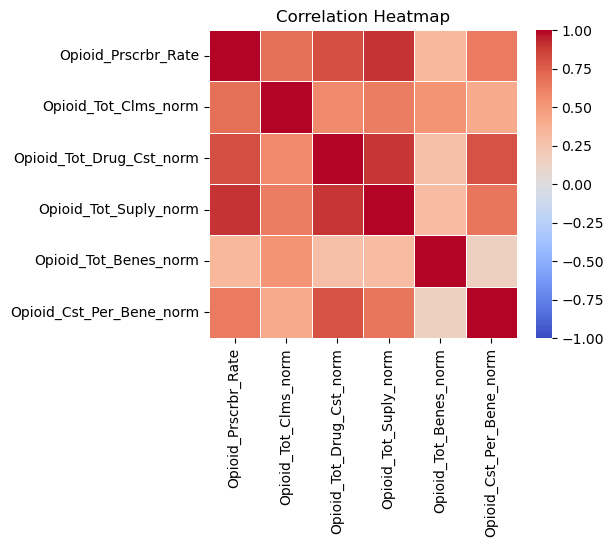

In [41]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [42]:
# Running the Principal Component Reduction on the opioid data.

opioid_pca = PCA(n_components = 6)
opioid_pca_c = opioid_pca.fit_transform(X_opioid)

In [43]:
# Looking at the variability explained by each component in opioid_pca.

opioid_pca.explained_variance_ratio_
opioid_ex_vratio = np.cumsum(opioid_pca.explained_variance_ratio_)
opioid_ex_vratio

array([0.62656479, 0.89101849, 0.96113888, 0.98995974, 0.99770053,
       1.        ])

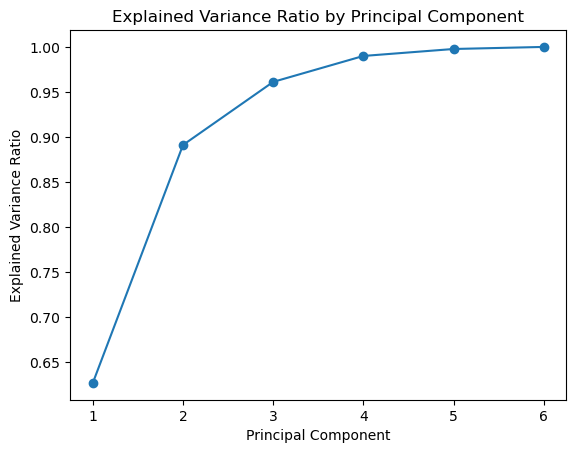

In [44]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_ex_vratio) + 1)
y = opioid_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [45]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_comps = opioid_pca.components_

opioid_comps_df = pd.DataFrame(
    opioid_comps,
    columns=X_opioid.columns,
    index=[f'PC{i+1}' for i in range(opioid_comps.shape[0])]
)

print(opioid_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_Prscrbr_Rate  Opioid_Tot_Clms_norm  Opioid_Tot_Drug_Cst_norm  \
PC1             0.193027              0.312335                  0.140908   
PC2             0.345020              0.232312                  0.316914   
PC3             0.289463              0.740154                 -0.000479   
PC4             0.586871             -0.545426                  0.284665   
PC5            -0.592988              0.055936                  0.730904   
PC6            -0.252704              0.005638                 -0.514252   

     Opioid_Tot_Suply_norm  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  
PC1               0.122072               0.886040                  0.212988  
PC2               0.237127              -0.410420                  0.708437  
PC3               0.139330              -0.210399                 -0.551999  
PC4               0.398397               0.046199                 -0.340888  
PC5               0.292428              -0.008729                 -0.159451  

In [46]:
# From the ratio plot, the top 2 variables explain 89% of the variance in the data.
# From the table above, Opioid_Tot_Benes_norm (PC1 value = 0.89, 63% of variance) and Opioid_Cst_Per_Bene_norm (PC2 value = 0.71, 89% of variance) will be those two variables.
# These two variables can be used to represent the opioid data.

In [47]:
# Preparing for a Principal Component Reduction to focus the analysis on fewer long-acting opioid-related features.

X_opioid_LA = opioid_norm[['Opioid_LA_Prscrbr_Rate', 'Opioid_LA_Tot_Clms_norm', 'Opioid_LA_Tot_Drug_Cst_norm', 'Opioid_LA_Tot_Suply_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
opioid_LA_corr = X_opioid_LA.corr()

opioid_LA_corr

,Opioid_LA_Prscrbr_Rate,Opioid_LA_Tot_Clms_norm,Opioid_LA_Tot_Drug_Cst_norm,Opioid_LA_Tot_Suply_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
Opioid_LA_Prscrbr_Rate,1.000000,0.017263,0.527893,0.599291,-0.030618,0.427326
Opioid_LA_Tot_Clms_norm,0.017263,1.000000,0.071138,0.085200,0.458601,0.020411
Opioid_LA_Tot_Drug_Cst_norm,0.527893,0.071138,1.000000,0.866272,0.015166,0.712107
Opioid_LA_Tot_Suply_norm,0.599291,0.085200,0.866272,1.000000,0.024758,0.486035
Opioid_LA_Tot_Benes_norm,-0.030618,0.458601,0.015166,0.024758,1.000000,-0.026707
Opioid_LA_Cst_Per_Bene_norm,0.427326,0.020411,0.712107,0.486035,-0.026707,1.000000


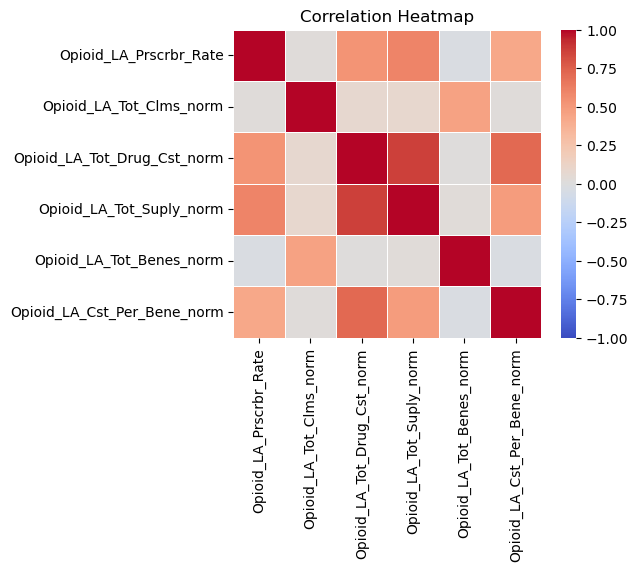

In [48]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    opioid_LA_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [49]:
# Running the Principal Component Reduction on the long-acting opioid data.

opioid_LA_pca = PCA(n_components = 6)
opioid_LA_pca_c = opioid_LA_pca.fit_transform(X_opioid_LA)

In [50]:
# Looking at the variability explained by each component in opioid_LA_pca.

opioid_LA_pca.explained_variance_ratio_
opioid_LA_ex_vratio = np.cumsum(opioid_LA_pca.explained_variance_ratio_)
opioid_LA_ex_vratio

array([0.53847666, 0.94708878, 0.98790474, 0.99682085, 0.99987379,
       1.        ])

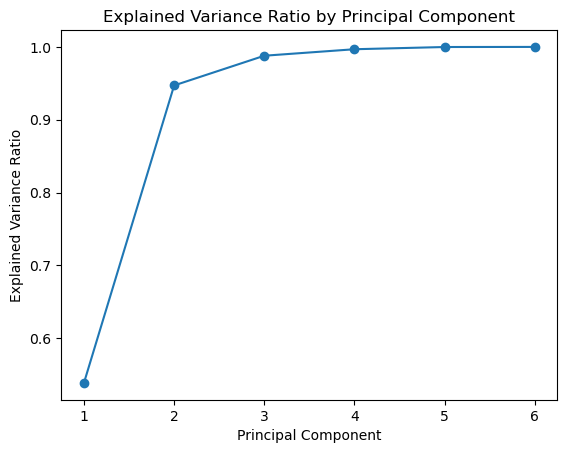

In [51]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(opioid_LA_ex_vratio) + 1)
y = opioid_LA_ex_vratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [52]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

opioid_LA_comps = opioid_LA_pca.components_

opioid_LA_comps_df = pd.DataFrame(
    opioid_LA_comps,
    columns=X_opioid_LA.columns,
    index=[f'PC{i+1}' for i in range(opioid_LA_comps.shape[0])]
)

print(opioid_LA_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Opioid_LA_Prscrbr_Rate  Opioid_LA_Tot_Clms_norm  \
PC1                0.059081                -0.004858   
PC2                0.002396                 0.184851   
PC3                0.013075                 0.982382   
PC4                0.918467                -0.021270   
PC5               -0.386812                -0.016607   
PC6               -0.055926                -0.001986   

     Opioid_LA_Tot_Drug_Cst_norm  Opioid_LA_Tot_Suply_norm  \
PC1                     0.082658                  0.018564   
PC2                     0.012243                  0.003464   
PC3                     0.019894                  0.009460   
PC4                     0.346845                  0.167785   
PC5                     0.881549                  0.264296   
PC6                    -0.308531                  0.949500   

     Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
PC1                 -0.088550                     0.990691  
PC2                  0.978808                     

In [53]:
# From the ratio plot, the top 2 variables explain 95% of the variance in the data.
# From the table above, Opioid_LA_Cst_Per_Bene_norm (PC1 value = 0.99, 54% of variance) and Opioid_LA_Tot_Benes_norm (PC2 value = 0.98, 95% of variance) will be those two variables.
# These two varaibles can be used to represent the long-acting opioid data.

### Prescriber Demographic Information

In [54]:
# Creating subset of the data: prescriber demographics + opioid data.

prdemo = opioid_norm[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm']]
prdemo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,222,254.5,18399.98,5475,112.0,164.285536,0.116071,0.020452,0.000000,0.000000
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,1865,1999.5,62623.40,55983,478.0,131.011297,0.748954,0.573070,3.875878,0.050209
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,118,119.0,456.67,806,59.0,7.740169,0.169492,0.000000,0.000000,0.169492
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,162,340.0,19129.03,9260,64.0,298.891094,0.000000,0.000000,0.000000,0.000000
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,41,47.1,1275.79,851,26.0,49.068846,0.576923,0.047960,0.000000,0.000000


In [55]:
# Checking data types in prdemo.

print(prdemo.dtypes)

Prscrbr_Crdntls                 object
Prscrbr_Ent_Cd                  object
Prscrbr_City                    object
Prscrbr_State_Abrvtn            object
Prscrbr_RUCA                    object
Prscrbr_Type                    object
Prscrbr_Type_src                object
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


In [56]:
# Converting objects to strings.

prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)
print(prdemo.dtypes)

Prscrbr_Crdntls                 object
Prscrbr_Ent_Cd                  object
Prscrbr_City                    object
Prscrbr_State_Abrvtn            object
Prscrbr_RUCA                    object
Prscrbr_Type                    object
Prscrbr_Type_src                object
Tot_Clms                         int64
Tot_30day_Fills                float64
Tot_Drug_Cst                   float64
Tot_Day_Suply                    int64
Tot_Benes                      float64
Tot_Cst_Per_Bene               float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
Opioid_LA_Tot_Benes_norm       float64
dtype: object


C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\488052295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prdemo['Prscrbr_RUCA'] = prdemo['Prscrbr_RUCA'].apply(str)


In [57]:
# Standardizing numeric data to zscore.

prdemo_num = prdemo[['Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
prdemo_numz = pd.DataFrame(stats.zscore(prdemo_num, nan_policy = 'omit'), columns = prdemo_num.columns)
prdemo_numz.head()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.313619,-0.364279,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874
1,0.229793,-0.026229,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701
2,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.333463,-0.347716,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874


In [58]:
# Comparing against mean values and standard deviations in each column in prdemo_num.

print(prdemo_num.describe())

           Tot_Clms  Tot_30day_Fills  Tot_Drug_Cst  Tot_Day_Suply  \
count  1.380665e+06     1.380665e+06  1.380665e+06   1.380665e+06   
mean   1.170223e+03     2.134890e+03  1.996484e+05   5.963938e+04   
std    3.023489e+03     5.161947e+03  6.444544e+05   1.430670e+05   
min    1.100000e+01     1.100000e+01  0.000000e+00   1.100000e+01   
25%    5.900000e+01     7.200000e+01  1.849030e+03   1.073000e+03   
50%    2.090000e+02     2.662000e+02  1.339771e+04   5.212000e+03   
75%    9.260000e+02     1.459100e+03  1.389983e+05   3.957600e+04   
max    6.662510e+05     6.673819e+05  1.602919e+08   7.288659e+06   

          Tot_Benes  Tot_Cst_Per_Bene  Opioid_Tot_Benes_norm  \
count  1.380665e+06      1.380665e+06           1.380665e+06   
mean   1.607810e+02      1.022297e+03           2.420434e-01   
std    8.927201e+02      4.124140e+03           3.307473e-01   
min    1.000000e+01      0.000000e+00           0.000000e+00   
25%    2.500000e+01      3.776759e+01           0.000000e+

In [59]:
# Concatenate standardized columns (prdemo_numz) with categorical columns from prdemo.

prdemo_cat = prdemo[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']]

prdemo_f = pd.concat([prdemo_cat, prdemo_numz], axis = 1)
prdemo_f.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.313619,-0.364279,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.229793,-0.026229,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.333463,-0.347716,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874


In [60]:
# Need indices for categorical data.

prdemo_cat_col_pos = [prdemo_f.columns.get_loc(col) for col in list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)]
print('Categorical columns: {}'.format(list(prdemo_f.select_dtypes(include = ['object', 'string', 'category']).columns)))
print('Categorical columns position: {}'.format(prdemo_cat_col_pos))

Categorical columns: ['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src']
Categorical columns position: [0, 1, 2, 3, 4, 5, 6]


In [61]:
# Check for null values per column. I got an error when trying to run the kprototypes model.

print(prdemo_f.isnull().sum())

Prscrbr_Crdntls                0
Prscrbr_Ent_Cd                 0
Prscrbr_City                   0
Prscrbr_State_Abrvtn           0
Prscrbr_RUCA                   0
Prscrbr_Type                   0
Prscrbr_Type_src               0
Tot_Clms                       0
Tot_30day_Fills                0
Tot_Drug_Cst                   0
Tot_Day_Suply                  0
Tot_Benes                      0
Tot_Cst_Per_Bene               0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [62]:
# For debugging purposes: create a sample set of prdemo (10% of data) for model optimization purposes.

#prdemo_f_10 = prdemo_f.sample(frac = 0.1, random_state = 0)
#prdemo_f_10.describe()

In [63]:
# prdemo_f summary.

prdemo_f.describe()

,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
count,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06,1.380665e+06
mean,1.169258e-17,1.165141e-16,5.796883e-17,-1.342176e-17,6.772637e-18,-2.215002e-17,-7.476662e-17,-1.210429e-17,-3.793912e-17,-1.482158e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.834057e-01,-4.114515e-01,-3.097946e-01,-4.167865e-01,-1.689007e-01,-2.478815e-01,-7.318079e-01,-3.337595e-01,-5.414898e-01,-1.198739e-01
25%,-3.675300e-01,-3.996343e-01,-3.069254e-01,-4.093634e-01,-1.520982e-01,-2.387238e-01,-7.318079e-01,-3.337595e-01,-5.414898e-01,-1.198739e-01
50%,-3.179184e-01,-3.620128e-01,-2.890053e-01,-3.804329e-01,-9.608954e-02,-1.852909e-01,-4.688985e-01,-3.337595e-01,-5.414898e-01,-1.198739e-01
75%,-8.077511e-02,-1.309177e-01,-9.411076e-02,-1.402377e-01,4.729252e-02,-3.160383e-02,2.760113e-01,-1.946925e-01,-7.372483e-02,-1.198739e-01
max,2.199714e+02,1.288753e+02,2.484153e+02,5.052892e+01,5.509570e+02,2.878500e+02,2.291650e+00,7.870839e+01,2.592535e+00,8.033090e+01


In [64]:
# Remove opioid data from prdemo_f.

prdemo_fo = prdemo_f[['Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_RUCA', 'Prscrbr_Type', 'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst', 'Tot_Day_Suply', 'Tot_Benes', 'Tot_Cst_Per_Bene']]
prdemo_fo.head()

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.313619,-0.364279,-0.281243,-0.378595,-0.054643,-0.208046
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.229793,-0.026229,-0.212622,-0.025557,0.355340,-0.216115
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.333463,-0.347716,-0.280112,-0.352138,-0.108411,-0.175408
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983


In [65]:
# Convert the data frame to a matrix.

prdemo_fmat = prdemo_fo.to_numpy()

In [66]:
from plotnine import *
import plotnine as p9

Cluster initiation: 1
Cluster initiation: 2
Cluster initiation: 3
Cluster initiation: 4
Cluster initiation: 5
Cluster initiation: 6
Cluster initiation: 7
Cluster initiation: 8
Cluster initiation: 9


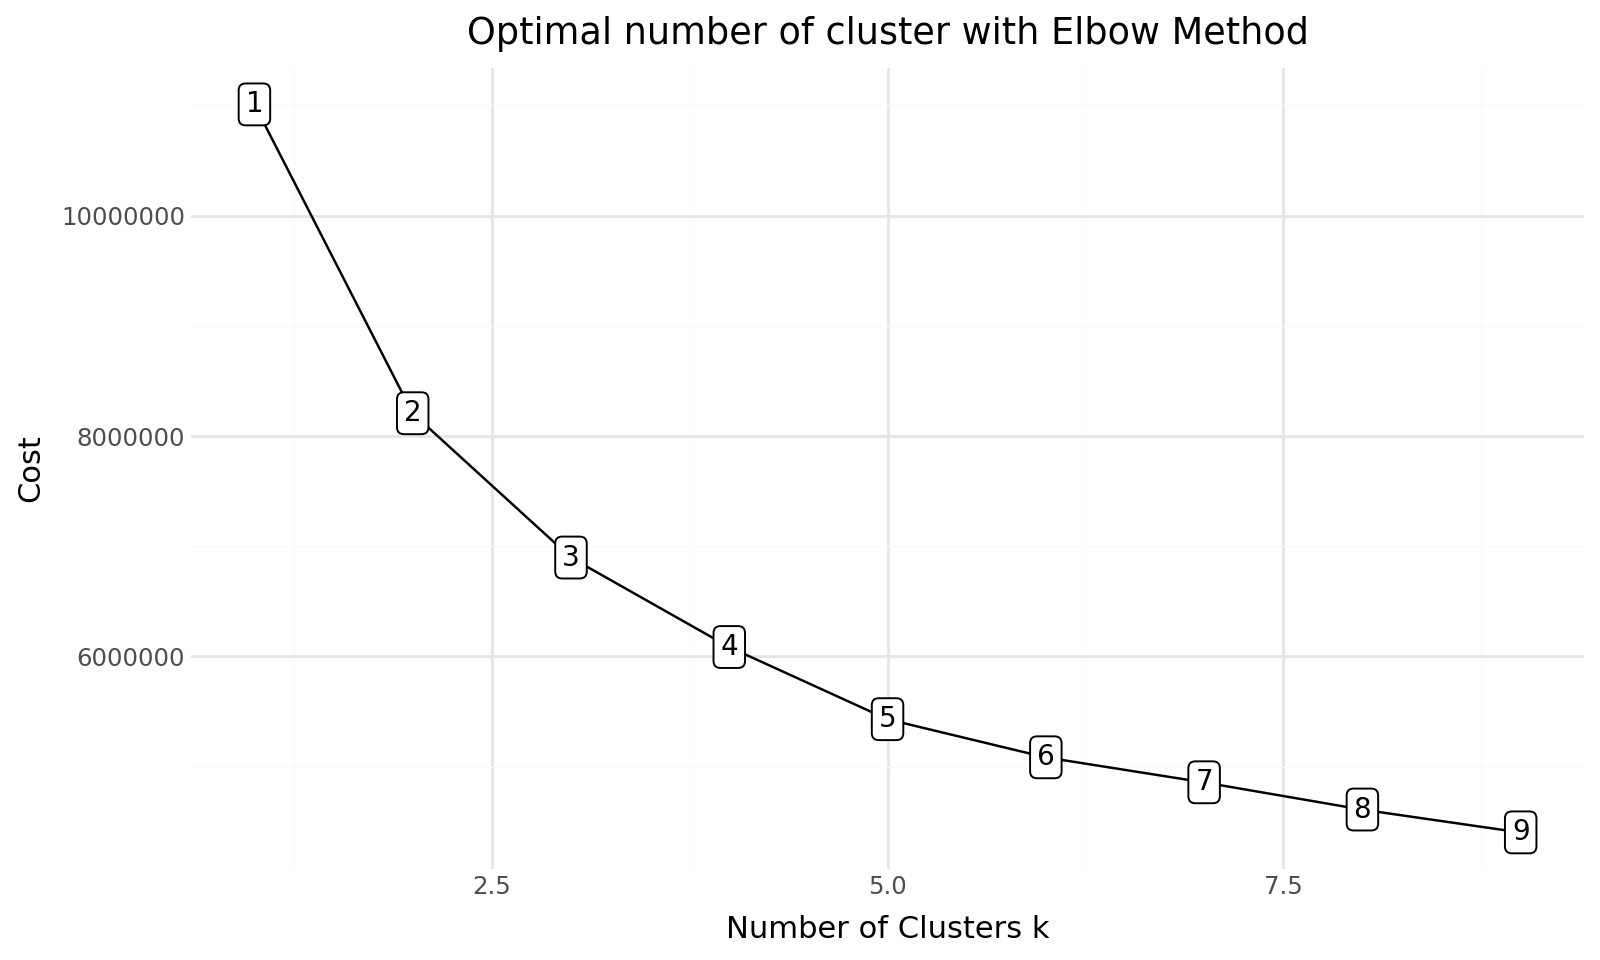

In [67]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)
        cost.append(kprototype_prdemo.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
prdemo_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = prdemo_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [67]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_prdemo.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([0, 0, 0, ..., 0, 0, 0], shape=(1380665,), dtype=uint16)

In [68]:
# Cluster centorid

kprototype_prdemo.cluster_centroids_

array([['-0.20166358472140786', '-0.23202781975715628',
        '-0.1487121000737681', '-0.2393914655493168',
        '-0.04877837197001326', '-0.05328858273246289', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty'],
       ['2.26144921379487', '2.6103002001735227', '1.6612621286553786',
        '2.7017479794792028', '0.5129821964569602', '0.601510488682315',
        'MD', 'I', 'Houston', 'CA', '1.0', 'Family Practice',
        'Claim-Specialty'],
       ['87.41132098437835', '51.20713710406302', '102.2537832372858',
        '1.9303549266703586', '222.31577031013177',
        '-0.1670665894483557', 'M.D.', 'I', 'Charlotte', 'TX', '1.0',
        'Family Practice', 'Claim-Specialty']], dtype='<U32')

In [69]:
# Check the iteration of the clusters created

kprototype_prdemo.n_iter_

13

In [70]:
# Check the cost of the clusters created

kprototype_prdemo.cost_

np.float64(6896285.553894215)

In [71]:
# Add the clusters to the prdemo_f dataframe.

prdemo_f3 = prdemo_f.copy()

prdemo_f3['Cluster Labels'] = kprototype_prdemo.labels_
prdemo_f3['Segment'] = prdemo_f3['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
prdemo_f3['Segment'] = prdemo_f3['Segment'].astype('category')
prdemo_f3['Segment'] = prdemo_f3['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

prdemo_f3.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.313619,-0.364279,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.229793,-0.026229,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.333463,-0.347716,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,DO,I,Quakertown,PA,1.0,Internal Medicine,Claim-Specialty,1.927832,2.372518,0.398230,2.529442,0.421430,-0.041850,-0.585421,0.010389,-0.483128,0.145063,1,Cluster 2
6,"M.D., PH.D",I,Tulsa,OK,1.0,Urology,Claim-Specialty,0.253607,0.245239,0.123852,0.188797,0.571533,-0.146893,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,MD,I,Los Angeles,CA,1.0,Cardiac Surgery,Claim-Specialty,-0.374145,-0.405252,-0.306698,-0.409608,-0.168901,-0.199497,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,N. P.,I,Fresno,CA,1.0,Nurse Practitioner,NPPES-Specialty,-0.382744,-0.411064,-0.309701,-0.416437,-0.168901,-0.246422,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,DNP,I,Fort Myers,FL,1.0,Nurse Practitioner,Claim-Specialty,-0.249785,-0.323403,-0.293541,-0.369864,0.108902,-0.238037,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [72]:
# Cluster interpretation

prdemo_f3.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f3.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\519040112.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1268282,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.201664,-0.232028,-0.148712,-0.239391,-0.048778,-0.053289,0.042382,-0.001226,0.043446,-0.020741
1,Cluster 2,112364,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,2.261449,2.610300,1.661262,2.701748,0.512982,0.601510,-0.478256,0.013831,-0.490299,0.234113
2,Cluster 3,19,M.D.,I,Highland Park,TX,1.0,Family Practice,Claim-Specialty,87.411321,51.207137,102.253783,1.930355,222.315770,-0.167067,-0.731517,0.035474,-0.541350,-0.011097


In [73]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, with concerns of overfitting, the model was adjusted for 2 clusters, shown above.

In [74]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_prdemo2 = KPrototypes(n_jobs = -1, n_clusters = 2, init = 'Huang', random_state = 0)
kprototype_prdemo2.fit_predict(prdemo_fmat, categorical = prdemo_cat_col_pos)

array([0, 0, 0, ..., 0, 0, 0], shape=(1380665,), dtype=uint16)

In [75]:
# Cluster centorid

kprototype_prdemo2.cluster_centroids_

array([['-0.20059278919055978', '-0.2307666289538259',
        '-0.1476498101346539', '-0.2380715930523868',
        '-0.048466758142889144', '-0.052600300125676264', 'MD', 'I',
        'New York', 'CA', '1.0', 'Nurse Practitioner', 'Claim-Specialty'],
       ['2.290179335242556', '2.634675787829483', '1.6857263184149625',
        '2.7180769803183535', '0.5533477469109059', '0.6005406319013579',
        'MD', 'I', 'Houston', 'CA', '1.0', 'Family Practice',
        'Claim-Specialty']], dtype='<U32')

In [76]:
# Check the iteration of the clusters created

kprototype_prdemo2.n_iter_

13

In [77]:
# Check the cost of the clusters created

kprototype_prdemo2.cost_

np.float64(8205654.275281386)

In [78]:
# Add the clusters to the prdemo_f dataframe.

prdemo_f2 = prdemo_f.copy()

prdemo_f2['Cluster Labels'] = kprototype_prdemo2.labels_
prdemo_f2['Segment'] = prdemo_f2['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
prdemo_f2['Segment'] = prdemo_f2['Segment'].astype('category')
prdemo_f2['Segment'] = prdemo_f2['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

prdemo_f2.head(50)

,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,M.D.,I,Bethesda,MD,1.0,Hospitalist,Claim-Specialty,-0.313619,-0.364279,-0.281243,-0.378595,-0.054643,-0.208046,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,M.D.,I,Toledo,OH,1.0,Anesthesiology,Claim-Specialty,0.229793,-0.026229,-0.212622,-0.025557,0.355340,-0.216115,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,DDS,I,Dayton,NV,2.0,Dentist,NPPES-Specialty,-0.348016,-0.390529,-0.309086,-0.411230,-0.114012,-0.246005,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,M.D.,I,Cleveland,OH,1.0,Obstetrics & Gynecology,Claim-Specialty,-0.333463,-0.347716,-0.280112,-0.352138,-0.108411,-0.175408,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,MD,I,Aurora,CO,1.0,General Surgery,Claim-Specialty,-0.373483,-0.404458,-0.307815,-0.410915,-0.150978,-0.235983,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,DO,I,Quakertown,PA,1.0,Internal Medicine,Claim-Specialty,1.927832,2.372518,0.398230,2.529442,0.421430,-0.041850,-0.585421,0.010389,-0.483128,0.145063,1,Cluster 2
6,"M.D., PH.D",I,Tulsa,OK,1.0,Urology,Claim-Specialty,0.253607,0.245239,0.123852,0.188797,0.571533,-0.146893,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,MD,I,Los Angeles,CA,1.0,Cardiac Surgery,Claim-Specialty,-0.374145,-0.405252,-0.306698,-0.409608,-0.168901,-0.199497,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,N. P.,I,Fresno,CA,1.0,Nurse Practitioner,NPPES-Specialty,-0.382744,-0.411064,-0.309701,-0.416437,-0.168901,-0.246422,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,DNP,I,Fort Myers,FL,1.0,Nurse Practitioner,Claim-Specialty,-0.249785,-0.323403,-0.293541,-0.369864,0.108902,-0.238037,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [79]:
# Cluster interpretation

prdemo_f2.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f2.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\2687384955.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1269474,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.200593,-0.230767,-0.147650,-0.238072,-0.048467,-0.052600,0.041880,-0.001199,0.042966,-0.020568
1,Cluster 2,111191,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,2.290179,2.634676,1.685726,2.718077,0.553348,0.600541,-0.478147,0.013692,-0.490544,0.234826


### Beneficiaries Age 65+

In [80]:
# Creating subset of the data: beneficiaries aged 65+ + opioid data.

ge65 = opioid_norm[['GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Tot_Benes', 'GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65.head()

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,192.0,220.5,15997.83,4769.0,96.0,166.644062,0.116071,0.020452,0.000000,0.000000
1,1017.0,1081.0,36179.85,29714.0,290.0,124.758103,0.748954,0.573070,0.050209,3.875878
2,105.0,106.0,413.64,703.0,10.0,41.364000,0.169492,0.000000,0.169492,0.000000
3,134.0,274.3,10246.24,7351.0,10.0,1024.624000,0.000000,0.000000,0.000000,0.000000
4,20.0,25.0,396.98,329.0,10.0,39.698000,0.576923,0.047960,0.000000,0.000000


In [81]:
# Checking data types in ge65.

print(ge65.dtypes)

GE65_Tot_Clms                  float64
GE65_Tot_30day_Fills           float64
GE65_Tot_Drug_Cst              float64
GE65_Tot_Day_Suply             float64
GE65_Tot_Benes                 float64
GE65_Cst_Per_Bene              float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [82]:
# Check for null values per column.
print(ge65.isnull().sum())

GE65_Tot_Clms                  0
GE65_Tot_30day_Fills           0
GE65_Tot_Drug_Cst              0
GE65_Tot_Day_Suply             0
GE65_Tot_Benes                 0
GE65_Cst_Per_Bene              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [83]:
# Preparing for a Principal Component Reduction.

X_ge65 = ge65.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
ge65_corr = X_ge65.corr()

ge65_corr

,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Tot_Benes,GE65_Cst_Per_Bene
GE65_Tot_Clms,1.000000,0.937499,0.635519,0.836857,0.551410,0.073864
GE65_Tot_30day_Fills,0.937499,1.000000,0.569913,0.967070,0.398090,0.073933
GE65_Tot_Drug_Cst,0.635519,0.569913,1.000000,0.463682,0.597512,0.335666
GE65_Tot_Day_Suply,0.836857,0.967070,0.463682,1.000000,0.179612,0.077046
GE65_Tot_Benes,0.551410,0.398090,0.597512,0.179612,1.000000,-0.008732
GE65_Cst_Per_Bene,0.073864,0.073933,0.335666,0.077046,-0.008732,1.000000


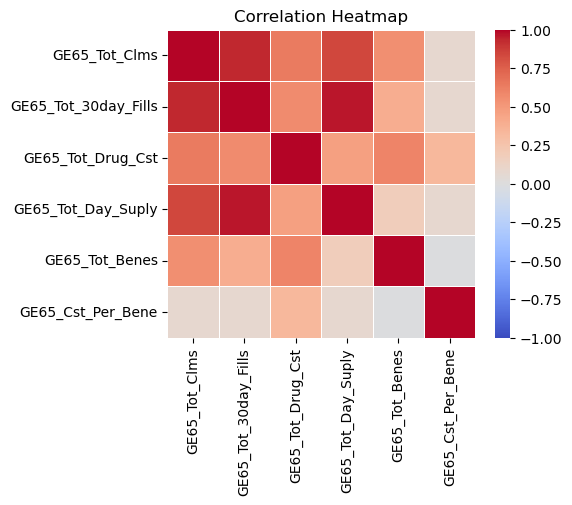

In [84]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    ge65_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [85]:
# Running the Principal Component Reduction.

ge65_pca = PCA(n_components = 6)
ge65_pca_c = ge65_pca.fit_transform(X_ge65)

In [86]:
# Looking at the variability explained by each component in ge65.

ge65_pca.explained_variance_ratio_
ge65_ex_vratio = np.cumsum(ge65_pca.explained_variance_ratio_)
ge65_ex_vratio

array([0.9567422 , 0.99929067, 0.99999055, 0.99999897, 0.99999987,
       1.        ])

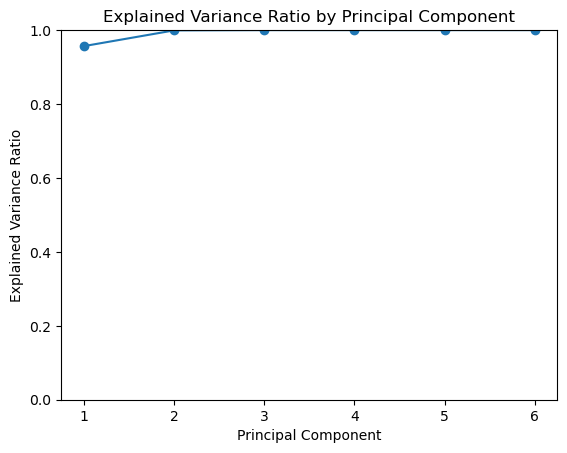

In [87]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(ge65_ex_vratio) + 1)
y = ge65_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [88]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

ge65_comps = ge65_pca.components_

ge65_comps_df = pd.DataFrame(
    ge65_comps,
    columns=X_ge65.columns,
    index=[f'PC{i+1}' for i in range(ge65_comps.shape[0])]
)

print(ge65_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     GE65_Tot_Clms  GE65_Tot_30day_Fills  GE65_Tot_Drug_Cst  \
PC1       0.003210              0.005093           0.993160   
PC2       0.013957              0.031928          -0.116208   
PC3      -0.016632             -0.015795          -0.011057   
PC4       0.742420              0.588538          -0.002579   
PC5      -0.584426              0.338999          -0.000377   
PC6      -0.326768              0.733081           0.000168   

     GE65_Tot_Day_Suply  GE65_Tot_Benes  GE65_Cst_Per_Bene  
PC1            0.116205        0.000943           0.009620  
PC2            0.992521       -0.000932          -0.013492  
PC3            0.013021       -0.013820           0.999495  
PC4           -0.029017        0.317633           0.026396  
PC5           -0.001959        0.737216           0.005847  
PC6           -0.019553       -0.596179          -0.001840  


In [89]:
# From the ratio plot, the top variable explains 99% of the variance in the data.
# From the table above, GE65_Tot_Drug_Cst (PC1 value = 0.99) will be that variable.

In [90]:
# Standardizing numeric data to zscore.

ge65_num = ge65[['GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
ge65_numz = pd.DataFrame(stats.zscore(ge65_num, nan_policy = 'omit'), columns = ge65_num.columns)
ge65_numz.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.213088,1.532623,2.616815,-0.384133,10.377701
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874


In [91]:
# Comparing against mean values and standard deviations in each column in ge65_num.

print(ge65_num.describe())

       GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  Opioid_Cst_Per_Bene_norm  \
count       1.380665e+06           1.380665e+06              1.380665e+06   
mean        1.497340e+05           2.420434e-01              6.482383e-02   
std         5.328972e+05           3.307473e-01              1.942233e-01   
min         0.000000e+00           0.000000e+00              0.000000e+00   
25%         7.960000e+01           0.000000e+00              0.000000e+00   
50%         5.952770e+03           8.695652e-02              0.000000e+00   
75%         9.029066e+04           3.333333e-01              2.701004e-02   
max         1.546347e+08           1.000000e+00              1.535182e+01   

       Opioid_LA_Tot_Benes_norm  Opioid_LA_Cst_Per_Bene_norm  
count              1.380665e+06                 1.380665e+06  
mean               1.727777e-01                 4.425943e-02  
std                3.190786e-01                 3.692166e-01  
min                0.000000e+00                 0.0000

In [92]:
# The ge65-num data frame serves as the final data set because this subset does not include categorical data.

ge65_f = ge65_numz.copy()
ge65_f.head()

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.213088,1.532623,2.616815,-0.384133,10.377701
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874


In [93]:
# Check for null values per column.

print(ge65_f.isnull().sum())

GE65_Tot_Drug_Cst              0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [94]:
# For debugging purposes: create a sample set of ge65 (10% of data) for model optimization purposes.

#ge65_f_10 = ge65_f.sample(frac = 0.1, random_state = 0)
#ge65_f_10.describe()

In [95]:
# Remove opioid data from ge65_f.

ge65_fo = ge65_f[['GE65_Tot_Drug_Cst']]
ge65_fo.head()

,GE65_Tot_Drug_Cst
0,-0.250961
1,-0.213088
2,-0.280205
3,-0.261754
4,-0.280236


In [96]:
# Convert the data frame to a matrix.

ge65_fmat = ge65_fo.to_numpy()

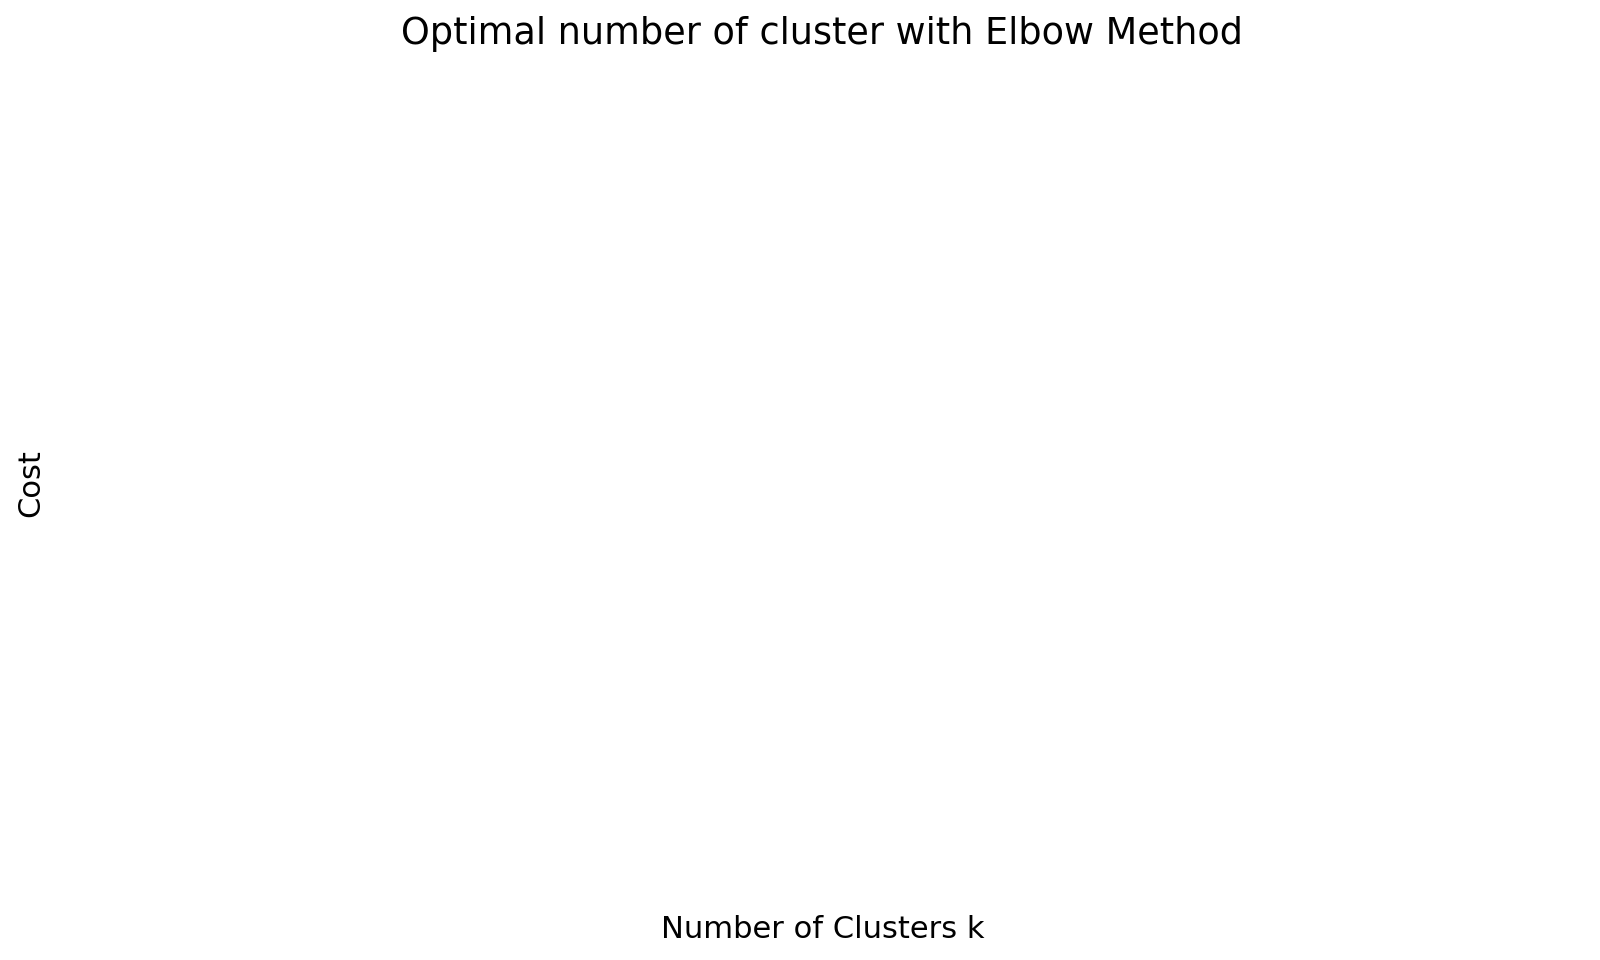

In [97]:
# Use the elbow method to find the optimal number of clusters (k).

cost = []
for cluster in range(1, 10):
    try:
        kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = cluster, init = 'Huang', random_state = 0)
        kprototype_ge65.fit_predict(ge65_fmat)
        cost.append(kprototype_ge65.cost_)
        print('Cluster initiation: {}'.format(cluster))
    except:
        break
        
# Converting the results into a dataframe and plotting them
ge65_f_cost = pd.DataFrame({
    'Cluster': range(1, len(cost) + 1),
    'Cost': cost
})

# Data viz
p9.options.figure_size = (8, 4.8)
(
    ggplot(data = ge65_f_cost)+
    geom_line(aes(x = 'Cluster',
                  y = 'Cost'))+
    geom_point(aes(x = 'Cluster',
                   y = 'Cost'))+
    geom_label(aes(x = 'Cluster',
                   y = 'Cost',
                   label = 'Cluster'),
               size = 10,
               nudge_y = 1000) +
    labs(title = 'Optimal number of cluster with Elbow Method')+
    xlab('Number of Clusters k')+
    ylab('Cost')+
    theme_minimal()
)

In [100]:
# Without a graph above, I turned to ChatGPT to help me graph it differently.

costs = []

K = range(1, 10)

for k in K:
    kprototype_ge65 = KPrototypes(n_clusters=k, init='Cao', random_state=42)
    clusters = kprototype_ge65.fit_predict(ge65_fmat)
    costs.append(kprototype_ge65.cost_)

# Plot
plt.plot(K, costs, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Cost')
plt.title('Elbow Method')
plt.show()

except Exception as e:
    print(type(e).__name__)

SyntaxError: invalid syntax (2809868408.py, line 19)

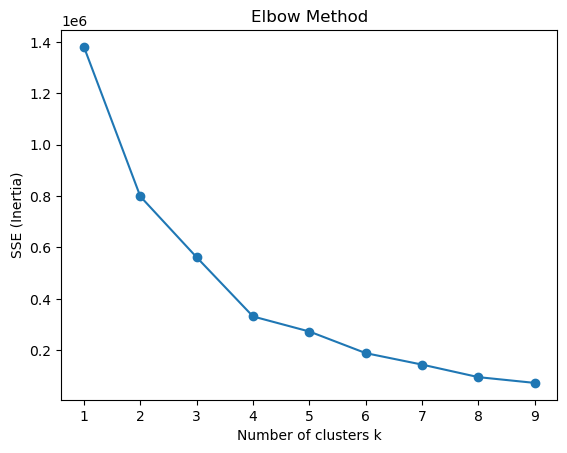

In [101]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_ge65 = KMeans(n_clusters=k, random_state=42).fit(ge65_fmat)
    
    distortions.append(sum(np.min(cdist(ge65_fmat, kmeans_ge65.cluster_centers_, 'euclidean'), axis=1)**2) / ge65_fmat.shape[0])
    
    inertias.append(kmeans_ge65.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [102]:
#Run Kprototypes using 3 clusters as determined from the elbow plot above.

kprototype_ge65 = KPrototypes(n_jobs = -1, n_clusters = 3, init = 'Huang', random_state = 0)
kprototype_ge65.fit_predict(ge65_fmat)

except Exception as e: print(type(e).__name__)

SyntaxError: invalid syntax (3902597966.py, line 6)

In [104]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_ge65 = KMeans(n_clusters=3, random_state=42).fit(ge65_fmat)

In [105]:
# Cluster centorid

kmeans_ge65.cluster_centers_

array([[-0.16573901],
       [ 9.44176416],
       [ 1.88488503]])

In [106]:
# Check the iteration of the clusters created

kmeans_ge65.n_iter_

16

In [107]:
# Check the cost of the clusters created

kmeans_ge65.inertia_

561574.7838601253

In [108]:
# Add the clusters to the ge65_f dataframe.

ge65_f3 = ge65_f.copy()

ge65_f3['Cluster Labels'] = kmeans_ge65.labels_
ge65_f3['Segment'] = ge65_f3['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
ge65_f3['Segment'] = ge65_f3['Segment'].astype('category')
ge65_f3['Segment'] = ge65_f3['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

ge65_f3.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.213088,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.490819,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,0.123987,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.277237,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.280981,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,-0.263334,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [109]:
# Cluster interpretation

ge65_f3.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
ge65_f3.groupby('Segment').agg(
    {
        'Total': 'count',
        'GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\593702831.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1288678,-0.165802,0.036771,0.011816,0.033995,-0.006234
1,Cluster 2,5353,9.433300,-0.468476,-0.273659,-0.449244,-0.054509
2,Cluster 3,86634,1.883427,-0.518014,-0.158852,-0.477916,0.096105


In [110]:
# Note: Based on the elbow method, 3 clusters were originally selected for this model.
# However, after looking at the cluster sizes in the summary table, there was a third cluster that had only 1 value in it. Therefore, with concerns of overfitting, the model was adjusted for 2 clusters, shown above.

In [111]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_ge652 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [112]:
# Cluster centorid

kmeans_ge652.cluster_centers_

array([[-0.09861581],
       [ 4.27487135]])

In [113]:
# Check the iteration of the clusters created

kmeans_ge652.n_iter_

21

In [114]:
# Check the cost of the clusters created

kmeans_ge652.inertia_

798615.7580878136

In [115]:
# Add the clusters to the ge65_f dataframe.

ge65_f2 = ge65_f.copy()

ge65_f2['Cluster Labels'] = kmeans_ge652.labels_
ge65_f2['Segment'] = ge65_f2['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
ge65_f2['Segment'] = ge65_f2['Segment'].astype('category')
ge65_f2['Segment'] = ge65_f2['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

ge65_f2.head(10)

,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.250961,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.213088,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.280205,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.261754,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.280236,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.490819,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,0.123987,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.277237,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.280981,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,-0.263334,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [116]:
# Cluster interpretation

ge65_f2.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
ge65_f2.groupby('Segment').agg(
    {
        'Total': 'count',
        'GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\592562684.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1349415,-0.098807,0.011688,0.005541,0.010763,-0.000321
1,Cluster 2,31250,4.266623,-0.504690,-0.239284,-0.464748,0.013873


### Generic vs. Brand Name and Insurance Plans

In [117]:
# Creating subset of the data: generic/brand name drugs + insurance plan + opioid data.

gbip = opioid_norm[['Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Clms', 'PDP_Tot_Drug_Cst', 'LIS_Tot_Clms', 'LIS_Drug_Cst', 'NonLIS_Tot_Clms', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip.head()

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,10.0,0.00,189.0,3170.22,91.0,9238.20,131.0,9161.78,66.0,7243.45,156.0,11156.53,0.116071,0.020452,0.000000,0.000000
1,55.0,19957.16,1810.0,42666.24,1314.0,44891.82,551.0,17731.58,1398.0,50702.42,467.0,11920.98,0.748954,0.573070,0.050209,3.875878
2,10.0,0.00,108.0,383.19,46.0,156.89,72.0,299.78,13.0,31.52,105.0,425.15,0.169492,0.000000,0.169492,0.000000
3,17.0,10459.97,145.0,8669.06,72.0,12396.49,90.0,6732.54,31.0,8946.64,131.0,10182.39,0.000000,0.000000,0.000000,0.000000
4,0.0,0.00,41.0,1275.79,24.0,560.95,17.0,714.84,24.0,1212.00,17.0,63.79,0.576923,0.047960,0.000000,0.000000


In [118]:
# Checking data types in gbip.

print(gbip.dtypes)

Brnd_Tot_Clms                  float64
Brnd_Tot_Drug_Cst              float64
Gnrc_Tot_Clms                  float64
Gnrc_Tot_Drug_Cst              float64
MAPD_Tot_Clms                  float64
MAPD_Tot_Drug_Cst              float64
PDP_Tot_Clms                   float64
PDP_Tot_Drug_Cst               float64
LIS_Tot_Clms                   float64
LIS_Drug_Cst                   float64
NonLIS_Tot_Clms                float64
NonLIS_Drug_Cst                float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [119]:
# Check for null values per column.

print(gbip.isnull().sum())

Brnd_Tot_Clms                  0
Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Clms                  0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Clms                  0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Clms                   0
PDP_Tot_Drug_Cst               0
LIS_Tot_Clms                   0
LIS_Drug_Cst                   0
NonLIS_Tot_Clms                0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [120]:
# Preparing for a Principal Component Reduction.

X_gbip = gbip.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
gbip_corr = X_gbip.corr()

gbip_corr

,Brnd_Tot_Clms,Brnd_Tot_Drug_Cst,Gnrc_Tot_Clms,Gnrc_Tot_Drug_Cst,MAPD_Tot_Clms,MAPD_Tot_Drug_Cst,PDP_Tot_Clms,PDP_Tot_Drug_Cst,LIS_Tot_Clms,LIS_Drug_Cst,NonLIS_Tot_Clms,NonLIS_Drug_Cst
Brnd_Tot_Clms,1.000000,0.702425,0.280734,0.217756,0.559338,0.543712,0.593717,0.556991,0.367279,0.321502,0.678440,0.667290
Brnd_Tot_Drug_Cst,0.702425,1.000000,0.385660,0.434066,0.543030,0.804416,0.542158,0.775524,0.405515,0.683417,0.587352,0.791428
Gnrc_Tot_Clms,0.280734,0.385660,1.000000,0.713931,0.856447,0.428656,0.790792,0.355052,0.825684,0.474232,0.713802,0.287978
Gnrc_Tot_Drug_Cst,0.217756,0.434066,0.713931,1.000000,0.590100,0.538677,0.613905,0.554896,0.639753,0.627847,0.479975,0.429326
MAPD_Tot_Clms,0.559338,0.543030,0.856447,0.590100,1.000000,0.609995,0.631443,0.374704,0.730895,0.481842,0.800101,0.453032
MAPD_Tot_Drug_Cst,0.543712,0.804416,0.428656,0.538677,0.609995,1.000000,0.420138,0.664713,0.416562,0.794233,0.541857,0.779784
PDP_Tot_Clms,0.593717,0.542158,0.790792,0.613905,0.631443,0.420138,1.000000,0.595414,0.744144,0.462484,0.726699,0.476857
PDP_Tot_Drug_Cst,0.556991,0.775524,0.355052,0.554896,0.374704,0.664713,0.595414,1.000000,0.369561,0.687052,0.497419,0.834867
LIS_Tot_Clms,0.367279,0.405515,0.825684,0.639753,0.730895,0.416562,0.744144,0.369561,1.000000,0.590569,0.395814,0.197310
LIS_Drug_Cst,0.321502,0.683417,0.474232,0.627847,0.481842,0.794233,0.462484,0.687052,0.590569,1.000000,0.299842,0.463277


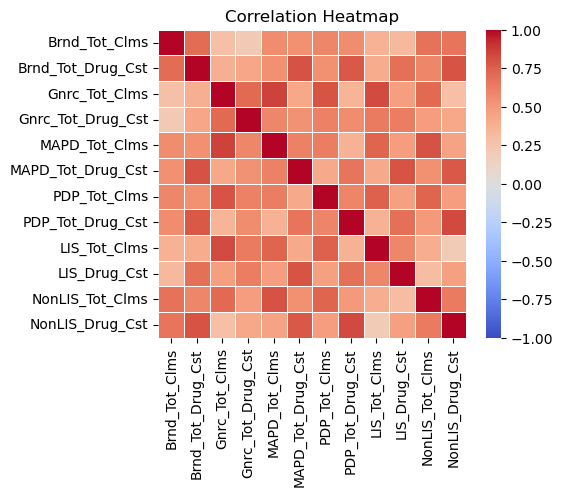

In [121]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    gbip_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [122]:
# Running the Principal Component Reduction.

gbip_pca = PCA(n_components = 6)
gbip_pca_c = gbip_pca.fit_transform(X_gbip)

In [123]:
# Looking at the variability explained by each component in gbip.

gbip_pca.explained_variance_ratio_
gbip_ex_vratio = np.cumsum(gbip_pca.explained_variance_ratio_)
gbip_ex_vratio

array([0.80202161, 0.89434435, 0.94856242, 0.99442929, 0.99864745,
       0.99998915])

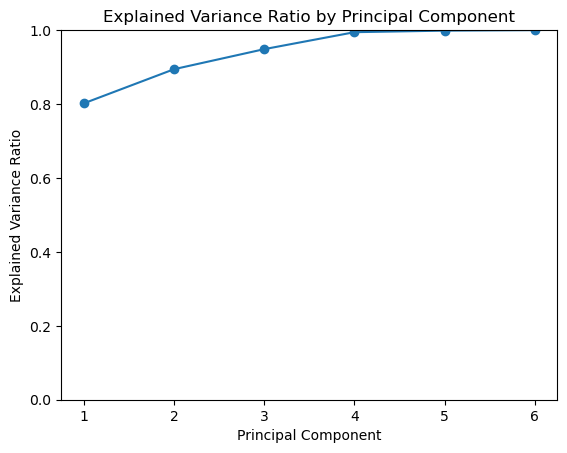

In [124]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(gbip_ex_vratio) + 1)
y = gbip_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [125]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

gbip_comps = gbip_pca.components_

gbip_comps_df = pd.DataFrame(
    gbip_comps,
    columns=X_gbip.columns,
    index=[f'PC{i+1}' for i in range(gbip_comps.shape[0])]
)

print(gbip_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Brnd_Tot_Clms  Brnd_Tot_Drug_Cst  Gnrc_Tot_Clms  Gnrc_Tot_Drug_Cst  \
PC1       0.001024           0.621280       0.001246           0.053856   
PC2      -0.001126           0.007344       0.002104           0.072159   
PC3       0.001274           0.769589      -0.000777          -0.119451   
PC4       0.000203          -0.137481      -0.000204          -0.042437   
PC5      -0.000478           0.052505       0.022301           0.985429   
PC6      -0.001581          -0.004449      -0.003458          -0.061388   

     MAPD_Tot_Clms  MAPD_Tot_Drug_Cst  PDP_Tot_Clms  PDP_Tot_Drug_Cst  \
PC1       0.001270           0.411228      0.001046          0.360817   
PC2       0.001020           0.269229      0.000028         -0.154210   
PC3       0.000444          -0.211341     -0.000202         -0.401720   
PC4       0.002052           0.679270     -0.002004         -0.654789   
PC5       0.012021          -0.069630      0.009429         -0.115999   
PC6      -0.004004          -0.49746

In [126]:
# From the ratio plot, the top variable explains 80% of the variance in the data.
# From the table above, Brnd_Tot_Drug_Cst (PC1 value = 0.62) would be that variable.
# However, given that this analysis chunk is made up of essentially 6 variables (brand name drugs, generic-brand drugs, MAPD plan, PDP plan, low-income status, and no low-income status) from 2 different groups (drug brand, insurance plan), I do not feel comfortable clustering only on one variable.
# Therefore, I will move forward with the Cst-related columns of each variable.

In [127]:
# Standardizing numeric data to zscore.

gbip_num = gbip[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
gbip_numz = pd.DataFrame(stats.zscore(gbip_num, nan_policy = 'omit'), columns = gbip_num.columns)
gbip_numz.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874


In [128]:
# Comparing against mean values and standard deviations in each column in gbip_num.

print(gbip_num.describe())

       Brnd_Tot_Drug_Cst  Gnrc_Tot_Drug_Cst  MAPD_Tot_Drug_Cst  \
count       1.380665e+06       1.380665e+06       1.380665e+06   
mean        1.343237e+05       2.857522e+04       1.092079e+05   
std         5.309747e+05       7.993814e+04       3.699074e+05   
min         0.000000e+00       0.000000e+00       0.000000e+00   
25%         0.000000e+00       6.326200e+02       2.722100e+02   
50%         0.000000e+00       3.320050e+03       5.207970e+03   
75%         5.681983e+04       2.341040e+04       6.510144e+04   
max         1.601750e+08       1.832377e+07       7.876053e+07   

       PDP_Tot_Drug_Cst  LIS_Drug_Cst  NonLIS_Drug_Cst  Opioid_Tot_Benes_norm  \
count      1.380665e+06  1.380665e+06     1.380665e+06           1.380665e+06   
mean       8.798766e+04  9.437112e+04     1.032235e+05           2.420434e-01   
std        3.338271e+05  3.297399e+05     4.214994e+05           3.307473e-01   
min        0.000000e+00  0.000000e+00     0.000000e+00           0.000000e+00   


In [129]:
# The gbip-num data frame serves as the final data set because this subset does not include categorical data.

gbip_f = gbip_numz.copy()
gbip_f.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874


In [130]:
# Check for null values per column.

print(gbip_f.isnull().sum())

Brnd_Tot_Drug_Cst              0
Gnrc_Tot_Drug_Cst              0
MAPD_Tot_Drug_Cst              0
PDP_Tot_Drug_Cst               0
LIS_Drug_Cst                   0
NonLIS_Drug_Cst                0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [131]:
# For debugging purposes: create a sample set of gbip (10% of data) for model optimization purposes.

#gbip_f10 = gbip_f.sample(frac = 0.1, random_state = 0)
#gbip_f10.describe()

In [132]:
# Remove opioid data from gbif_f.

gbip_fo = gbip_f[['Brnd_Tot_Drug_Cst', 'Gnrc_Tot_Drug_Cst', 'MAPD_Tot_Drug_Cst', 'PDP_Tot_Drug_Cst', 'LIS_Drug_Cst', 'NonLIS_Drug_Cst']]
gbip_fo.head()

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745


In [133]:
# Convert the data frame to a matrix.

gbip_fmat = gbip_fo.to_numpy()

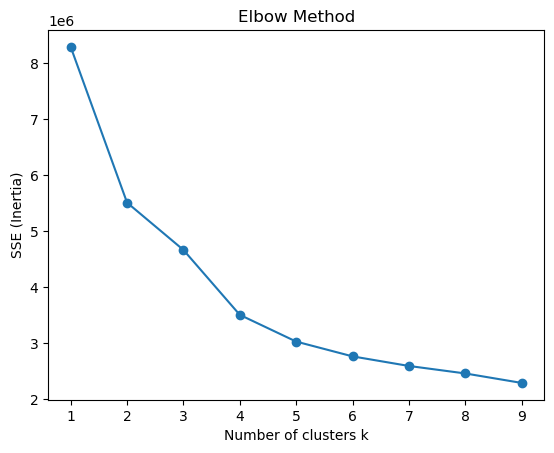

In [134]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_gbip = KMeans(n_clusters=k, random_state=42).fit(gbip_fmat)
    
    distortions.append(sum(np.min(cdist(gbip_fmat, kmeans_gbip.cluster_centers_, 'euclidean'), axis=1)**2) / gbip_fmat.shape[0])
    
    inertias.append(kmeans_gbip.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [135]:
#Run k-means using 3 clusters as determined from the elbow plot above.

kmeans_gbip = KMeans(n_clusters=3, random_state=42).fit(gbip_fmat)

In [136]:
# Cluster centorid

kmeans_gbip.cluster_centers_

array([[-0.11632197, -0.11723285, -0.13226407, -0.12209443, -0.13350262,
        -0.1094403 ],
       [ 2.50578786,  2.5992672 ,  2.8842995 ,  2.64702782,  2.9293447 ,
         2.36094125],
       [40.6927359 , 13.52993779, 33.21332951, 36.42733152, 26.81332026,
        37.02131893]])

In [137]:
# Check the iteration of the clusters created

kmeans_gbip.n_iter_

16

In [138]:
# Check the cost of the clusters created

kmeans_gbip.inertia_

4661543.802149098

In [139]:
# Add the clusters to the gbip_f dataframe.

gbip_f3 = gbip_f.copy()

gbip_f3['Cluster Labels'] = kmeans_gbip.labels_
gbip_f3['Segment'] = gbip_f3['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
gbip_f3['Segment'] = gbip_f3['Segment'].astype('category')
gbip_f3['Segment'] = gbip_f3['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2', 'Cluster 3'])

gbip_f3.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.367983,1.200780,0.298577,0.445284,-0.030182,0.637361,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,-0.252976,0.037675,0.157229,0.072223,0.081752,0.130282,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.252976,-0.348273,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.252976,-0.356714,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,-0.252976,-0.289817,-0.283913,-0.244737,-0.265335,-0.236367,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [140]:
# Cluster interpretation

gbip_f3.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
gbip_f3.groupby('Segment').agg(
    {
        'Total': 'count',
        'Brnd_Tot_Drug_Cst': 'mean',
        'Gnrc_Tot_Drug_Cst': 'mean',
        'MAPD_Tot_Drug_Cst': 'mean',
        'PDP_Tot_Drug_Cst': 'mean',
        'LIS_Drug_Cst': 'mean',
        'NonLIS_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\2837109446.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1321847,-0.116199,-0.117065,-0.132117,-0.121970,-0.133367,-0.109317,0.021420,0.007395,0.020696,-0.004748
1,Cluster 2,58660,2.508821,2.601511,2.887678,2.650363,2.933080,2.363632,-0.481051,-0.166064,-0.464994,0.107152
2,Cluster 3,158,40.692736,13.529938,33.213330,36.427332,26.813320,37.021319,-0.605826,-0.212212,-0.505163,-0.061664


In [141]:
#Run k-means using 2 clusters as determined from the elbow plot above.

kmeans_gbip2 = KMeans(n_clusters=2, random_state=42).fit(ge65_fmat)

In [142]:
# Cluster centorid

kmeans_gbip2.cluster_centers_

array([[-0.09861581],
       [ 4.27487135]])

In [143]:
# Check the iteration of the clusters created

kmeans_gbip2.n_iter_

21

In [144]:
# Check the cost of the clusters created

kmeans_gbip2.inertia_

798615.7580878136

In [145]:
# Add the clusters to the gbip_f dataframe.

gbip_f2 = gbip_f.copy()

gbip_f2['Cluster Labels'] = kmeans_gbip2.labels_
gbip_f2['Segment'] = gbip_f2['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
gbip_f2['Segment'] = gbip_f2['Segment'].astype('category')
gbip_f2['Segment'] = gbip_f2['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

gbip_f2.head(10)

,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.252976,-0.317808,-0.270256,-0.236128,-0.264232,-0.218427,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.215390,0.176274,-0.173871,-0.210457,-0.132434,-0.216614,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.252976,-0.352673,-0.294806,-0.262675,-0.286103,-0.243887,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.233276,-0.249020,-0.261718,-0.243405,-0.259066,-0.220739,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.252976,-0.341507,-0.293714,-0.261431,-0.282523,-0.244745,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.367983,1.200780,0.298577,0.445284,-0.030182,0.637361,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,-0.252976,0.037675,0.157229,0.072223,0.081752,0.130282,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.252976,-0.348273,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.252976,-0.356714,-0.295230,-0.263573,-0.286199,-0.244896,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,-0.252976,-0.289817,-0.283913,-0.244737,-0.265335,-0.236367,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [146]:
# Cluster interpretation

gbip_f2.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
gbip_f2.groupby('Segment').agg(
    {
        'Total': 'count',
        'Brnd_Tot_Drug_Cst': 'mean',
        'Gnrc_Tot_Drug_Cst': 'mean',
        'MAPD_Tot_Drug_Cst': 'mean',
        'PDP_Tot_Drug_Cst': 'mean',
        'LIS_Drug_Cst': 'mean',
        'NonLIS_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\401330434.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Brnd_Tot_Drug_Cst,Gnrc_Tot_Drug_Cst,MAPD_Tot_Drug_Cst,PDP_Tot_Drug_Cst,LIS_Drug_Cst,NonLIS_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1349415,-0.078242,-0.069384,-0.090437,-0.089821,-0.084250,-0.085904,0.011688,0.005541,0.010763,-0.000321
1,Cluster 2,31250,3.378568,2.996107,3.905185,3.878575,3.638017,3.709463,-0.504690,-0.239284,-0.464748,0.013873


### Additional Medications Prescribed

In [147]:
# Creating subset of the data: additional medications prescribed + opioid data.

meds = opioid_norm[['Antbtc_Tot_Clms', 'Antbtc_Tot_Drug_Cst', 'Antbtc_Tot_Benes', 'Antbtc_Cst_Per_Bene', 'Antpsyct_GE65_Tot_Clms', 'Antpsyct_GE65_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Benes', 'Antpsyct_GE65_Cst_Per_Bene', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds.head()

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,42.0,731.76,39.0,18.763077,10.0,0.0,10.0,0.0,0.116071,0.020452,0.000000,0.000000
1,10.0,0.00,10.0,0.000000,0.0,0.0,0.0,0.0,0.748954,0.573070,0.050209,3.875878
2,60.0,266.45,49.0,5.437755,0.0,0.0,10.0,0.0,0.169492,0.000000,0.169492,0.000000
3,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.000000,0.000000,0.000000,0.000000
4,10.0,0.00,10.0,0.000000,0.0,0.0,10.0,0.0,0.576923,0.047960,0.000000,0.000000


In [148]:
# Checking data types in meds.

print(meds.dtypes)

Antbtc_Tot_Clms                float64
Antbtc_Tot_Drug_Cst            float64
Antbtc_Tot_Benes               float64
Antbtc_Cst_Per_Bene            float64
Antpsyct_GE65_Tot_Clms         float64
Antpsyct_GE65_Tot_Drug_Cst     float64
Antpsyct_GE65_Tot_Benes        float64
Antpsyct_GE65_Cst_Per_Bene     float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [149]:
# Check for null values per column.

print(meds.isnull().sum())

Antbtc_Tot_Clms                0
Antbtc_Tot_Drug_Cst            0
Antbtc_Tot_Benes               0
Antbtc_Cst_Per_Bene            0
Antpsyct_GE65_Tot_Clms         0
Antpsyct_GE65_Tot_Drug_Cst     0
Antpsyct_GE65_Tot_Benes        0
Antpsyct_GE65_Cst_Per_Bene     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [150]:
# Preparing for a Principal Component Reduction.

X_meds = meds.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
meds_corr = X_meds.corr()

meds_corr

,Antbtc_Tot_Clms,Antbtc_Tot_Drug_Cst,Antbtc_Tot_Benes,Antbtc_Cst_Per_Bene,Antpsyct_GE65_Tot_Clms,Antpsyct_GE65_Tot_Drug_Cst,Antpsyct_GE65_Tot_Benes,Antpsyct_GE65_Cst_Per_Bene
Antbtc_Tot_Clms,1.000000,0.267580,0.932777,0.055278,0.227800,0.074556,0.134117,0.036387
Antbtc_Tot_Drug_Cst,0.267580,1.000000,0.146993,0.631144,0.094352,0.039422,0.050234,0.015170
Antbtc_Tot_Benes,0.932777,0.146993,1.000000,0.004764,0.132801,0.032296,0.049299,0.010639
Antbtc_Cst_Per_Bene,0.055278,0.631144,0.004764,1.000000,0.003703,0.000034,-0.031479,-0.002818
Antpsyct_GE65_Tot_Clms,0.227800,0.094352,0.132801,0.003703,1.000000,0.568195,0.785182,0.288654
Antpsyct_GE65_Tot_Drug_Cst,0.074556,0.039422,0.032296,0.000034,0.568195,1.000000,0.454553,0.683327
Antpsyct_GE65_Tot_Benes,0.134117,0.050234,0.049299,-0.031479,0.785182,0.454553,1.000000,0.197069
Antpsyct_GE65_Cst_Per_Bene,0.036387,0.015170,0.010639,-0.002818,0.288654,0.683327,0.197069,1.000000


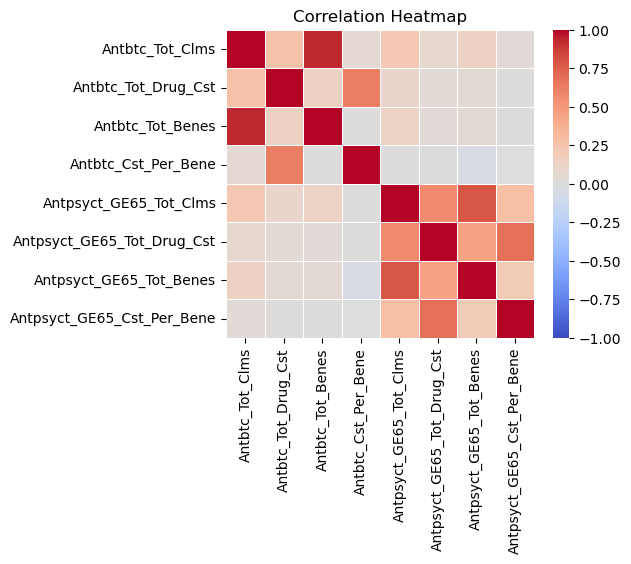

In [151]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    meds_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()


In [152]:
# Running the Principal Component Reduction.

meds_pca = PCA(n_components = 6)
meds_pca_c = meds_pca.fit_transform(X_meds)

In [153]:
# Looking at the variability explained by each component in meds.

meds_pca.explained_variance_ratio_
meds_ex_vratio = np.cumsum(meds_pca.explained_variance_ratio_)
meds_ex_vratio

array([0.53326324, 0.99939351, 0.99975464, 0.99997646, 0.99999493,
       0.99999951])

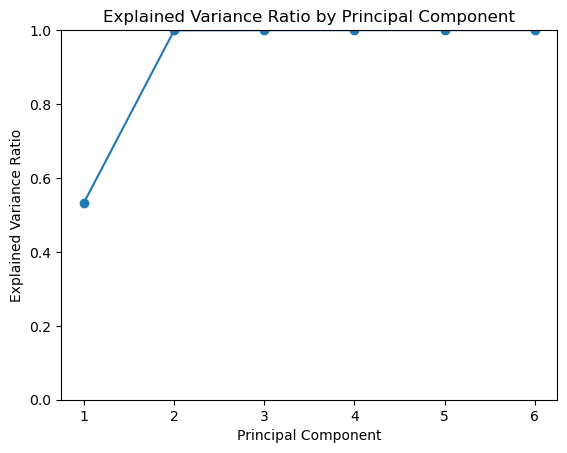

In [154]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(meds_ex_vratio) + 1)
y = meds_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [155]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

meds_comps = meds_pca.components_

meds_comps_df = pd.DataFrame(
    meds_comps,
    columns=X_meds.columns,
    index=[f'PC{i+1}' for i in range(meds_comps.shape[0])]
)

print(meds_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Antbtc_Tot_Clms  Antbtc_Tot_Drug_Cst  Antbtc_Tot_Benes  \
PC1         0.000786             0.307739          0.000232   
PC2         0.001317             0.951305          0.000441   
PC3        -0.003888             0.000158         -0.001954   
PC4        -0.040815            -0.017575         -0.019386   
PC5         0.851617            -0.002367          0.507316   
PC6        -0.065512            -0.000195         -0.131106   

     Antbtc_Cst_Per_Bene  Antpsyct_GE65_Tot_Clms  Antpsyct_GE65_Tot_Drug_Cst  \
PC1             0.004810                0.002082                    0.951173   
PC2             0.017007               -0.000377                   -0.307674   
PC3             0.017091               -0.019605                   -0.024477   
PC4             0.998622               -0.009781                    0.001123   
PC5             0.045938                0.123063                   -0.000711   
PC6             0.004913                0.983154                   -0.002516  

In [156]:
# From the ratio plot, the top 2 variables explain >99% of the variance in the data.
# From the table above, Antpsyct_GE65_Tot_Drug_Cst (PC1 value = 0.98, 56% of variance) and Antbtc_Tot_Drug_Cst (PC2 value = 0.98, >99% of variance) would be those variables.
# With such high variance (>99%) explained by two variables, overfitting is a concern, but including both variables seems necessary.
# Each variable represents a different medication: antibiotics and antipsychotics.

In [193]:
# Standardizing numeric data to zscore.

meds_num = meds[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
meds_numz = pd.DataFrame(stats.zscore(meds_num, nan_policy = 'omit'), columns = meds_num.columns)
meds_numz.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.074067,-0.09754,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.118762,-0.09754,1.532623,2.616815,-0.384133,10.377701
2,-0.102488,-0.09754,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.118762,-0.09754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.118762,-0.09754,1.012495,-0.086828,-0.541490,-0.119874


In [194]:
# Comparing against mean values and standard deviations in each column in meds_num.

print(meds_num.describe())

       Antbtc_Tot_Drug_Cst  Antpsyct_GE65_Tot_Drug_Cst  Opioid_Tot_Benes_norm  \
count         1.380665e+06                1.380665e+06           1.380665e+06   
mean          1.944425e+03                1.686178e+03           2.420434e-01   
std           1.637246e+04                1.728702e+04           3.307473e-01   
min           0.000000e+00                0.000000e+00           0.000000e+00   
25%           0.000000e+00                0.000000e+00           0.000000e+00   
50%           1.086000e+02                0.000000e+00           8.695652e-02   
75%           6.854500e+02                0.000000e+00           3.333333e-01   
max           8.775029e+06                6.524661e+06           1.000000e+00   

       Opioid_Cst_Per_Bene_norm  Opioid_LA_Tot_Benes_norm  \
count              1.380665e+06              1.380665e+06   
mean               6.482383e-02              1.727777e-01   
std                1.942233e-01              3.190786e-01   
min                0.00000

In [195]:
# The meds-num data frame serves as the final data set because this subset does not include categorical data.

meds_f = meds_numz.copy()
meds_f.head()

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.074067,-0.09754,-0.380871,-0.228457,-0.541490,-0.119874
1,-0.118762,-0.09754,1.532623,2.616815,-0.384133,10.377701
2,-0.102488,-0.09754,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.118762,-0.09754,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.118762,-0.09754,1.012495,-0.086828,-0.541490,-0.119874


In [196]:
# Check for null values per column.

print(meds_f.isnull().sum())

Antbtc_Tot_Drug_Cst            0
Antpsyct_GE65_Tot_Drug_Cst     0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [197]:
# Create a sample set of meds (10% of data) for model optimization purposes.

#meds_f_10 = meds_f.sample(frac = 0.1, random_state = 0)
#meds_f_10.describe()

In [198]:
# Remove opioid data from meds_f.

#meds_f = meds_f[['Antbtc_Tot_Drug_Cst', 'Antpsyct_GE65_Tot_Drug_Cst']]
#meds_f.head()


In [199]:
# Convert the data frame to a matrix.

meds_fmat = meds_f.to_numpy()

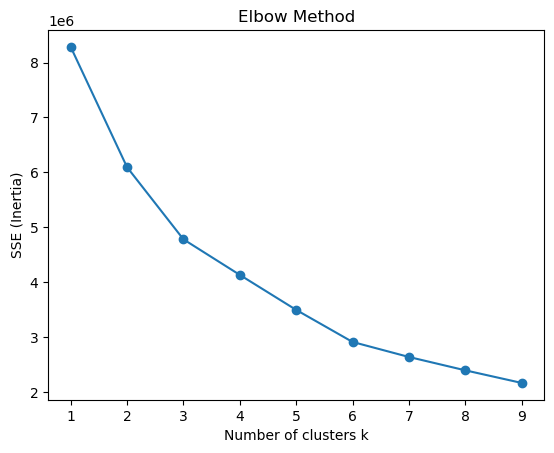

In [200]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []

K = range(1, 10)

for k in K:
    kmeans_meds = KMeans(n_clusters=k, random_state=42).fit(meds_fmat)
    
    distortions.append(sum(np.min(cdist(meds_fmat, kmeans_meds.cluster_centers_, 'euclidean'), axis=1)**2) / meds_fmat.shape[0])
    
    inertias.append(kmeans_meds.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [201]:
#Run k-means using k clusters as determined from the elbow plot above.

kmeans_meds = KMeans(n_clusters=2, random_state=42).fit(meds_fmat)

In [202]:
# Cluster centorid

kmeans_meds.cluster_centers_

array([[ 0.01843891,  0.01531003, -0.33064363,  0.0440222 , -0.37603335,
         0.01678571],
       [-0.11540239, -0.09581986,  2.06937786, -0.27551887,  2.35345559,
        -0.10505564]])

In [203]:
# Check the iteration of the clusters created

kmeans_meds.n_iter_

3

In [204]:
# Check the cost of the clusters created

kmeans_meds.inertia_

6093300.171206679

In [205]:
# Add the clusters to the meds_f dataframe.

meds_f3 = meds_f.copy()

meds_f3['Cluster Labels'] = kmeans_meds.labels_
meds_f3['Segment'] = meds_f3['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'})

# Order the cluster
meds_f3['Segment'] = meds_f3['Segment'].astype('category')
meds_f3['Segment'] = meds_f3['Segment'].cat.set_categories(
    ['Cluster 1', 'Cluster 2', 'Cluster 3'],
    ordered=True
)

meds_f3.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.074067,-0.097540,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.118762,-0.097540,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.102488,-0.097540,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.118762,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.118762,-0.097540,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,-0.048351,0.026246,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,0.110416,-0.097540,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,1,Cluster 2
8,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,1,Cluster 2
9,0.013574,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [206]:
# Cluster interpretation

meds_f3.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
meds_f3.groupby('Segment').agg(
    {
        'Total': 'count',
        'Antbtc_Tot_Drug_Cst': 'mean',
        'Antpsyct_GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\1057060988.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1190438,0.018441,0.015312,-0.33067,0.043977,-0.376051,0.016758
1,Cluster 2,190227,-0.115402,-0.095820,2.06933,-0.275206,2.353324,-0.104873
2,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN


In [207]:
# Add the clusters to the meds_f dataframe.

meds_f2 = meds_f.copy()

meds_f2['Cluster Labels'] = kmeans_meds.labels_
meds_f2['Segment'] = meds_f2['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
meds_f2['Segment'] = meds_f2['Segment'].astype('category')
meds_f2['Segment'] = meds_f2['Segment'].cat.reorder_categories(['Cluster 1', 'Cluster 2'])

meds_f2.head(10)

,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.074067,-0.097540,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,-0.118762,-0.097540,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.102488,-0.097540,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.118762,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.118762,-0.097540,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,-0.048351,0.026246,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,0.110416,-0.097540,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,1,Cluster 2
8,-0.118762,-0.097540,2.291650,-0.333759,2.592535,-0.119874,1,Cluster 2
9,0.013574,-0.097540,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [208]:
# Cluster interpretation

meds_f2.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
meds_f2.groupby('Segment').agg(
    {
        'Total': 'count',
        'Antbtc_Tot_Drug_Cst': 'mean',
        'Antpsyct_GE65_Tot_Drug_Cst': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\2110083950.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Antbtc_Tot_Drug_Cst,Antpsyct_GE65_Tot_Drug_Cst,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1190438,0.018441,0.015312,-0.33067,0.043977,-0.376051,0.016758
1,Cluster 2,190227,-0.115402,-0.095820,2.06933,-0.275206,2.353324,-0.104873


### Beneficiary Demographics

In [209]:
# Creating subset of the data: patient demographics + opioid data.

bene = opioid_norm[['Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene.head()

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,76,16.0,66.0,30.0,64.0,48.0,73.0,17.0,11.0,10.0,0.0,10.0,0.116071,0.020452,0.000000,0.000000
1,67,188.0,270.0,20.0,311.0,167.0,226.0,212.0,10.0,26.0,10.0,13.0,0.748954,0.573070,0.050209,3.875878
2,72,10.0,0.0,10.0,31.0,28.0,54.0,0.0,0.0,0.0,10.0,10.0,0.169492,0.000000,0.169492,0.000000
3,70,10.0,0.0,10.0,10.0,10.0,59.0,10.0,10.0,10.0,0.0,10.0,0.000000,0.000000,0.000000,0.000000
4,64,10.0,0.0,10.0,15.0,11.0,19.0,10.0,0.0,10.0,0.0,10.0,0.576923,0.047960,0.000000,0.000000


In [210]:
# Checking data types in bene.

print(bene.dtypes)

Bene_Avg_Age                     int64
Bene_Age_LT_65_Cnt             float64
Bene_Age_65_84_Cnt             float64
Bene_Age_GT_84_Cnt             float64
Bene_Feml_Cnt                  float64
Bene_Male_Cnt                  float64
Bene_Race_Wht_Cnt              float64
Bene_Race_Black_Cnt            float64
Bene_Race_Api_Cnt              float64
Bene_Race_Hspnc_Cnt            float64
Bene_Race_Natind_Cnt           float64
Bene_Race_Othr_Cnt             float64
Opioid_Tot_Benes_norm          float64
Opioid_Cst_Per_Bene_norm       float64
Opioid_LA_Tot_Benes_norm       float64
Opioid_LA_Cst_Per_Bene_norm    float64
dtype: object


In [211]:
# Check for null values per column.

print(bene.isnull().sum())

Bene_Avg_Age                   0
Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [212]:
# Preparing for a Principal Component Reduction.

X_bene = bene.drop(columns = ['Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm'])
bene_corr = X_bene.corr()

bene_corr

,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
Bene_Avg_Age,1.000000,-0.086439,0.037932,0.080242,0.045634,0.048129,0.051671,0.001200,0.026596,0.025332,-0.039826,0.022471
Bene_Age_LT_65_Cnt,-0.086439,1.000000,0.818816,0.773674,0.835207,0.823159,0.810082,0.768164,0.463198,0.598809,0.165048,0.726082
Bene_Age_65_84_Cnt,0.037932,0.818816,1.000000,0.968220,0.995754,0.994610,0.980490,0.766810,0.650958,0.699015,0.138088,0.951100
Bene_Age_GT_84_Cnt,0.080242,0.773674,0.968220,1.000000,0.966294,0.969506,0.952391,0.714059,0.655723,0.687196,0.141846,0.929848
Bene_Feml_Cnt,0.045634,0.835207,0.995754,0.966294,1.000000,0.990483,0.981191,0.776616,0.645074,0.696564,0.138396,0.945802
Bene_Male_Cnt,0.048129,0.823159,0.994610,0.969506,0.990483,1.000000,0.978822,0.759297,0.657142,0.702609,0.138991,0.950831
Bene_Race_Wht_Cnt,0.051671,0.810082,0.980490,0.952391,0.981191,0.978822,1.000000,0.742837,0.542838,0.575086,0.129473,0.926739
Bene_Race_Black_Cnt,0.001200,0.768164,0.766810,0.714059,0.776616,0.759297,0.742837,1.000000,0.371628,0.457996,0.102238,0.661662
Bene_Race_Api_Cnt,0.026596,0.463198,0.650958,0.655723,0.645074,0.657142,0.542838,0.371628,1.000000,0.695412,0.108494,0.729022
Bene_Race_Hspnc_Cnt,0.025332,0.598809,0.699015,0.687196,0.696564,0.702609,0.575086,0.457996,0.695412,1.000000,0.104743,0.663369


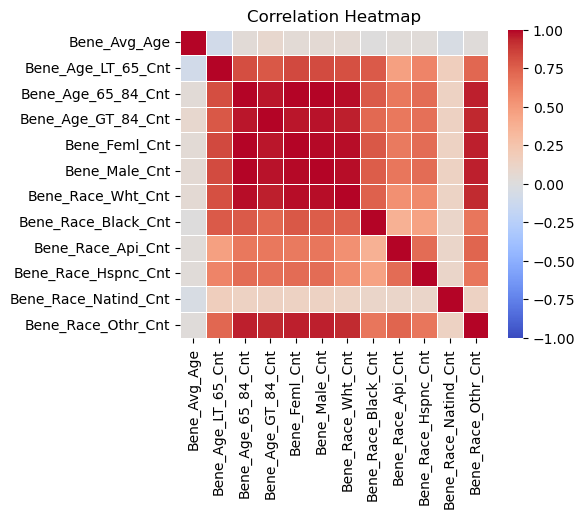

In [213]:
# Plotting a heat map of the correlation table.

plt.figure(figsize=(5, 4))

sns.heatmap(
    bene_corr,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [214]:
# Running the Principal Component Reduction.

bene_pca = PCA(n_components = 6)
bene_pca_c = bene_pca.fit_transform(X_bene)

In [215]:
# Looking at the variability explained by each component in bene.

bene_pca.explained_variance_ratio_
bene_ex_vratio = np.cumsum(bene_pca.explained_variance_ratio_)
bene_ex_vratio

array([0.97952441, 0.99308137, 0.99543122, 0.997195  , 0.99834463,
       0.99929018])

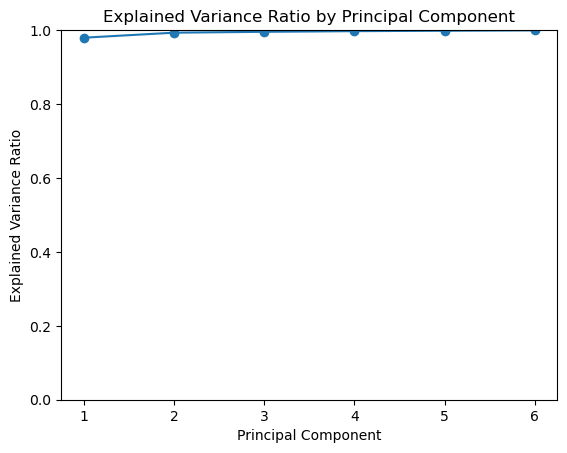

In [216]:
# Plotting the ratios to figure out how many variables we should keep.

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(bene_ex_vratio) + 1)
y = bene_ex_vratio
# plot
ax.plot(x, y, marker='o')
ax.set_ylim(0, 1)
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

#Recovering Feature Names of explained_variance_ratio_ in PCA with sklearn. (2024, June 27). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/recovering-feature-names-of-explainedvarianceratio-in-pca-with-sklearn/

In [217]:
# I used ChatGPT to help me figure out how to retrieve the variable names with the PC values.

bene_comps = bene_pca.components_

bene_comps_df = pd.DataFrame(
    bene_comps,
    columns=X_bene.columns,
    index=[f'PC{i+1}' for i in range(bene_comps.shape[0])]
)

print(bene_comps_df)

# Chatgpt. (n.d.). ChatGPT. Retrieved April 6, 2026, from https://chatgpt.com/

     Bene_Avg_Age  Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
PC1      0.000232            0.035229            0.639379            0.061784   
PC2      0.001499           -0.015569           -0.287274           -0.030227   
PC3     -0.009400            0.222755            0.068794           -0.075886   
PC4     -0.003108           -0.183507            0.281611            0.029189   
PC5      0.005510            0.079258           -0.287540            0.003470   
PC6      0.008535            0.320834           -0.536943            0.067783   

     Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
PC1       0.419028       0.317123           0.547941             0.050061   
PC2      -0.152365      -0.139215           0.638143            -0.007460   
PC3       0.262683      -0.153325          -0.228381             0.831014   
PC4      -0.124519       0.060866          -0.233214             0.065541   
PC5       0.717379      -0.482391           0.0

In [218]:
# From the ratio plot, the top variable explains 98% of the variance in the data.
# From the table above, Bene_Age_65_84_Cnt (PC1 value = 0.64) would be that variable.
# However, given that this analysis chunk is made up of essentially mostly non-overlapping variables (except for Bene_Avg_Age).
# Therefore, all variables, except for Bene_Avg_Age, will be used in the cluster.

In [219]:
# Standardizing numeric data to zscore.

bene_num = bene[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Opioid_Tot_Benes_norm', 'Opioid_Cst_Per_Bene_norm', 'Opioid_LA_Tot_Benes_norm', 'Opioid_LA_Cst_Per_Bene_norm']]
bene_numz = pd.DataFrame(stats.zscore(bene_num, nan_policy = 'omit'), columns = bene_num.columns)
bene_numz.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874


In [220]:
# Comparing against mean values and standard deviations in each column in bene_num.

print(bene_num.describe())

       Bene_Age_LT_65_Cnt  Bene_Age_65_84_Cnt  Bene_Age_GT_84_Cnt  \
count        1.380665e+06        1.380665e+06        1.380665e+06   
mean         2.403406e+01        9.965139e+01        1.989761e+01   
std          5.171221e+01        7.755029e+02        7.721835e+01   
min          0.000000e+00        0.000000e+00        0.000000e+00   
25%          1.000000e+01        0.000000e+00        1.000000e+01   
50%          1.000000e+01        1.100000e+01        1.000000e+01   
75%          2.600000e+01        1.270000e+02        1.500000e+01   
max          2.158900e+04        4.286940e+05        4.399300e+04   

       Bene_Feml_Cnt  Bene_Male_Cnt  Bene_Race_Wht_Cnt  Bene_Race_Black_Cnt  \
count   1.380665e+06   1.380665e+06       1.380665e+06         1.380665e+06   
mean    9.384940e+01   6.735218e+01       1.172071e+02         2.127122e+01   
std     5.088425e+02   3.858250e+02       6.696899e+02         7.920985e+01   
min     0.000000e+00   0.000000e+00       0.000000e+00        

In [221]:
# The bene-num data frame serves as the final data set because this subset does not include categorical data.

bene_f = bene_numz.copy()
bene_f.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874


In [222]:
# Check for null values per column.

print(bene_f.isnull().sum())

Bene_Age_LT_65_Cnt             0
Bene_Age_65_84_Cnt             0
Bene_Age_GT_84_Cnt             0
Bene_Feml_Cnt                  0
Bene_Male_Cnt                  0
Bene_Race_Wht_Cnt              0
Bene_Race_Black_Cnt            0
Bene_Race_Api_Cnt              0
Bene_Race_Hspnc_Cnt            0
Bene_Race_Natind_Cnt           0
Bene_Race_Othr_Cnt             0
Opioid_Tot_Benes_norm          0
Opioid_Cst_Per_Bene_norm       0
Opioid_LA_Tot_Benes_norm       0
Opioid_LA_Cst_Per_Bene_norm    0
dtype: int64


In [223]:
# For debugging purposes: create a sample set of bene (10% of data) for model optimization purposes.

#bene_f10 = bene_f.sample(frac = 0.1, random_state = 0)
#bene_f10.describe()

In [224]:
# Remove opioid data from bene_f.

bene_fo = bene_f[['Bene_Age_LT_65_Cnt', 'Bene_Age_65_84_Cnt', 'Bene_Age_GT_84_Cnt', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt']]
bene_fo.head()

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267


In [225]:
# Convert the data frame to a matrix.

bene_fmat = bene_fo.to_numpy()

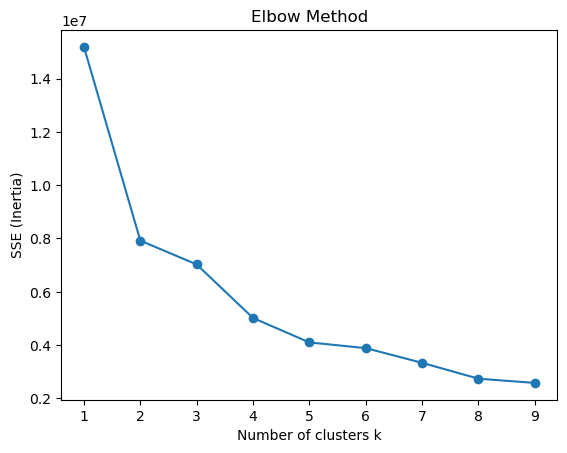

In [226]:
# Using a k-means model to determine number of clusters. Originally tried using kprotoype, but it returned an error because the matrix did not contain categorical data.
# The error suggested using k-means instead.

distortions = []
inertias = []
K = range(1, 10)

for k in K:
    kmeans_bene = KMeans(n_clusters=k, random_state=42).fit(bene_fmat)
    
    distortions.append(sum(np.min(cdist(bene_fmat, kmeans_bene.cluster_centers_, 'euclidean'), axis=1)**2) / bene_fmat.shape[0])
    
    inertias.append(kmeans_bene.inertia_)

# Plot
plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

#Elbow Method for optimal value of k in KMeans. (2019, June 6). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [227]:
#Run k-means using 1 cluster as determined from the elbow plot above.

kmeans_bene = KMeans(n_clusters=1, random_state=42).fit(bene_fmat)

In [228]:
# Cluster centorid

kmeans_bene.cluster_centers_

array([[-4.55834102e-15, -3.40735666e-15, -5.49057100e-15,
        -1.60885154e-15,  1.01103711e-15,  7.45677447e-16,
         2.43468435e-15,  1.52796369e-15,  2.32348553e-15,
        -3.10024182e-15,  1.49613633e-15]])

In [229]:
# Check the iteration of the clusters created

kmeans_bene.n_iter_

2

In [230]:
# Check the cost of the clusters created

kmeans_bene.inertia_

15187314.999994535

In [232]:
# Add the clusters to the bene_f dataframe.

bene_f2 = bene_f.copy()

bene_f2['Cluster Labels'] = kmeans_bene.labels_
bene_f2['Segment'] = bene_f2['Cluster Labels'].map({0: 'Cluster 1', 1: 'Cluster 2'})

# Order the cluster
bene_f2['Segment'] = bene_f2['Segment'].astype('category')
bene_f2['Segment'] = bene_f2['Segment'].cat.set_categories(
    ['Cluster 1', 'Cluster 2'],
    ordered=True
)
bene_f2.head(10)

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.308746,0.427269,0.597040,0.434615,0.400824,0.573091,-0.142296,0.003357,-0.081470,-0.512537,0.314302,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,1.140272,0.574271,0.299183,0.137863,1.139501,0.579064,0.375317,0.003357,-0.081470,12.086193,0.314302,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,0.366760,0.124240,-0.011624,0.116245,0.097577,0.063900,-0.079172,0.003357,0.392570,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [233]:
# Cluster interpretation

bene_f2.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
bene_f2.groupby('Segment').agg(
    {
        'Total': 'count',
        'Bene_Age_LT_65_Cnt': 'mean',
        'Bene_Age_65_84_Cnt': 'mean',
        'Bene_Age_GT_84_Cnt': 'mean',
        'Bene_Feml_Cnt': 'mean',
        'Bene_Male_Cnt': 'mean',
        'Bene_Race_Wht_Cnt': 'mean',
        'Bene_Race_Black_Cnt': 'mean',
        'Bene_Race_Api_Cnt': 'mean',
        'Bene_Race_Hspnc_Cnt': 'mean',
        'Bene_Race_Natind_Cnt': 'mean',
        'Bene_Race_Othr_Cnt': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\4177858927.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1380665,1.252794e-17,3.964000e-18,1.137576e-17,1.313131e-17,-1.633661e-17,1.506039e-17,5.411932e-18,1.139328e-17,-8.758858e-18,2.669138e-17,2.181494e-18,-6.971339e-17,-9.424550e-18,-1.795395e-17,-2.151207e-18
1,Cluster 2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [234]:
# Add the clusters to the bene_f dataframe.

bene_f1 = bene_f.copy()

bene_f1['Cluster Labels'] = kmeans_bene.labels_
bene_f1['Segment'] = bene_f1['Cluster Labels'].map({0: 'Cluster 1'})

# Order the cluster
bene_f1['Segment'] = bene_f1['Segment'].astype('category')
bene_f1['Segment'] = bene_f1['Segment'].cat.reorder_categories(['Cluster 1'])

bene_f1.head(10)

,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm,Cluster Labels,Segment
0,-0.155361,-0.043393,0.130829,-0.058661,-0.050158,-0.066011,-0.053923,0.017286,-0.081470,-0.512537,0.011267,-0.380871,-0.228457,-0.541490,-0.119874,0,Cluster 1
1,3.170741,0.219662,0.001326,0.426754,0.258272,0.162453,2.407893,0.003357,0.042868,1.123662,0.093913,1.532623,2.616815,-0.384133,10.377701,0,Cluster 1
2,-0.271388,-0.128499,-0.128177,-0.123514,-0.101995,-0.094383,-0.268543,-0.135930,-0.159182,1.123662,0.011267,-0.219357,-0.333759,-0.010299,-0.119874,0,Cluster 1
3,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.086917,-0.142296,0.003357,-0.081470,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1
4,-0.271388,-0.128499,-0.128177,-0.154958,-0.146056,-0.146646,-0.142296,-0.135930,-0.081470,-0.512537,0.011267,1.012495,-0.086828,-0.541490,-0.119874,0,Cluster 1
5,0.308746,0.427269,0.597040,0.434615,0.400824,0.573091,-0.142296,0.003357,-0.081470,-0.512537,0.314302,-0.585421,0.010389,-0.483128,0.145063,0,Cluster 1
6,1.140272,0.574271,0.299183,0.137863,1.139501,0.579064,0.375317,0.003357,-0.081470,12.086193,0.314302,0.336090,-0.246612,-0.541490,-0.119874,0,Cluster 1
7,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
8,-0.271388,-0.128499,-0.128177,-0.164785,-0.148648,-0.160085,-0.142296,0.003357,-0.081470,1.123662,0.011267,2.291650,-0.333759,2.592535,-0.119874,0,Cluster 1
9,0.366760,0.124240,-0.011624,0.116245,0.097577,0.063900,-0.079172,0.003357,0.392570,-0.512537,0.011267,-0.731808,-0.333759,-0.541490,-0.119874,0,Cluster 1


In [235]:
# Cluster interpretation

bene_f1.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
bene_f1.groupby('Segment').agg(
    {
        'Total': 'count',
        'Bene_Age_LT_65_Cnt': 'mean',
        'Bene_Age_65_84_Cnt': 'mean',
        'Bene_Age_GT_84_Cnt': 'mean',
        'Bene_Feml_Cnt': 'mean',
        'Bene_Male_Cnt': 'mean',
        'Bene_Race_Wht_Cnt': 'mean',
        'Bene_Race_Black_Cnt': 'mean',
        'Bene_Race_Api_Cnt': 'mean',
        'Bene_Race_Hspnc_Cnt': 'mean',
        'Bene_Race_Natind_Cnt': 'mean',
        'Bene_Race_Othr_Cnt': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean'
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\2673161749.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Bene_Age_LT_65_Cnt,Bene_Age_65_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1380665,1.252794e-17,3.964000e-18,1.137576e-17,1.313131e-17,-1.633661e-17,1.506039e-17,5.411932e-18,1.139328e-17,-8.758858e-18,2.669138e-17,2.181494e-18,-6.971339e-17,-9.424550e-18,-1.795395e-17,-2.151207e-18


In [236]:
# These large disparaties in the cluster sizes may be due to an imbalance in the classes.
# Therefore, future improvements would be a deeper dive into the data distributions to make sure that each class is evenly represented.

# Results and Analysis


In [237]:
# Variable name mapping - worked on a seperate notebook with a different variable name.
prdemo_f_10 = prdemo_f2
ge65_f_10 = ge65_f2
gbip_f_10 = gbip_f2
meds_f_10 = meds_f2
bene_f_10 = bene_f2

In [249]:
# Cluster interpretation

prdemo_f3.rename(columns = {'Cluster Labels':'Total'}, inplace = True)
prdemo_f3.groupby('Segment').agg(
    {
        'Total': 'count',
        'Prscrbr_Crdntls': lambda x: x.value_counts().index[0],
        'Prscrbr_Ent_Cd': lambda x: x.value_counts().index[0],
        'Prscrbr_City': lambda x: x.value_counts().index[0],
        'Prscrbr_State_Abrvtn': lambda x: x.value_counts().index[0],
        'Prscrbr_RUCA': lambda x: x.value_counts().index[0],
        'Prscrbr_Type': lambda x: x.value_counts().index[0],
        'Prscrbr_Type_src': lambda x: x.value_counts().index[0],
        'Tot_Clms': 'mean',
        'Tot_30day_Fills': 'mean',
        'Tot_Drug_Cst': 'mean',
        'Tot_Day_Suply': 'mean',
        'Tot_Benes': 'mean',
        'Tot_Cst_Per_Bene': 'mean',
        'Opioid_Tot_Benes_norm': 'mean',
        'Opioid_Cst_Per_Bene_norm': 'mean',
        'Opioid_LA_Tot_Benes_norm': 'mean',
        'Opioid_LA_Cst_Per_Bene_norm': 'mean',
    }
).reset_index()

C:\Users\satxj\AppData\Local\Temp\ipykernel_24708\910348761.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_30day_Fills,Tot_Drug_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1268282,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.201664,-0.232028,-0.148712,-0.239391,-0.048778,-0.053289,0.042382,-0.001226,0.043446,-0.020741
1,Cluster 2,112364,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,2.261449,2.610300,1.661262,2.701748,0.512982,0.601510,-0.478256,0.013831,-0.490299,0.234113
2,Cluster 3,19,M.D.,I,Highland Park,TX,1.0,Family Practice,Claim-Specialty,87.411321,51.207137,102.253783,1.930355,222.315770,-0.167067,-0.731517,0.035474,-0.541350,-0.011097


In [253]:
# Cluster interpretation

prdemo_summary = prdemo_f2.groupby('Segment', observed=False).agg(
    Total=('Segment', 'count'),
    Prscrbr_Crdntls=('Prscrbr_Crdntls', lambda x: x.value_counts().index[0]),
    Prscrbr_Ent_Cd=('Prscrbr_Ent_Cd', lambda x: x.value_counts().index[0]),
    Prscrbr_City=('Prscrbr_City', lambda x: x.value_counts().index[0]),
    Prscrbr_State_Abrvtn=('Prscrbr_State_Abrvtn', lambda x: x.value_counts().index[0]),
    Prscrbr_RUCA=('Prscrbr_RUCA', lambda x: x.value_counts().index[0]),
    Prscrbr_Type=('Prscrbr_Type', lambda x: x.value_counts().index[0]),
    Prscrbr_Type_src=('Prscrbr_Type_src', lambda x: x.value_counts().index[0]),
    Tot_Clms=('Tot_Clms', 'mean'),
    Tot_Drg_Cst=('Tot_Drug_Cst', 'mean'),
    Tot_Day_Suply=('Tot_Day_Suply', 'mean'),
    Tot_Benes=('Tot_Benes', 'mean'),
    Tot_Cst_Per_Bene=('Tot_Cst_Per_Bene', 'mean'),
    Opioid_Tot_Benes_norm=('Opioid_Tot_Benes_norm', 'mean'),
    Opioid_Cst_Per_Bene_norm=('Opioid_Cst_Per_Bene_norm', 'mean'),
    Opioid_LA_Tot_Benes_norm=('Opioid_LA_Tot_Benes_norm', 'mean'),
    Opioid_LA_Cst_Per_Bene_norm=('Opioid_LA_Cst_Per_Bene_norm', 'mean')
).reset_index()

prdemo_summary    

,Segment,Total,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_RUCA,Prscrbr_Type,Prscrbr_Type_src,Tot_Clms,Tot_Drg_Cst,Tot_Day_Suply,Tot_Benes,Tot_Cst_Per_Bene,Opioid_Tot_Benes_norm,Opioid_Cst_Per_Bene_norm,Opioid_LA_Tot_Benes_norm,Opioid_LA_Cst_Per_Bene_norm
0,Cluster 1,1269474,MD,I,New York,CA,1.0,Nurse Practitioner,Claim-Specialty,-0.200593,-0.147650,-0.238072,-0.048467,-0.052600,0.041880,-0.001199,0.042966,-0.020568
1,Cluster 2,111191,MD,I,Houston,CA,1.0,Family Practice,Claim-Specialty,2.290179,1.685726,2.718077,0.553348,0.600541,-0.478147,0.013692,-0.490544,0.234826


In [263]:
#summary
summary_data = {
    'Chunk': [
        'Prescriber Demographics', 'Prescriber Demographics',
    ],
    'Cluster': [
        'Cluster 1', 'Cluster 2',
    ],
    'N (providers)': [
        prdemo_summary.loc[0, 'Total'], prdemo_summary.loc[1, 'Total'],
    ],
    'Key Metric (z-score)': [
        round(prdemo_summary.loc[0, 'Tot_Clms'], 3), round(prdemo_summary.loc[1, 'Tot_Clms'], 3),
    ],
    'Key Metric Label': [
        'Total Claims', 'Total Claims',
    ],
    'Opioid Beneficiary Rate': [
        round(prdemo_summary.loc[0, 'Opioid_Tot_Benes_norm'], 3), round(prdemo_summary.loc[1, 'Opioid_Tot_Benes_norm'], 3),
    ],
    'Opioid Cost Per Beneficiary': [
        round(prdemo_summary.loc[0, 'Opioid_Cst_Per_Bene_norm'], 3), round(prdemo_summary.loc[1, 'Opioid_Cst_Per_Bene_norm'], 3),
    ]
}

comprehensive_summary = pd.DataFrame(summary_data)
comprehensive_summary

,Chunk,Cluster,N (providers),Key Metric (z-score),Key Metric Label,Opioid Beneficiary Rate,Opioid Cost Per Beneficiary
0,Prescriber Demographics,Cluster 1,1269474,-0.201,Total Claims,0.042,-0.001
1,Prescriber Demographics,Cluster 2,111191,2.290,Total Claims,-0.478,0.014


## Model Performance Evaluation
### Silhouette Scores

Silhouette scores measure how well each provider fits within its assigned cluster compared to other clusters. Scores range from -1 to 1, where a score closer to 1 indicates well-defined, clearly separated clusters. Note that silhouette scores are only calculated for the K-Means chunks — the K-Prototypes model used for Prescriber Demographics handles mixed data types and is not compatible with standard Euclidean distance-based evaluation metrics.

In [241]:
from sklearn.metrics import silhouette_score

# Silhouette scores for each chunk (K-Means only - not applicable for K-Prototypes)
ge65_sil = silhouette_score(ge65_fmat, kmeans_ge652.labels_)
gbip_sil = silhouette_score(gbip_fmat, kmeans_gbip.labels_)
meds_sil = silhouette_score(meds_fmat, kmeans_meds.labels_)

print(f'Elderly Patients 65+ silhouette score: {round(ge65_sil, 3)}')
print(f'Generic/Brand & Insurance silhouette score: {round(gbip_sil, 3)}')
print(f'Additional Medications silhouette score: {round(meds_sil, 3)}')

KeyboardInterrupt: 

## Provider Analysis

In [242]:
# Filter for pain management providers
pain_mgmt = df_op[df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)]

print(f'Total pain management providers: {len(pain_mgmt)}')
print(f'\nTop prescriber types found:')
print(pain_mgmt['Prscrbr_Type'].value_counts().head(10))

Total pain management providers: 4431

Top prescriber types found:
Prscrbr_Type
Pain Management                   2816
Interventional Pain Management    1615
Name: count, dtype: int64


In [243]:
# Compare pain management opioid metrics vs all other providers
pain_mgmt_avg = pain_mgmt[['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']].mean()
all_others_avg = df_op[~df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)][['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']].mean()

comparison = pd.DataFrame({
    'Pain Management': pain_mgmt_avg,
    'All Other Providers': all_others_avg
})

print(comparison)

                     Pain Management  All Other Providers
Opioid_Tot_Clms          1113.267885            41.244009
Opioid_Prscrbr_Rate         0.406912             0.046328
Opioid_Tot_Suply        30654.956218           783.333303
Opioid_Cst_Per_Bene       304.755668            22.890599


NameError: name 'labels' is not defined

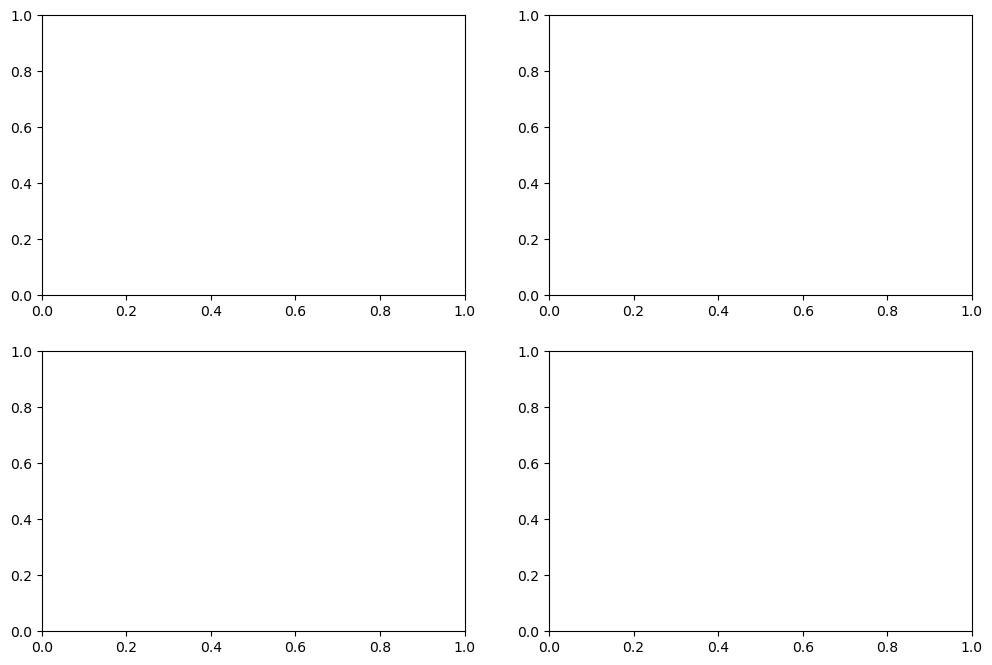

In [264]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(metrics, labels)):
    axes[i].bar(['pain management', 'all other providers'], 
                [pain_mgmt_avg[metric], all_others_avg[metric]], 
                color=['mediumpurple', 'hotpink'])
    axes[i].set_title(label)
    axes[i].set_ylabel('mean value')

plt.suptitle('pain management vs all other providers: opioid metrics', fontsize=13)
plt.tight_layout()
plt.show()

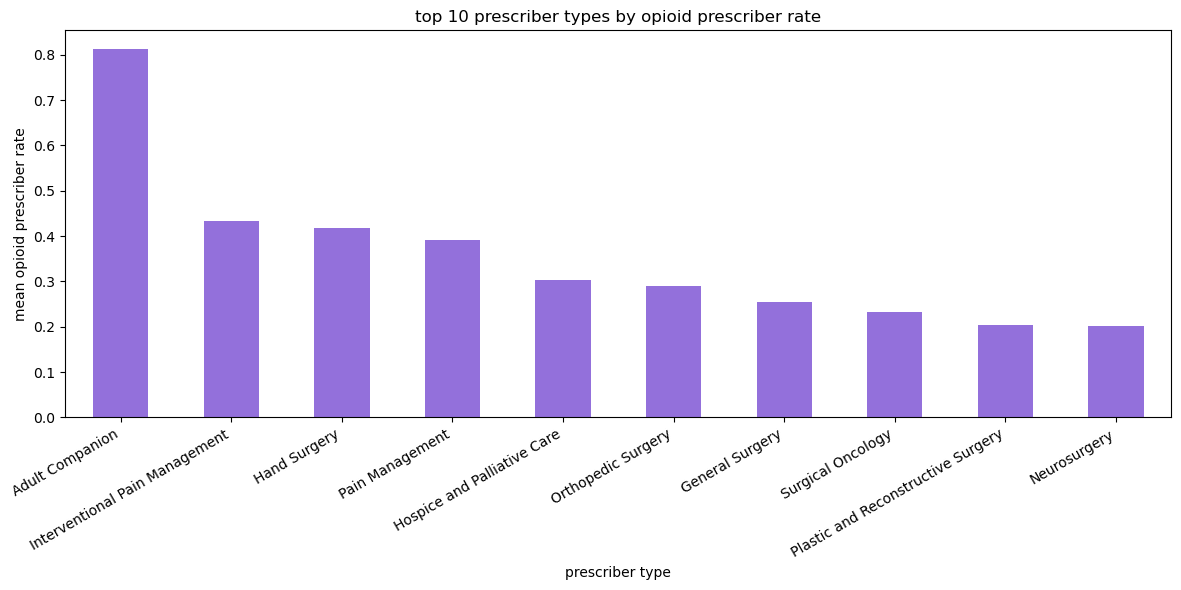

In [265]:
# top 10 prescriber types by opioid prescriber rate
top10 = df_op.groupby('Prscrbr_Type')['Opioid_Prscrbr_Rate'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top10.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('top 10 prescriber types by opioid prescriber rate')
ax.set_xlabel('prescriber type')
ax.set_ylabel('mean opioid prescriber rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

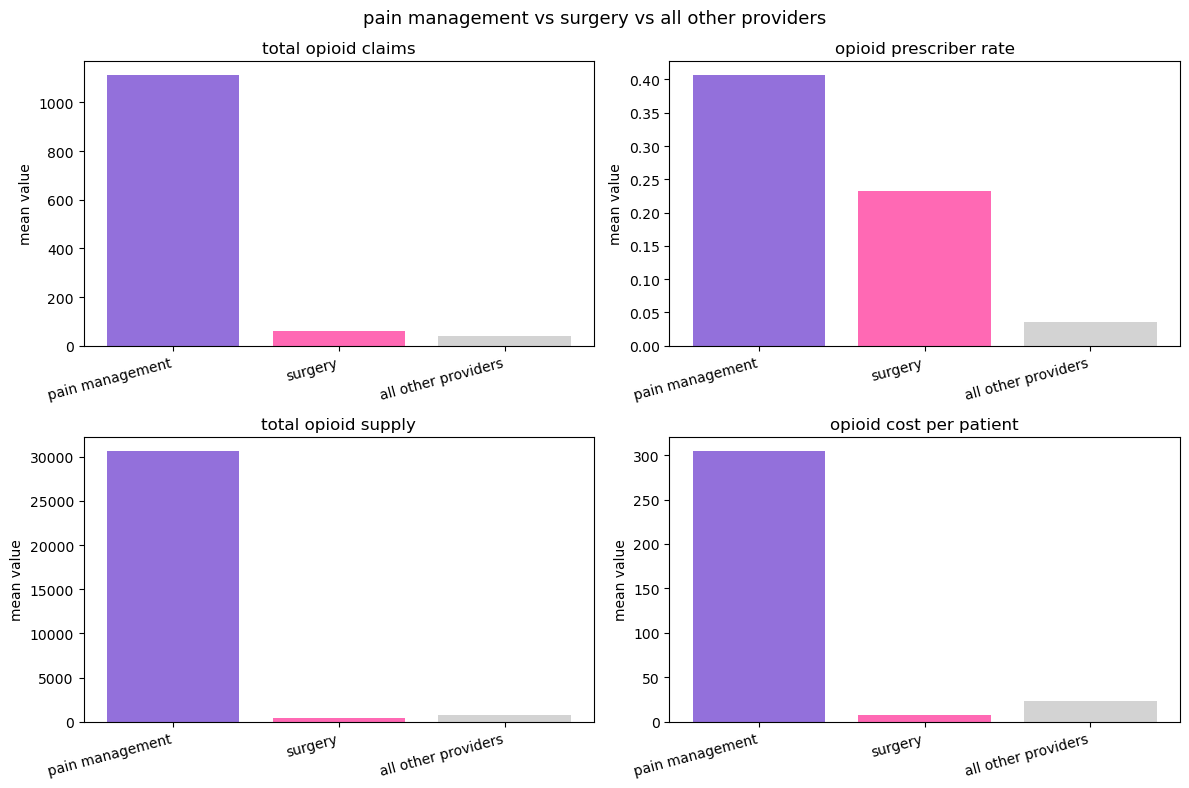

In [266]:
# Surgery vs Pain Management opioid comparison
surgery = df_op[df_op['Prscrbr_Type'].str.contains('Surgery|Surgical', case=False, na=False)]
pain = df_op[df_op['Prscrbr_Type'].str.contains('Pain', case=False, na=False)]

groups = {
    'pain management': pain,
    'surgery': surgery,
    'all other providers': df_op[~df_op['Prscrbr_Type'].str.contains('Pain|Surgery|Surgical', case=False, na=False)]
}

metrics = ['Opioid_Tot_Clms', 'Opioid_Prscrbr_Rate', 'Opioid_Tot_Suply', 'Opioid_Cst_Per_Bene']
labels = ['total opioid claims', 'opioid prescriber rate', 'total opioid supply', 'opioid cost per patient']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(metrics, labels)):
    vals = [groups[g][metric].mean() for g in groups]
    axes[i].bar(groups.keys(), vals, color=['mediumpurple', 'hotpink', 'lightgray'])
    axes[i].set_title(label)
    axes[i].set_ylabel('mean value')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('pain management vs surgery vs all other providers', fontsize=13)
plt.tight_layout()
plt.show()

## Prescription Volume Distribution
### Small vs Large Prescribers

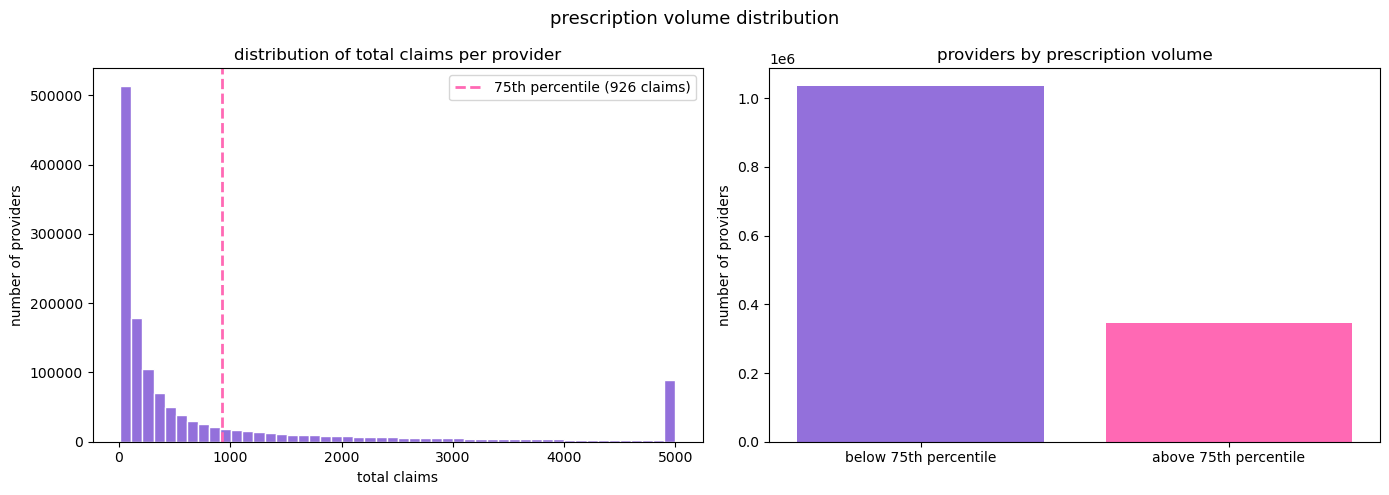

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

threshold = df_op['Tot_Clms'].quantile(0.75)

# histogram
axes[0].hist(df_op['Tot_Clms'].dropna().clip(upper=5000), bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('distribution of total claims per provider')
axes[0].set_xlabel('total claims')
axes[0].set_ylabel('number of providers')
axes[0].axvline(threshold, color='hotpink', linestyle='--', linewidth=2, label=f'75th percentile ({int(threshold)} claims)')
axes[0].legend()

# bar chart
axes[1].bar(['below 75th percentile', 'above 75th percentile'], 
            [1035539, 345126],
            color=['mediumpurple', 'hotpink'])
axes[1].set_title('providers by prescription volume')
axes[1].set_ylabel('number of providers')

plt.suptitle('prescription volume distribution', fontsize=13)
plt.tight_layout()
plt.show()